## Advanced football Teams' ExG Model:

In this notebook the goal is to create a model based on the ExG data of teams instead of goals as shown in the project before. 

Initially the ExG data are explored from the source of https://understat.com/. At the next step the optimal model selection is done for using the ExG as one metric for the past of teams and it is tested and with time decay effects and empirical corrections such as the Dixon-Coles model for goals. In the latter step the home and away teams' ExG was considered independent, in the next step a way to include dependence and what it means is shown. 

The next section is a more detailed approach on the teams' ExG by modeling each category of ExG separately by splitting it by the creation situation of open-play, cornerns, free kicks and penalties. After modeling each part a final model including all the components is created and backtested against the average B6365 match result odds.

In [145]:
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations
import itertools
import time
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime, timedelta
from scipy import stats

from scipy.optimize import minimize, brentq
from scipy.special import digamma, gammaln, expit
from scipy.stats import gamma, chi2, nbinom, lognorm, invgauss, linregress, poisson, norm
from scipy.stats import poisson, nbinom
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import poisson as pois
from scipy import optimize

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA


from IPython.display import display
from scipy.stats import gamma as gamma_dist

## Loading and Exploring the Data:

The data have been scrapted by the football data site https://understat.com/ which has data on English Premier League from 2011 to (and including) 2025 on match level including, beside the match scoreline, teams' ExGs, shots, SoTs, deep passes made (20 yds from the target) and ppda (passes allowed to own half per defensive actions).

In [3]:
df = pd.read_csv("Understat_Data/EPL_match_xg.csv")
df.head()

,season,match_id,date,home,away,home_goals,away_goals,home_xg,away_xg
0,2014/2015,4749,2014-08-16,Manchester United,Swansea,1,2,1.167,0.279
1,2014/2015,4750,2014-08-16,Leicester,Everton,2,2,1.279,0.614
2,2014/2015,4751,2014-08-16,Queens Park Rangers,Hull,0,1,1.902,1.119
3,2014/2015,4752,2014-08-16,Stoke,Aston Villa,0,1,0.424,0.911
4,2014/2015,4753,2014-08-16,West Bromwich Albion,Sunderland,2,2,1.684,0.993


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4478 entries, 0 to 4477
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      4478 non-null   object 
 1   match_id    4478 non-null   int64  
 2   date        4478 non-null   object 
 3   home        4478 non-null   object 
 4   away        4478 non-null   object 
 5   home_goals  4478 non-null   int64  
 6   away_goals  4478 non-null   int64  
 7   home_xg     4478 non-null   float64
 8   away_xg     4478 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 315.0+ KB


The home and away teams' ExG values can contain zeros and it can arise problems with fitting distributions that are not defined at zero. Fpr this reason a small amount of 0.001 is added to both ExG values for all games.

In [5]:
df['home_xg'] += 0.001
df['away_xg'] += 0.001

The home and away ExG are expected to have the same distribution with a constant difference to their mean due to the well known home advantage. As it can be shown bellow based on the 4 first moments the ExG distribution cannot be a normal distribution with Gamma and Log-Normal seeming a better option.

In [6]:
print("Mean:", np.round(np.mean(df['home_xg']),3))
print("Variance:", np.round(np.var(df['home_xg']),3))
print("Skewness:", np.round(stats.skew(df['home_xg']),3))
print("Kurtosis:", np.round(stats.kurtosis(df['home_xg']),3))

Mean: 1.582
Variance: 0.841
Skewness: 0.888
Kurtosis: 0.962


An important check that is needed before moving to the modeling of football matches based on the ExG metric is the accuracy of the ExG values compared to the actual observed goals. For this case the home ExG data are splitted to equal bins and they are plotted against the mean goal values at each bin. 

The distribution of ExGs as it will be shown later in this notebook is the Gamma distribution so the confidence intervals of the bins are skewed to higher values and they are not symmetric. This is not a surpise since even with many tries of low ExG a team can score many goals if it is lucky.

The resulting plot shows that the ExG metric of the given data captures well enough the observed goals across different ExG values. The highest disagreement (althought within the CI range) can be found in the ExG range [2.5,3.5]. This can be a result of the ongoing tactical changes of the game since the teams that can create this large amount of ExG are the favorites in most of the games which only consider successful result winning. Even if they have created so much ExG favorites might not have a winning scoreline, either due to luck of the underdog scoring many goals out of luck or the favorite due to its bad luck not scoring the goals that they should have, they have to pressure more to get to a winning scoreline. This means that the already high ExG didn't account to the expected goals and the ExG will get even higher leading to that difference with the observed goals. But this matter is a subject more appropriate for an inplay model with different game states and ExG autocorrelation so it won't be examined further here. 

In [7]:
xg_col = "home_xg"
goals_col = "home_goals"

exg_range = np.linspace(0.25, 4.25, 9)
ci_level = 0.95
alpha_ci = 1 - ci_level

data = df[[xg_col, goals_col]].dropna().copy()

data["xg_bin"] = pd.cut(data[xg_col],bins=exg_range,include_lowest=True)

def gamma_mean_ci(x, ci_level=0.95):
    x = pd.Series(x).dropna()
    n = len(x)

    if n <= 1:
        return np.nan, np.nan

    mean_x = x.mean()
    var_x = x.var(ddof=1)

    if mean_x <= 0 or var_x <= 0:
        return mean_x, mean_x

    # Method of moments Gamma parameters
    shape_hat = mean_x**2 / var_x
    scale_hat = var_x / mean_x

    lower_q = (1 - ci_level) / 2
    upper_q = 1 - lower_q

    # Distribution of sample mean
    mean_shape = n * shape_hat
    mean_scale = scale_hat / n

    ci_low = gamma.ppf(lower_q, a=mean_shape, scale=mean_scale)
    ci_high = gamma.ppf(upper_q, a=mean_shape, scale=mean_scale)

    return ci_low, ci_high


def poisson_mean_ci(total_goals, n, ci_level=0.95):
    lower_q = (1 - ci_level) / 2
    upper_q = 1 - lower_q

    if total_goals == 0:
        ci_low = 0.0
    else:
        ci_low = 0.5 * chi2.ppf(lower_q, 2 * total_goals) / n

    ci_high = 0.5 * chi2.ppf(upper_q, 2 * (total_goals + 1)) / n

    return ci_low, ci_high


rows = []

for bin_name, group in data.groupby("xg_bin", observed=True):

    n = len(group)

    mean_xg = group[xg_col].mean()
    mean_goals = group[goals_col].mean()
    total_goals = group[goals_col].sum()

    xg_ci_low, xg_ci_high = gamma_mean_ci(group[xg_col], ci_level=ci_level)
    goals_ci_low, goals_ci_high = poisson_mean_ci(total_goals, n, ci_level=ci_level)

    residual_pct = 100 * (mean_goals - mean_xg) / mean_xg
    residual_pct_low = 100 * (goals_ci_low / xg_ci_high - 1)
    residual_pct_high = 100 * (goals_ci_high / xg_ci_low - 1)

    rows.append({
        "xg_bin": bin_name,
        "n": n,

        "mean_xg": mean_xg,
        "xg_ci_low": xg_ci_low,
        "xg_ci_high": xg_ci_high,

        "mean_goals": mean_goals,
        "goals_ci_low": goals_ci_low,
        "goals_ci_high": goals_ci_high,

        "residual_pct": residual_pct,
        "residual_pct_low": residual_pct_low,
        "residual_pct_high": residual_pct_high
    })

binned = pd.DataFrame(rows)
xerr_lower = binned["mean_xg"] - binned["xg_ci_low"]
xerr_upper = binned["xg_ci_high"] - binned["mean_xg"]

yerr_lower = binned["mean_goals"] - binned["goals_ci_low"]
yerr_upper = binned["goals_ci_high"] - binned["mean_goals"]

resid_yerr_lower = binned["residual_pct"] - binned["residual_pct_low"]
resid_yerr_upper = binned["residual_pct_high"] - binned["residual_pct"]

binned

,xg_bin,n,mean_xg,xg_ci_low,xg_ci_high,mean_goals,goals_ci_low,goals_ci_high,residual_pct,residual_pct_low,residual_pct_high
0,"(0.249, 0.75]",761,0.537463,0.527682,0.547332,0.613666,0.559264,0.671931,14.178417,2.180049,27.336387
1,"(0.75, 1.25]",1045,1.005801,0.996959,1.014681,1.041148,0.980194,1.104900,3.514350,-3.398780,10.827023
2,"(1.25, 1.75]",897,1.493126,1.483655,1.502627,1.502787,1.423625,1.585206,0.647038,-5.257580,6.844620
3,"(1.75, 2.25]",677,1.989753,1.978868,2.000669,1.884786,1.782777,1.991111,-5.275403,-10.890955,0.618687
4,"(2.25, 2.75]",511,2.483290,2.470625,2.495986,2.330724,2.200219,2.466948,-6.143688,-11.849695,-0.148828
5,"(2.75, 3.25]",257,2.983374,2.965903,3.000895,2.719844,2.521925,2.929169,-8.833261,-15.960886,-1.238551
6,"(3.25, 3.75]",127,3.457016,3.431270,3.482857,3.251969,2.945860,3.581243,-5.931337,-15.418269,4.370789
7,"(3.75, 4.25]",53,3.985887,3.946551,4.025415,3.716981,3.216031,4.273844,-6.746445,-20.106842,8.293137


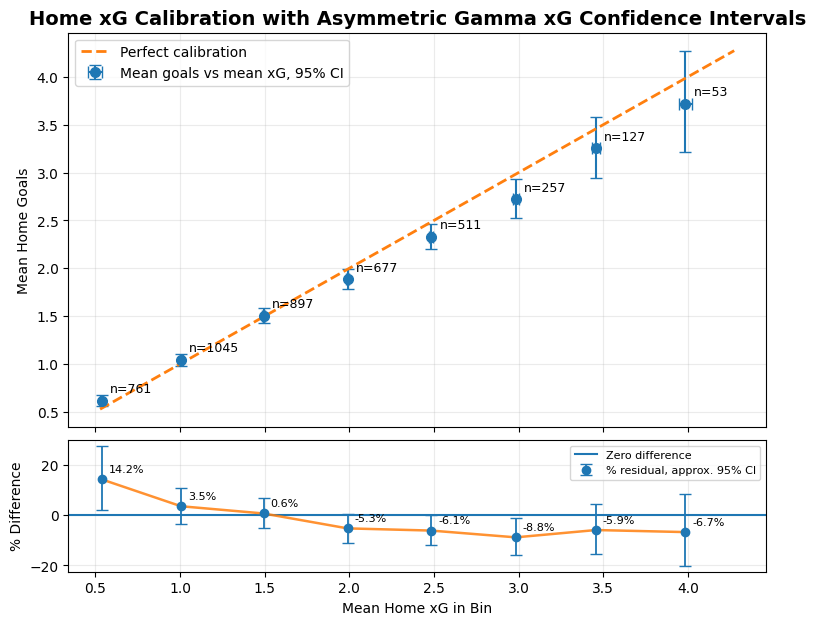

In [8]:
fig, axes = plt.subplots(2,1,figsize=(9, 7),sharex=True,
    gridspec_kw={"height_ratios": [3, 1],"hspace": 0.05})

ax = axes[0]
ax_resid = axes[1]
ax.errorbar(
    binned["mean_xg"],
    binned["mean_goals"],
    xerr=[xerr_lower, xerr_upper],
    yerr=[yerr_lower, yerr_upper],
    fmt="o",capsize=4,markersize=7,linewidth=1.5,
    label=f"Mean goals vs mean xG, {int(ci_level * 100)}% CI")

min_val = min(binned["xg_ci_low"].min(),binned["goals_ci_low"].min())
max_val = max(binned["xg_ci_high"].max(),binned["goals_ci_high"].max())

ax.plot([min_val, max_val],[min_val, max_val],linestyle="--",linewidth=2,label="Perfect calibration")

for _, row in binned.iterrows():
    ax.annotate(
        f"n={int(row['n'])}",
        xy=(row["mean_xg"], row["mean_goals"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_ylabel("Mean Home Goals")
ax.set_title(
    "Home xG Calibration with Asymmetric Gamma xG Confidence Intervals",
    fontsize=14,
    fontweight="bold"
)
ax.grid(True, alpha=0.25)
ax.legend()

ax_resid.axhline(0,linestyle="-",linewidth=1.5,label="Zero difference")
ax_resid.errorbar(
    binned["mean_xg"],
    binned["residual_pct"],
    yerr=[resid_yerr_lower, resid_yerr_upper],
    fmt="o",capsize=4,markersize=6,
    linewidth=1.3,label=f"% residual, approx. {int(ci_level * 100)}% CI")
ax_resid.plot(binned["mean_xg"],binned["residual_pct"],linewidth=1.8,alpha=0.85)

for _, row in binned.iterrows():
    ax_resid.annotate(
        f"{row['residual_pct']:.1f}%",
        xy=(row["mean_xg"], row["residual_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8)

ax_resid.set_xlabel("Mean Home xG in Bin")
ax_resid.set_ylabel("% Difference")
ax_resid.grid(True, alpha=0.25)
ax_resid.legend(fontsize=8)


Home advantage and total goals from the goals' observations:

In [9]:
print("Avg Match Total Goals:", (df['home_goals']+df['away_goals']).mean().round(2))
print("Avg Match Goals' Difference:", (df['home_goals']-df['away_goals']).mean().round(2))

Avg Match Total Goals: 2.8
Avg Match Goals' Difference: 0.28


The ExG home advantage follows a distribution close to normal with mean 0.31 while the total ExG seems to follwo a Gamma or Log-Normal distribution with mean 2.89.

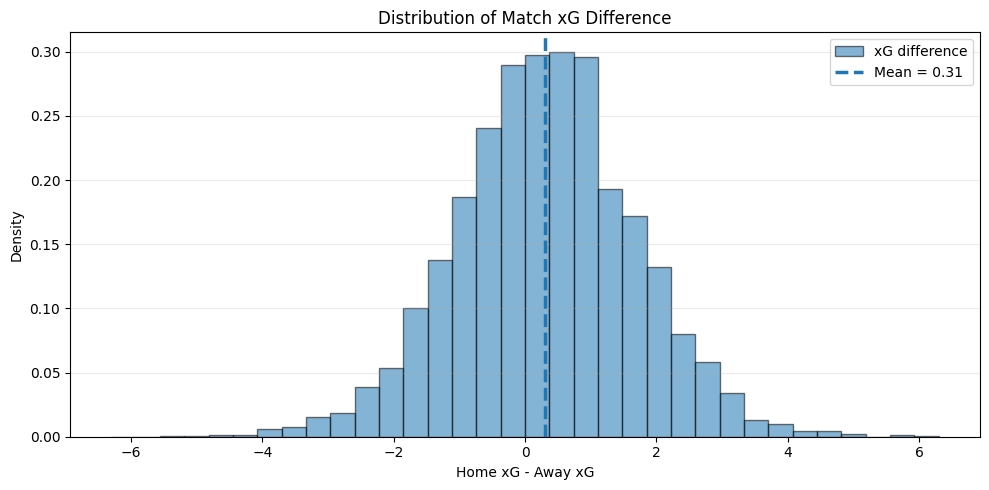

In [10]:
xg_diff = (df["home_xg"] - df["away_xg"]).dropna()
mean_diff = xg_diff.mean()

max_abs = np.ceil(np.abs(xg_diff).max() * 10) / 10
bins = np.linspace(-max_abs, max_abs, 35)

plt.figure(figsize=(10, 5))

plt.hist(xg_diff,bins=bins,density=True,alpha=0.55,edgecolor="black",label="xG difference")
plt.axvline(mean_diff,linestyle="--",linewidth=2.5,label=f"Mean = {mean_diff:.2f}")

plt.xlabel("Home xG - Away xG")
plt.ylabel("Density")
plt.title("Distribution of Match xG Difference")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

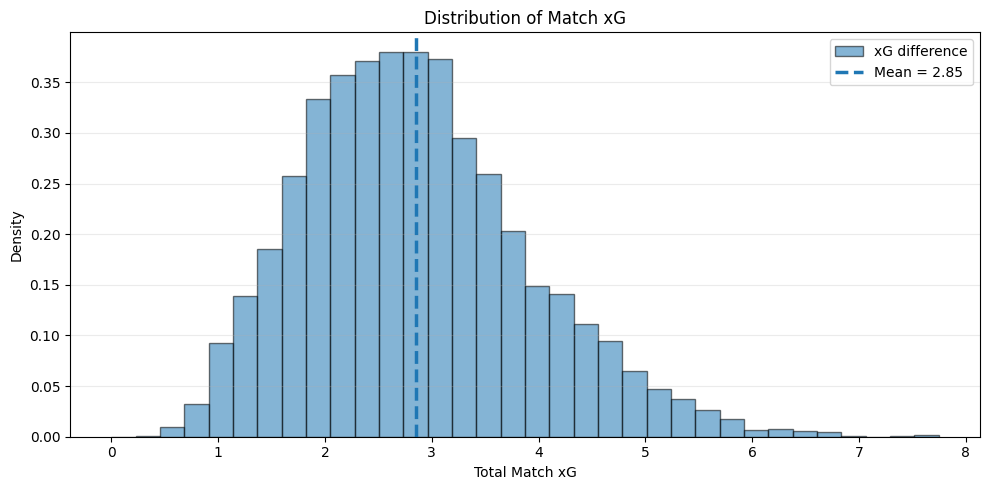

In [11]:
xg_tot = (df["home_xg"] + df["away_xg"]).dropna()
mean_tot = xg_tot.mean()

max_abs = xg_tot.max()
bins = np.linspace(0, max_abs, 35)

plt.figure(figsize=(10, 5))

plt.hist(xg_tot,bins=bins,density=True,alpha=0.55,edgecolor="black",label="xG difference")
plt.axvline(mean_tot,linestyle="--",linewidth=2.5,label=f"Mean = {mean_tot:.2f}")

plt.xlabel("Total Match xG")
plt.ylabel("Density")
plt.title("Distribution of Match xG")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

For modeling the expected goals (ExG) we have to account for the Exg being an exclusively positive quantity so the distribution that discribe it needs to be always positive. The potential distribution candidates are the Gamma, Log-Normal and Inverse Gaussian which could fit well the data. All the candidates are tried for fitting the home team ExG below, there in no additional diffference expected compared to the away team ExG except the home advantage. The Normal distribution is applied as well just for having a baseline model, in case of very small $\sigma$ value for the Normal case it could fit the data well since the potential negative values would be extremely low. 

The criterion for deciding which model is the best in the Akaike Information Criterion (AIC) which follows the following formula:

$$ AIC = 2 \cdot k - 2 \cdot ln(Likelihood) $$

where k is the total number of a model's parameters and the Likelihood can be easily calculated for all the mentioned models.


--- AIC Model Comparison ---
Gamma : 11157.0
Log-Normal : 11717.0
Inverse Gaussian : 13257.0
Normal : 11936.0


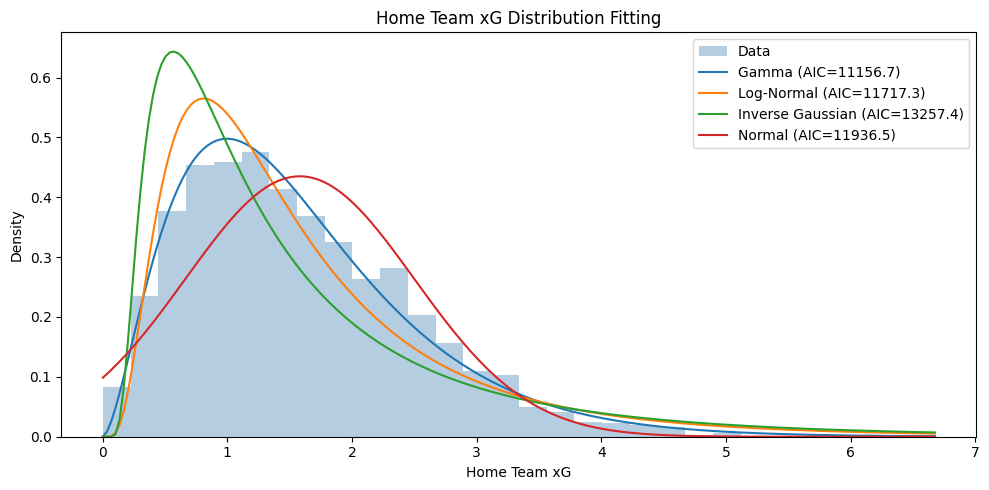

In [12]:
xg = df['home_xg']

distributions = {
    "Gamma":           gamma,
    "Log-Normal":      lognorm,
    "Inverse Gaussian":invgauss,
    "Normal":          norm,}

results = {}
x = np.linspace(xg.min(), xg.max(), 200)

plt.figure(figsize=(10, 5))
plt.hist(xg, bins=30, density=True, alpha=0.4, color="steelblue", label="Data")

for name, dist in distributions.items():
    if name != "Normal":
        params = dist.fit(xg, floc=0)
    else: 
        params = dist.fit(xg)
    
    log_lik = np.sum(dist.logpdf(xg, *params))
    k = len(params)
    aic = 2 * k - 2 * log_lik
    results[name] = {"params": params,"AIC": aic}
    
    plt.plot(x, dist.pdf(x, *params), label=f"{name} (AIC={aic:.1f})")

plt.xlabel("Home Team xG")
plt.ylabel("Density")
plt.title("Home Team xG Distribution Fitting")
plt.legend()
plt.tight_layout()

print("\n--- AIC Model Comparison ---")
for name, dist in distributions.items():
    
    print(name,":",np.round(results[name]['AIC']))

## Football model based on independent ExGs:

The teams are assumed for now to follow independent distributions and the bets two cases as it can be seen in plot above are the Gamma and the Log-Normal. The parameters that the models need are one parameter of attack $\lambda_i$ and one for defence $\gamma_i$ ability for each team i in the data, the home advantage $\delta$ which is considered constant across different teams and an intercept $\alpha$ for modeling stability reasons which is also an ExG baseline. The attack and defence parameters are re-centered to sum to zero in order to find a specific solution of parameters for each case:
$$\sum_{i} \lambda_i = 0, \qquad \sum_{i} \gamma_i = 0$$

In both selected distributions model the parameters estimation is done through maximum likelihood estimation. In the case of the Gamma distribution the total parameters are all the $\lambda_i$, $\gamma_i$, $\delta$, $\alpha$ plus the shape parameter $\phi$ while the Log-Normal has $\lambda_i$, $\gamma_i$, $\delta$, $\alpha$ plus the scale parameter $\sigma$. So the total number of parameters is the same for both cases being $3+2\cdot n_{teams}$.

Below the data are transformed based on an indices format for team with all the teams included in the dataset being sorted alphabetically:

In [13]:
teams    = sorted(set(df["home"]) | set(df["away"]))
team_idx = {t: i for i, t in enumerate(teams)}
n_teams  = len(teams)

home_id  = df["home"].map(team_idx).values
away_id  = df["away"].map(team_idx).values
home_xg  = df["home_xg"].values.astype(float)
away_xg  = df["away_xg"].values.astype(float)

print("Number of teams:",n_teams)
print("Number of matches:",len(df))

Number of teams: 35
Number of matches: 4478


### Log-Normal Distribution Model for ExG:

Each team's xG is treated as Log-Normally distributed variables following:

$$\log Y \sim \mathcal{N}(\mu_{\log},\ \sigma^2)$$

$$f(y;\mu_{\log},\sigma) = \frac{1}{y\,\sigma\sqrt{2\pi}}
\exp\!\left(-\frac{(\log y - \mu_{\log})^2}{2\sigma^2}\right),\qquad y>0$$

The mean value follows:

$$\mathbb{E}[Y] = \exp\!\left(\mu_{\log} + \tfrac{\sigma^2}{2}\right)$$


The ExG for each team is fitted based on the log-mean for each side which is built from additive team effects on the log scale:

$$\mu_{\log}^{\text{home}} = \alpha + \delta + \lambda_{h} - \gamma_{a}$$
$$\mu_{\log}^{\text{away}} = \alpha + \lambda_{a} - \gamma_{h}$$

The single-observation log-density and overall log-likelihood are:

$$\log f(y) = -\log y - \tfrac{1}{2}\log(2\pi) - \log\sigma 
- \frac{(\log y - \mu_{\log})^2}{2\sigma^2}$$

$$L(\theta) = \sum_{m} \Big[\log f\big(y_m^{\text{home}};\mu_{\log,m}^{\text{home}},\sigma\big) 
+ \log f\big(y_m^{\text{away}};\mu_{\log,m}^{\text{away}},\sigma\big)\Big]$$

where $\theta = \{\alpha,\ \delta,\ \lambda_1,\dots,\lambda_T,\ \gamma_1,\dots,\gamma_T,\sigma \}$

In [14]:
teams    = sorted(set(df["home"]) | set(df["away"]))
team_idx = {t: i for i, t in enumerate(teams)}
n_teams  = len(teams)

home_id  = df["home"].map(team_idx).values
away_id  = df["away"].map(team_idx).values
home_xg  = df["home_xg"].values.astype(float)
away_xg  = df["away_xg"].values.astype(float)

print("Number of teams:",n_teams)
print("Number of matches:",len(df))



def unpack(params):
    intercept = params[0]
    home_adv  = params[1]
    attack    = params[2 : 2 + n_teams]
    defense   = params[2 + n_teams : 2 + 2 * n_teams]
    sigma     = np.exp(params[-1])
    return intercept, home_adv, attack, defense, sigma

def compute_mu_log(params):
    intercept, home_adv, attack, defense, sigma = unpack(params)

    attack  = attack  - attack.mean()
    defense = defense - defense.mean()

    mu_log_home = intercept + home_adv + attack[home_id] - defense[away_id]
    mu_log_away = intercept + attack[away_id] - defense[home_id]

    return mu_log_home, mu_log_away, sigma

def neg_log_likelihood(params):
    mu_log_home, mu_log_away, sigma = compute_mu_log(params)

    def lognorm_logpdf(y, mu_log, sigma):
        return (- np.log(y) - 0.5 * np.log(2 * np.pi) - np.log(sigma) - (np.log(y) - mu_log) ** 2 / (2 * sigma ** 2))

    ll = (lognorm_logpdf(home_xg, mu_log_home, sigma).sum() + lognorm_logpdf(away_xg, mu_log_away, sigma).sum())
    return -ll

n_params = 2 + 2 * n_teams + 1
init     = np.zeros(n_params)
init[0]  = np.log(np.mean(home_xg)) - 0.5 * np.var(np.log(home_xg)) 
init[1]  = 0.1                                                          
init[-1] = np.log(np.std(np.log(home_xg)))                            

result = minimize(
    neg_log_likelihood,
    x0      = init,
    method  = "L-BFGS-B",
    options = {"maxiter": 10000, "ftol": 1e-12})


intercept, home_adv, attack, defense, sigma = unpack(result.x)

mu_log_home_fit, mu_log_away_fit, _ = compute_mu_log(result.x)
mean_home_fit = np.exp(mu_log_home_fit + sigma**2 / 2)
mean_away_fit = np.exp(mu_log_away_fit + sigma**2 / 2)

residuals_home = home_xg - mean_home_fit
residuals_away = away_xg - mean_away_fit

n_obs = 2 * len(df)
k = n_params

AIC_LN = 2*k - 2*(-result.fun)
BIC_LN = k*np.log(n_obs) - 2*(-result.fun)
RMSE_H_LN = np.sqrt((residuals_home**2).mean())
RMSE_A_LN = np.sqrt((residuals_away**2).mean())

print("── Model Parameters ──────────────────────────")
print("Intercept (Mean Log Exg):", round(home_adv,3))
print("Home Adv:", round(home_adv,3))
print("Sigma:", round(sigma,3))
print("RMSE Home:", round(RMSE_H_LN,3))
print("RMSE Away:", round(RMSE_A_LN,3))

Number of teams: 35
Number of matches: 4478
── Model Parameters ──────────────────────────
Intercept (Mean Log Exg): 0.258
Home Adv: 0.258
Sigma: 0.655
RMSE Home: 0.831
RMSE Away: 0.742


In [15]:
def unpack(params):
    intercept = params[0]
    home_adv  = params[1]
    attack    = params[2 : 2 + n_teams]
    defense   = params[2 + n_teams : 2 + 2 * n_teams]
    sigma     = np.exp(params[-1])
    return intercept, home_adv, attack, defense, sigma

def compute_mu_log(params):
    intercept, home_adv, attack, defense, sigma = unpack(params)

    attack  = attack  - attack.mean()
    defense = defense - defense.mean()

    mu_log_home = intercept + home_adv + attack[home_id] - defense[away_id]
    mu_log_away = intercept + attack[away_id] - defense[home_id]

    return mu_log_home, mu_log_away, sigma

def neg_log_likelihood(params):
    mu_log_home, mu_log_away, sigma = compute_mu_log(params)

    def lognorm_logpdf(y, mu_log, sigma):
        return (- np.log(y) - 0.5 * np.log(2 * np.pi) - np.log(sigma) - (np.log(y) - mu_log) ** 2 / (2 * sigma ** 2))

    ll = (lognorm_logpdf(home_xg, mu_log_home, sigma).sum() + lognorm_logpdf(away_xg, mu_log_away, sigma).sum())
    return -ll

n_params = 2 + 2 * n_teams + 1
init     = np.zeros(n_params)
init[0]  = np.log(np.mean(home_xg)) - 0.5 * np.var(np.log(home_xg)) 
init[1]  = 0.1                                                          
init[-1] = np.log(np.std(np.log(home_xg)))                            

result = minimize(
    neg_log_likelihood,
    x0      = init,
    method  = "L-BFGS-B",
    options = {"maxiter": 10000, "ftol": 1e-12})


intercept, home_adv, attack, defense, sigma = unpack(result.x)

mu_log_home_fit, mu_log_away_fit, _ = compute_mu_log(result.x)
mean_home_fit = np.exp(mu_log_home_fit + sigma**2 / 2)
mean_away_fit = np.exp(mu_log_away_fit + sigma**2 / 2)

residuals_home = home_xg - mean_home_fit
residuals_away = away_xg - mean_away_fit

n_obs = 2 * len(df)
k = n_params

AIC_LN = 2*k - 2*(-result.fun)
BIC_LN = k*np.log(n_obs) - 2*(-result.fun)
RMSE_H_LN = np.sqrt((residuals_home**2).mean())
RMSE_A_LN = np.sqrt((residuals_away**2).mean())

print("── Model Parameters ──────────────────────────")
print("Intercept (Mean Log Exg):", round(home_adv,3))
print("Home Adv:", round(home_adv,3))
print("Sigma:", round(sigma,3))
print("RMSE Home:", round(RMSE_H_LN,3))
print("RMSE Away:", round(RMSE_A_LN,3))

── Model Parameters ──────────────────────────
Intercept (Mean Log Exg): 0.258
Home Adv: 0.258
Sigma: 0.655
RMSE Home: 0.831
RMSE Away: 0.742


### Gamma Distribution Model for ExG:

Each team's xG is treated as Gamma distributed, parameterized by a mean $\mu$ and 
a shape $\phi$:

$$Y \sim \text{Gamma}\!\left(\text{shape}=\phi,\ \text{scale}=\mu/\phi\right)$$

The mean and variance of the Gamma distribution are:

$$\mathbb{E}[Y] = \mu, \qquad \text{Var}(Y) = \frac{\mu^2}{\phi}$$

so the mean enters directly (no $\sigma^2/2$ correction is needed, unlike the 
Log-Normal), and $\phi$ controls dispersion: large $\phi$ concentrates xG tightly 
around $\mu$, small $\phi$ spreads it out. The density is:

$$f(y;\mu,\phi) = \frac{1}{\Gamma(\phi)}\left(\frac{\phi}{\mu}\right)^{\phi} 
y^{\phi-1} \exp\!\left(-\frac{\phi y}{\mu}\right),\qquad y>0$$


The mean for each side is built from additive team effects on the **log scale**, then 
exponentiated (a log link), which keeps every predicted xG strictly positive:

$$\mu_{\text{home}} = \exp\!\left(\alpha + \delta + \lambda_{h} - \gamma_{a}\right)$$
$$\mu_{\text{away}} = \exp\!\left(\alpha + \lambda_{a} - \gamma_{h}\right)$$




The model is fit by **maximum likelihood**. The single-observation Gamma log-density 
(in the mean/shape parameterization) is:

$$\log f(y;\mu,\phi) = (\phi-1)\log y - \frac{\phi y}{\mu} 
+ \phi \log\!\frac{\phi}{\mu} - \log\Gamma(\phi)$$

which is exactly the `gamma_logpdf` function in the code ($\log\Gamma$ is `gammaln`). 
Summed over both sides of every match:

$$\ell(\theta) = \sum_{m} \Big[\log f\big(y_m^{\text{home}};\mu_m^{\text{home}},\phi\big) 
+ \log f\big(y_m^{\text{away}};\mu_m^{\text{away}},\phi\big)\Big]$$

The optimizer minimizes $-\ell(\theta)$ over:

$$\theta = \{\alpha,\ \delta,\ \lambda_1,\dots,\lambda_T,\ \gamma_1,\dots,\gamma_T,\ \tilde\phi\}$$

In [16]:
def unpack(params):
    intercept = params[0]
    home_adv  = params[1]
    attack    = params[2 : 2 + n_teams]
    defense   = params[2 + n_teams : 2 + 2 * n_teams]
    log_phi   = params[-1]
    phi       = np.exp(log_phi)  # ensure positive
    return intercept, home_adv, attack, defense, phi

def compute_mu(params):
    intercept, home_adv, attack, defense, phi = unpack(params)

    attack  = attack  - attack.mean()
    defense = defense - defense.mean()
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi

def neg_log_likelihood(params):
    mu_home, mu_away, phi = compute_mu(params)

    def gamma_logpdf(y, mu, phi):
        return ((phi - 1) * np.log(y) - y * (phi / mu)+ phi * np.log(phi / mu) - gammaln(phi))

    ll = (gamma_logpdf(home_xg, mu_home, phi).sum() + gamma_logpdf(away_xg, mu_away, phi).sum())
    return -ll

n_params = 2 + 2 * n_teams + 1
init = np.zeros(n_params)
init[0]  = np.log(np.mean(home_xg))
init[1]  = 0.1                    
init[-1] = np.log(5.0) 

result = minimize(
    neg_log_likelihood,
    x0     = init,
    method = "L-BFGS-B",
    options= {"maxiter": 10000, "ftol": 1e-12})

intercept, home_adv, attack, defense, phi = unpack(result.x)
attack  = attack  - attack.mean()
defense = defense - defense.mean()

mu_home_fit, mu_away_fit, _ = compute_mu(result.x)
residuals_home = home_xg - mean_home_fit
residuals_away = away_xg - mean_away_fit

n_obs = 2 * len(df)
k = n_params

AIC_GM = 2*k - 2*(-result.fun)
BIC_GM = k*np.log(n_obs) - 2*(-result.fun)
RMSE_H_GM = np.sqrt((residuals_home**2).mean())
RMSE_A_GM = np.sqrt((residuals_away**2).mean())

print("── Model Parameters ──────────────────────────")
print("Intercept (Mean Log Exg):", round(home_adv,3))
print("Home Adv:", round(home_adv,3))
print("Phi (shape):", round(phi,3))
print("RMSE Home:", round(RMSE_H_GM,3))
print("RMSE Away:", round(RMSE_A_GM,3))

── Model Parameters ──────────────────────────
Intercept (Mean Log Exg): 0.218
Home Adv: 0.218
Phi (shape): 2.914
RMSE Home: 0.831
RMSE Away: 0.742


The best model fit is found in the Gamma Distribution model in both AIC and BIC metric with a large difference.

In [17]:
print("── Models Comparisons ──────────────────────────")
print("AIC| Gamma:" ,round(AIC_GM),", Log Normal:", round(AIC_LN))
print("BIC| Gamma:" ,round(BIC_GM),", Log Normal:", round(BIC_LN))

── Models Comparisons ──────────────────────────
AIC| Gamma: 19382 , Log Normal: 20371
BIC| Gamma: 19900 , Log Normal: 20889


Now the models' parameters can be estimated based on the Gamma distributions' model but these results are based on the assumption 
of equal importance of information regardless its time. In the teams' parameters Man City is the best team in both terms of attack and defence with Liverpool and Arsenal following with large difference. These results are not representative of the last season (2025/2026) in which arsenal was the best team with the best diffence and Liverpool was much less strong overall compared to the other two. The Aston Villa having the best 13th attack and 16th diffence is an even more suitable example for showing that is essential to consider the time effects.

In [18]:
print(f"\n── Model Parameters ──────────────────────────")
print(f"  Intercept  : {intercept:.4f}")
print(f"  Home Adv   : {home_adv:.4f}")
print(f"  Phi (shape): {phi:.4f}")

team_df = pd.DataFrame({
    "team"   : teams,
    "attack" : attack,
    "defense": defense,
}).sort_values("attack", ascending=False).reset_index(drop=True)

team_df["att_rank"] = team_df["attack"].rank(ascending=False).astype(int)
team_df["def_rank"] = team_df["defense"].rank(ascending=False).astype(int)

print("\n── Team Strengths ────────────────────────────")
print(team_df.to_string(index=False))


── Model Parameters ──────────────────────────
  Intercept  : 0.1800
  Home Adv   : 0.2181
  Phi (shape): 2.9141

── Team Strengths ────────────────────────────
                   team    attack   defense  att_rank  def_rank
        Manchester City  0.534381  0.457259         1         1
              Liverpool  0.445238  0.305106         2         2
                Arsenal  0.342091  0.266050         3         4
                Chelsea  0.310880  0.283590         4         3
              Brentford  0.253332  0.039205         5        10
              Tottenham  0.247205  0.122482         6         6
      Manchester United  0.230818  0.171679         7         5
                  Leeds  0.137012 -0.084027         8        29
               Brighton  0.134648  0.074908         9         8
            Bournemouth  0.108075 -0.061607        10        25
              Leicester  0.083962  0.035202        11        11
       Newcastle United  0.074927  0.025898        12        13
      

### Time Decay Effects:

The time decay effects are practically downgrading the value of likelihood contribution of older observations  while still the same process of 
maximum likelihood estimation is followed. For a match $m$ played on date $d_m$, its weight for a fit anchored at reference date $t^*$ is:

$$w_m = e^{-\xi \cdot a_m}, \qquad a_m = \max(0,\ (t^* - d_m)\ \text{in days})$$

Each match's contribution to the log-likelihood is scaled by its weight:

$$\ell(\theta) = \sum_{m=1}^{M} w_m \cdot \ell_m(\theta)$$

For the full Gamma model with $y_h, y_a$ observed and $\mu_h, \mu_a$ predicted:

$$\ell(\theta) = \sum_{m=1}^{M} w_m \cdot \big[\log f_\Gamma(y_h^{(m)};\, \mu_h^{(m)}, \phi) + \log f_\Gamma(y_a^{(m)};\, \mu_a^{(m)}, \phi)\big]$$

The simplest way for estimating the $\xi$ value would be by maximizing the likelihood of the last 20% of data being the most recent based on a trained 
model on 80% of the pas data. The issue with that approach is that football teams' strength is changing rapidly in a timespan of half a season and more 
so the predictive power of such model would be terrible for the recent events. For this reason the model is updated weekly and predicts only the matches of the next week while still the total test data account for the most recent 20% of the whole dataset. So the $\xi$ optimal value is estimated by :

$$\hat\xi = \arg\max_{\xi \in \Xi}\ \sum_{w \in \mathcal{W}_{\text{val}}} \ell_{\text{holdout}}(w;\ \hat\theta_{\xi, <w})$$

where:
- $\Xi$ is a grid of candidate decay rates
- $\mathcal{W}_{\text{val}}$ is the set of held-out validation weeks
- $\hat\theta_{\xi, <w}$ is the model fitted on all data **before** week $w$ using decay $\xi$
- $\ell_{\text{holdout}}(w;\ \theta)$ is the log-likelihood of the matches in week $w$ under those parameters


Now the Gamma distributions' model can be trained with the addition of time decay weights:

In [19]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
dates = df["date"]

teams    = sorted(set(df["home"]) | set(df["away"]))
team_idx = {t: i for i, t in enumerate(teams)}
n_teams  = len(teams)
home_id  = df["home"].map(team_idx).values
away_id  = df["away"].map(team_idx).values
home_xg  = df["home_xg"].values.astype(float) + 0.01   # +0.01 avoids log(0)
away_xg  = df["away_xg"].values.astype(float) + 0.01

def compute_mu(params):
    intercept = params[0]
    home_adv  = params[1]
    attack    = params[2 : 2 + n_teams]
    defense   = params[2 + n_teams : 2 + 2 * n_teams]
    phi       = np.exp(params[-1])
    attack  = attack  - attack.mean()
    defense = defense - defense.mean()
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept              + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi

def make_nll(weights, home_xg, away_xg, n_teams, compute_mu):
    def gamma_logpdf(y, mu, phi):
        return ((phi - 1) * np.log(y) - y * (phi / mu)
                + phi * np.log(phi / mu) - gammaln(phi))
    def nll(params):
        mu_home, mu_away, phi = compute_mu(params)
        ll = ((weights * gamma_logpdf(home_xg, mu_home, phi)).sum()
            + (weights * gamma_logpdf(away_xg, mu_away, phi)).sum())
        return -ll
    return nll

def gamma_logpdf_eval(y, mu, phi):
    return ((phi - 1) * np.log(y) - y * (phi / mu)
            + phi * np.log(phi / mu) - gammaln(phi))

n_params = 2 + 2 * n_teams + 1
init     = np.zeros(n_params)
init[0]  = np.log(np.mean(home_xg))
init[1]  = 0.1
init[-1] = np.log(5.0)

cutoff_idx = int(0.8 * len(df))
val_start_date = dates.iloc[cutoff_idx]
val_dates    = dates[dates >= val_start_date]
val_indices  = val_dates.index.values
week_offsets = ((val_dates - val_start_date).dt.days // 7).astype(int).values
unique_weeks = np.unique(week_offsets)

week_earliest_dates = {}
week_ages           = {}
week_train_masks    = {}
week_predict_masks  = {}

for wk in unique_weeks:
    wk_predict_mask = np.zeros(len(df), bool)
    wk_predict_mask[val_indices[week_offsets == wk]] = True
    week_predict_masks[wk] = wk_predict_mask
    earliest = dates[wk_predict_mask].min()
    week_earliest_dates[wk] = earliest
    week_train_masks[wk]    = (dates < earliest).values
    week_ages[wk]           = (earliest - dates).dt.days.values.astype(float)


def walk_forward_sweep(xi_grid, verbose=True):
    total_ll = np.zeros(len(xi_grid))
    prev_x   = [init.copy() for _ in xi_grid]

    for wk in unique_weeks:
        train_mask = week_train_masks[wk]
        age        = week_ages[wk]
        wk_predict_mask = week_predict_masks[wk]

        if train_mask.sum() < 20:
            continue

        for k, xi in enumerate(xi_grid):
            w = train_mask * np.exp(-xi * age)
            try:
                res = minimize(make_nll(w, home_xg, away_xg, n_teams, compute_mu),
                    x0=prev_x[k],method="L-BFGS-B",
                    options={"maxiter": 2000, "ftol": 1e-8})
                prev_x[k] = res.x
            except Exception:
                continue

            mu_h, mu_a, phi = compute_mu(res.x)
            total_ll[k] += (
                gamma_logpdf_eval(home_xg[wk_predict_mask], mu_h[wk_predict_mask], phi).sum()
              + gamma_logpdf_eval(away_xg[wk_predict_mask], mu_a[wk_predict_mask], phi).sum())

    if verbose:
        for xi, ll in zip(xi_grid, total_ll):
            print(f"  ξ = {xi:.5f}  →  walk-forward LL = {ll:>10.2f}")
    return total_ll


print("── Coarse sweep ─────────────────────────────────")
xi_coarse = np.array([0.0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.010])
ll_coarse = walk_forward_sweep(xi_coarse)
best_coarse_idx = int(np.argmax(ll_coarse))
best_coarse_xi  = xi_coarse[best_coarse_idx]

print(f"\n── Fine sweep around ξ = {best_coarse_xi:.5f} ──────────")
if best_coarse_idx == 0:
    xi_lo, xi_hi = 0.0, xi_coarse[1]
elif best_coarse_idx == len(xi_coarse) - 1:
    xi_lo, xi_hi = xi_coarse[-2], xi_coarse[-1] + (xi_coarse[-1] - xi_coarse[-2])
else:
    xi_lo, xi_hi = xi_coarse[best_coarse_idx - 1], xi_coarse[best_coarse_idx + 1]

xi_fine = np.linspace(max(0.0, xi_lo), xi_hi, 9)
ll_fine = walk_forward_sweep(xi_fine)

best_xi = xi_fine[int(np.argmax(ll_fine))]
best_ll = ll_fine.max()

print(f"\nBest ξ (fine):        {best_xi:.5f}")
print(f"Best walk-forward LL: {best_ll:.2f}")
if best_xi > 0:
    print(f"Implied half-life:    {np.log(2) / best_xi:.1f} days")
else:
    print("No decay (ξ = 0)")

── Coarse sweep ─────────────────────────────────
  ξ = 0.00000  →  walk-forward LL =   -2219.66
  ξ = 0.00100  →  walk-forward LL =   -2122.49
  ξ = 0.00200  →  walk-forward LL =   -2092.16
  ξ = 0.00400  →  walk-forward LL =   -2087.93
  ξ = 0.00600  →  walk-forward LL =   -2102.99
  ξ = 0.00800  →  walk-forward LL =   -2126.26
  ξ = 0.01000  →  walk-forward LL =   -2156.43

── Fine sweep around ξ = 0.00400 ──────────
  ξ = 0.00200  →  walk-forward LL =   -2092.16
  ξ = 0.00250  →  walk-forward LL =   -2087.39
  ξ = 0.00300  →  walk-forward LL =   -2085.57
  ξ = 0.00350  →  walk-forward LL =   -2085.98
  ξ = 0.00400  →  walk-forward LL =   -2087.93
  ξ = 0.00450  →  walk-forward LL =   -2090.63
  ξ = 0.00500  →  walk-forward LL =   -2094.25
  ξ = 0.00550  →  walk-forward LL =   -2098.37
  ξ = 0.00600  →  walk-forward LL =   -2102.99

Best ξ (fine):        0.00300
Best walk-forward LL: -2085.57
Implied half-life:    231.0 days


The likelihood values across different $\xi$ values showing that the optimal is well estimated:

Best xi: 0.00300
Best fine log-likelihood: -2085.57


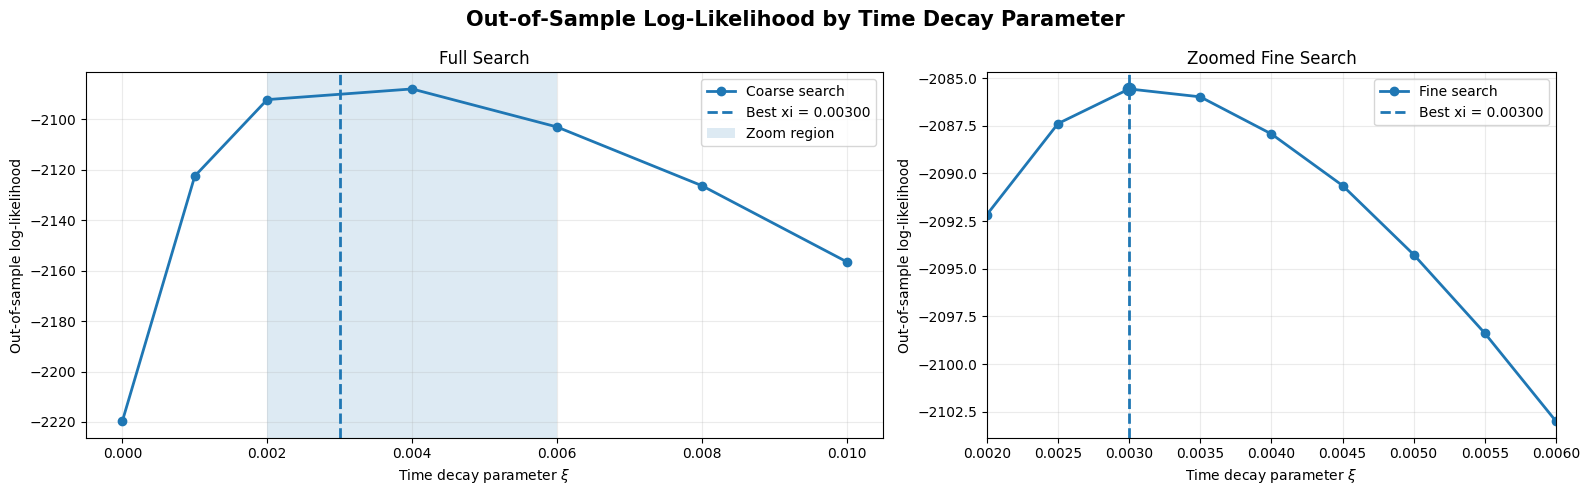

In [20]:
xi_coarse = np.asarray(xi_coarse)
ll_coarse = np.asarray(ll_coarse)

xi_fine = np.asarray(xi_fine)
ll_fine = np.asarray(ll_fine)

coarse_order = np.argsort(xi_coarse)
fine_order = np.argsort(xi_fine)

xi_coarse_plot = xi_coarse[coarse_order]
ll_coarse_plot = ll_coarse[coarse_order]

xi_fine_plot = xi_fine[fine_order]
ll_fine_plot = ll_fine[fine_order]

zoom_x_min = xi_fine_plot.min()
zoom_x_max = xi_fine_plot.max()

zoom_y_min = ll_fine_plot.min()
zoom_y_max = ll_fine_plot.max()
zoom_y_margin = 0.05 * (zoom_y_max - zoom_y_min) if zoom_y_max > zoom_y_min else 1

fig, axes = plt.subplots(1, 2,figsize=(16, 5),gridspec_kw={"width_ratios": [1.4, 1]})
ax1, ax2 = axes

ax1.plot(xi_coarse_plot,ll_coarse_plot,marker="o",linewidth=2,markersize=6,label="Coarse search")
ax1.axvline(best_xi,linestyle="--",linewidth=2,label=f"Best xi = {best_xi:.5f}")
ax1.axvspan(zoom_x_min,zoom_x_max,alpha=0.15,label="Zoom region")

ax1.set_xlabel(r"Time decay parameter $\xi$")
ax1.set_ylabel("Out-of-sample log-likelihood")
ax1.set_title("Full Search")
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2.plot(xi_fine_plot,ll_fine_plot,marker="o",linewidth=2,markersize=6,label="Fine search")
ax2.axvline(best_xi,linestyle="--",linewidth=2,label=f"Best xi = {best_xi:.5f}")
ax2.scatter([best_xi],[np.interp(best_xi, xi_fine_plot, ll_fine_plot)],s=80,zorder=5)

ax2.set_xlim(zoom_x_min, zoom_x_max)
ax2.set_ylim(zoom_y_min - zoom_y_margin, zoom_y_max + zoom_y_margin)

ax2.set_xlabel(r"Time decay parameter $\xi$")
ax2.set_ylabel("Out-of-sample log-likelihood")
ax2.set_title("Zoomed Fine Search")
ax2.grid(True, alpha=0.25)
ax2.legend()

fig.suptitle("Out-of-Sample Log-Likelihood by Time Decay Parameter",fontsize=15,fontweight="bold")
plt.tight_layout()

print(f"Best xi: {best_xi:.5f}")
print(f"Best fine log-likelihood: {np.nanmax(ll_fine):.2f}")

The final model after the time decay correction shows much better adjustments compared to the observed results in last year's season in Premier league with the Gamma distributions' parameters to not showing large changes. From the calibration check it can be seen that the ExG of the home teams are overestimated while the opposite effect is observed for the away team ExG.

In [21]:
def unpack(params):
    intercept = params[0]
    home_adv  = params[1]
    attack    = params[2 : 2 + n_teams]
    defense   = params[2 + n_teams : 2 + 2 * n_teams]
    phi       = np.exp(params[-1])
    return intercept, home_adv, attack, defense, phi


ref_final = dates.max()
age_final = (ref_final - dates).dt.days.values.astype(float)
w_final = np.exp(-best_xi * age_final)

res_final = minimize(
    make_nll(w_final, home_xg, away_xg, n_teams, compute_mu),
    x0=init, method="L-BFGS-B",
    options={"maxiter": 10000, "ftol": 1e-12})

intercept, home_adv, attack, defense, phi = unpack(res_final.x)
attack  = attack  - attack.mean()
defense = defense - defense.mean()
mu_h_final, mu_a_final, phi_final = compute_mu(res_final.x)

print(f"── Model Parameters ──────────────────────────")
print(f"  Best ξ      : {best_xi:.5f}")
if best_xi > 0:
    print(f"  Half-life   : {np.log(2)/best_xi:.1f} days")
print(f"  Intercept   : {intercept:.4f} ")
print(f"  Home Adv    : {home_adv:.4f} ")
print(f"  Phi (shape) : {phi:.4f}")

team_df = pd.DataFrame({"team"   : teams,"attack" : attack,"defense": defense,})
team_df["att_rank"] = team_df["attack"].rank(ascending=False).astype(int)
team_df["def_rank"] = team_df["defense"].rank(ascending=False).astype(int) 
team_df = team_df.sort_values("attack", ascending=False).reset_index(drop=True)

print("\n── Team Strengths ────────────────────────────")
print(team_df.round(3).to_string(index=False))


── Model Parameters ──────────────────────────
  Best ξ      : 0.00300
  Half-life   : 231.0 days
  Intercept   : 0.2637 
  Home Adv    : 0.2045 
  Phi (shape) : 3.4995

── Team Strengths ────────────────────────────
                   team  attack  defense  att_rank  def_rank
        Manchester City   0.463    0.311         1         2
                Arsenal   0.427    0.593         2         1
              Liverpool   0.398    0.234         3         3
                Chelsea   0.343    0.077         4        13
            Bournemouth   0.323    0.128         5         8
      Manchester United   0.296    0.161         6         5
              Brentford   0.256    0.077         7        14
       Newcastle United   0.254    0.079         8        12
         Crystal Palace   0.229    0.071         9        15
            Aston Villa   0.221    0.140        10         7
               Brighton   0.208    0.174        11         4
                  Leeds   0.185    0.149        12 

Having a functional ExGs model with the optimal time decay factor the ExGs can be predicted in a wide range for testing the accuracy and the effectiveness of the model. The same training time format is used here as before with the model trained every week and predicting only the events of the next week.

In [22]:
START_SEASON = "2022/2023"
MIN_TRAIN_MATCHES = 300
xi_used = best_xi
eps = 1e-10

model_df = df.copy()

date_col = "date"
season_col = "season" if "season" in model_df.columns else "Season"

home_team_col = "home" if "home" in model_df.columns else "HomeTeam"
away_team_col = "away" if "away" in model_df.columns else "AwayTeam"

home_xg_col = "home_xg" if "home_xg" in model_df.columns else "HomeXG"
away_xg_col = "away_xg" if "away_xg" in model_df.columns else "AwayXG"

needed_cols = [date_col,season_col,home_team_col,away_team_col,home_xg_col,away_xg_col]
model_df = model_df[needed_cols].copy()

model_df[date_col] = pd.to_datetime(model_df[date_col], errors="coerce")
model_df[season_col] = model_df[season_col].astype(str)

model_df[home_xg_col] = pd.to_numeric(model_df[home_xg_col], errors="coerce")
model_df[away_xg_col] = pd.to_numeric(model_df[away_xg_col], errors="coerce")

model_df = model_df.dropna().copy()
model_df = model_df.sort_values(date_col).reset_index(drop=True)

dates = model_df[date_col]

home_xg_array = np.clip(model_df[home_xg_col].values.astype(float), eps, None)
away_xg_array = np.clip(model_df[away_xg_col].values.astype(float), eps, None)

teams = sorted(set(model_df[home_team_col]) | set(model_df[away_team_col]))
team_to_idx = {team: i for i, team in enumerate(teams)}

home_idx = model_df[home_team_col].map(team_to_idx).values.astype(int)
away_idx = model_df[away_team_col].map(team_to_idx).values.astype(int)

n_teams = len(teams)
season_start_date = model_df.loc[model_df[season_col] == START_SEASON,date_col].min()


print("Matches:", len(model_df))
print("Teams:", n_teams)
print("Date range:", dates.min(), "to", dates.max())
print("Prediction starts from:", season_start_date)
print("xi used:", xi_used)

def safe_exp(x):
    return np.exp(np.clip(x, -20, 20))


def compute_mu_weekly(params):
    intercept = params[0]
    home_adv = params[1]

    attack_raw = params[2 : 2 + n_teams]
    defence_raw = params[2 + n_teams : 2 + 2 * n_teams]

    log_phi = params[-1]

    attack = attack_raw - attack_raw.mean()
    defence = defence_raw - defence_raw.mean()

    phi = safe_exp(log_phi)

    eta_home = intercept + home_adv + attack[home_idx] + defence[away_idx]
    eta_away = intercept + attack[away_idx] + defence[home_idx]

    mu_home = safe_exp(eta_home)
    mu_away = safe_exp(eta_away)

    return mu_home, mu_away, phi


def gamma_logpdf(y, mu, phi):
    y = np.clip(y, eps, None)
    mu = np.clip(mu, eps, None)
    phi = np.maximum(phi, eps)

    return (
        (phi - 1) * np.log(y)
        - y * (phi / mu)
        + phi * np.log(phi / mu)
        - gammaln(phi))


def make_nll_weekly(weights):
    def nll(params):
        mu_home, mu_away, phi = compute_mu_weekly(params)

        ll_home = gamma_logpdf(home_xg_array, mu_home, phi)
        ll_away = gamma_logpdf(away_xg_array, mu_away, phi)

        ll = (weights * ll_home).sum() + (weights * ll_away).sum()

        if not np.isfinite(ll):
            return 1e12

        return -ll

    return nll

n_params = 2 + 2 * n_teams + 1

init = np.zeros(n_params)
init[0] = np.log(np.mean(np.r_[home_xg_array, away_xg_array]))
init[1] = 0.10
init[-1] = np.log(5.0)

current_init = init.copy()

first_week_start = season_start_date.normalize()
week_start_for_match = first_week_start + pd.to_timedelta(((dates - first_week_start).dt.days // 7) * 7,unit="D")
unique_weeks = (pd.Series(week_start_for_match[dates >= first_week_start].unique()).sort_values().reset_index(drop=True))
prediction_rows = []
fit_rows = []

for wk_start in unique_weeks:
    wk_end = wk_start + pd.Timedelta(days=7)

    train_mask = (dates < wk_start).values
    test_mask = ((dates >= wk_start) & (dates < wk_end)).values

    n_train = int(train_mask.sum())
    n_test = int(test_mask.sum())

    if n_train < MIN_TRAIN_MATCHES or n_test == 0:
        continue

    age_from_ref = (wk_start - dates).dt.days.values.astype(float)
    weights = np.where(train_mask,np.exp(-xi_used * age_from_ref),0.0)

    res = minimize(make_nll_weekly(weights),x0=current_init,method="L-BFGS-B",options={"maxiter": 10000,"ftol": 1e-12})

    current_init = res.x.copy()
    mu_home_hat, mu_away_hat, phi_hat = compute_mu_weekly(res.x)
    test_indices = np.where(test_mask)[0]

    for i in test_indices:
        prediction_rows.append({
            "row_index": i,
            "week_start": wk_start,
            "week_end": wk_end,
            "date": dates.iloc[i],
            "season": model_df[season_col].iloc[i],
            "home": model_df[home_team_col].iloc[i],
            "away": model_df[away_team_col].iloc[i],
            "observed_home_xG": home_xg_array[i],
            "observed_away_xG": away_xg_array[i],
            "predicted_home_xG": mu_home_hat[i],
            "predicted_away_xG": mu_away_hat[i],
            "home_residual": home_xg_array[i] - mu_home_hat[i],
            "away_residual": away_xg_array[i] - mu_away_hat[i],
            "phi": phi_hat
        })

    fit_rows.append({
        "week_start": wk_start,
        "week_end": wk_end,
        "n_train": n_train,
        "n_test": n_test,
        "success": res.success,
        "nll": res.fun,
        "phi": phi_hat})


weekly_xg_predictions_df = pd.DataFrame(prediction_rows)
weekly_fit_summary_df = pd.DataFrame(fit_rows)


def xg_metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_true - y_pred

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(y_pred - y_true)

    denom = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - np.sum(error ** 2) / denom if denom > 0 else np.nan

    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "target": label,
        "n": len(y_true),
        "mean_observed": y_true.mean(),
        "mean_predicted": y_pred.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "bias_pred_minus_obs": bias,
        "R2": r2,
        "corr": corr}


home_metrics = xg_metrics(weekly_xg_predictions_df["observed_home_xG"],weekly_xg_predictions_df["predicted_home_xG"],"home_xG")
away_metrics = xg_metrics(weekly_xg_predictions_df["observed_away_xG"],weekly_xg_predictions_df["predicted_away_xG"],"away_xG")

all_obs = np.r_[weekly_xg_predictions_df["observed_home_xG"].values,weekly_xg_predictions_df["observed_away_xG"].values]
all_pred = np.r_[weekly_xg_predictions_df["predicted_home_xG"].values,weekly_xg_predictions_df["predicted_away_xG"].values]
all_metrics = xg_metrics(all_obs, all_pred, "all_xG")

xg_prediction_metrics_df = pd.DataFrame([home_metrics, away_metrics, all_metrics])

Matches: 4478
Teams: 35
Date range: 2014-08-16 00:00:00 to 2026-05-24 00:00:00
Prediction starts from: 2022-08-05 00:00:00
xi used: 0.003


The ExG values is a very noisy metric as it can be seen below plotted against the predictions but the highest probability weight is around the optimal line showing the agreement of mean between the model abd the observations. But the variance of the predictive values are rather large, which is not a surprise, since games can get very open with larger ExGs or closed defensive with lower ExGs.

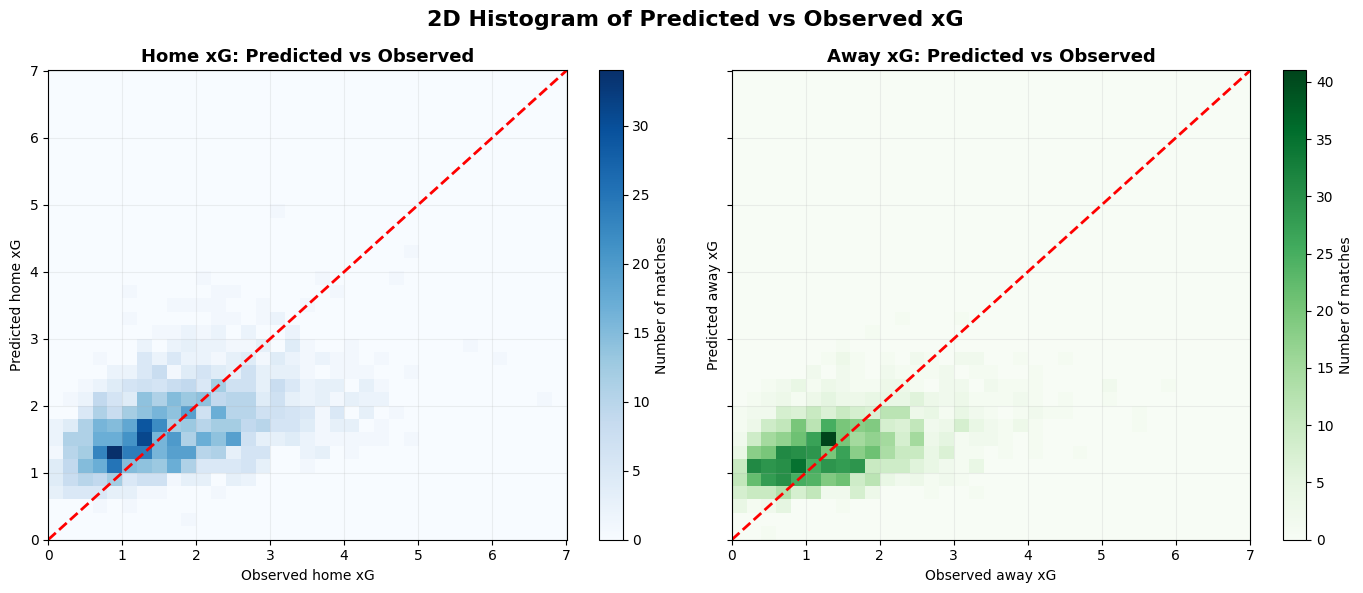

In [23]:
max_val = np.nanmax([
    weekly_xg_predictions_df["observed_home_xG"].max(),
    weekly_xg_predictions_df["predicted_home_xG"].max(),
    weekly_xg_predictions_df["observed_away_xG"].max(),
    weekly_xg_predictions_df["predicted_away_xG"].max()])
plot_lim = max_val * 1.05

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

h1 = axes[0].hist2d(weekly_xg_predictions_df["observed_home_xG"],weekly_xg_predictions_df["predicted_home_xG"],
    bins=35,range=[[0, plot_lim], [0, plot_lim]],cmap="Blues")

axes[0].plot([0, plot_lim], [0, plot_lim], linestyle="--", linewidth=2, color="red")
axes[0].set_title("Home xG: Predicted vs Observed", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Observed home xG")
axes[0].set_ylabel("Predicted home xG")
axes[0].grid(alpha=0.2)

cbar1 = plt.colorbar(h1[3], ax=axes[0])
cbar1.set_label("Number of matches")

h2 = axes[1].hist2d(weekly_xg_predictions_df["observed_away_xG"],weekly_xg_predictions_df["predicted_away_xG"],
    bins=35,range=[[0, plot_lim], [0, plot_lim]],cmap="Greens")

axes[1].plot([0, plot_lim], [0, plot_lim], linestyle="--", linewidth=2, color="red")
axes[1].set_title("Away xG: Predicted vs Observed", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Observed away xG")
axes[1].set_ylabel("Predicted away xG")
axes[1].grid(alpha=0.2)

cbar2 = plt.colorbar(h2[3], ax=axes[1])
cbar2.set_label("Number of matches")

plt.suptitle("2D Histogram of Predicted vs Observed xG", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Dixon Coles Correction:

The models' talked so far are for predicting the ExG values of the team in a football match. But the target is to predict the scoreline of a game which shouldn't need many modifications from the ExG model given that the ExG values are in agreement with the average values of goals scored.

Knowing from the simple Bivariate Poisson Model based on the goals' data that the low scores suffer from goals' dependancy the same approach is needed for this model as well. The Gamma distributions of the home's and away's team ExG arw assumed to be independent but this is not the realistic case. The same Dixon-Coles correction is applied to the Gamma distribution model showing an improvement to low scorelines and is the best model so far for predicting football matches:

In [24]:
eps = 1e-10
xi = best_xi
MAX_GOALS_BUCKET = 10
MIN_TRAIN_MATCHES = 300
START_SEASON = "2022/2023"

model_df = df.copy()
date_col = "date"
season_col = "season" if "season" in model_df.columns else "Season"

home_team_col = "home" if "home" in model_df.columns else "HomeTeam"
away_team_col = "away" if "away" in model_df.columns else "AwayTeam"

home_xg_col = "home_xg" if "home_xg" in model_df.columns else "HomeXG"
away_xg_col = "away_xg" if "away_xg" in model_df.columns else "AwayXG"

home_goal_col = "home_goals" if "home_goals" in model_df.columns else "HomeGoals"
away_goal_col = "away_goals" if "away_goals" in model_df.columns else "AwayGoals"

needed_cols = [date_col, season_col, home_team_col, away_team_col,
               home_xg_col, away_xg_col, home_goal_col, away_goal_col]

model_df = model_df[needed_cols].copy()
model_df[date_col] = pd.to_datetime(model_df[date_col], errors="coerce")

for col in [home_xg_col, away_xg_col, home_goal_col, away_goal_col]:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()
model_df[season_col] = model_df[season_col].astype(str)
model_df[home_goal_col] = model_df[home_goal_col].astype(int)
model_df[away_goal_col] = model_df[away_goal_col].astype(int)
model_df = model_df.sort_values(date_col).reset_index(drop=True)

dates = model_df[date_col]

home_xg_safe = np.clip(model_df[home_xg_col].values.astype(float), eps, None)
away_xg_safe = np.clip(model_df[away_xg_col].values.astype(float), eps, None)

home_goals = model_df[home_goal_col].values.astype(int)
away_goals = model_df[away_goal_col].values.astype(int)

teams = sorted(set(model_df[home_team_col]) | set(model_df[away_team_col]))
team_to_idx = {team: i for i, team in enumerate(teams)}

home_idx = model_df[home_team_col].map(team_to_idx).values.astype(int)
away_idx = model_df[away_team_col].map(team_to_idx).values.astype(int)

n_teams = len(teams)
season_start_date = model_df.loc[model_df[season_col] == START_SEASON, date_col].min()

def safe_exp(x):
    return np.exp(np.clip(x, -20, 20))

n_params = 2 + 2 * (n_teams - 1) + 1


def unpack(params):
    intercept = params[0]
    home_adv = params[1]

    attack_free = params[2:2 + (n_teams - 1)]
    defence_free = params[2 + (n_teams - 1):2 + 2 * (n_teams - 1)]

    attack = np.append(attack_free, -attack_free.sum())
    defence = np.append(defence_free, -defence_free.sum())

    log_phi = params[-1]
    phi = safe_exp(log_phi)

    return intercept, home_adv, attack, defence, phi


def compute_mu(params):
    intercept, home_adv, attack, defence, phi = unpack(params)

    eta_home = intercept + home_adv + attack[home_idx] + defence[away_idx]
    eta_away = intercept + attack[away_idx] + defence[home_idx]

    mu_home = safe_exp(eta_home)
    mu_away = safe_exp(eta_away)

    return mu_home, mu_away, phi


def gamma_logpdf(y, mu, phi):
    y = np.clip(y, eps, None)
    mu = np.clip(mu, eps, None)
    phi = np.maximum(phi, eps)

    return (
        (phi - 1) * np.log(y)
        - y * (phi / mu)
        + phi * np.log(phi / mu)
        - gammaln(phi)
    )


def make_gamma_nll(weights):
    def nll(params):
        mu_home, mu_away, phi = compute_mu(params)

        ll_home = gamma_logpdf(home_xg_safe, mu_home, phi)
        ll_away = gamma_logpdf(away_xg_safe, mu_away, phi)

        ll = (weights * ll_home).sum() + (weights * ll_away).sum()

        if not np.isfinite(ll):
            return 1e12

        return -ll

    return nll


def dc_tau(hg, ag, mu_h, mu_a, rho):
    tau = np.ones_like(mu_h, dtype=float)

    mask_00 = (hg == 0) & (ag == 0)
    mask_10 = (hg == 1) & (ag == 0)
    mask_01 = (hg == 0) & (ag == 1)
    mask_11 = (hg == 1) & (ag == 1)

    tau[mask_00] = 1 - mu_h[mask_00] * mu_a[mask_00] * rho
    tau[mask_10] = 1 + mu_a[mask_10] * rho
    tau[mask_01] = 1 + mu_h[mask_01] * rho
    tau[mask_11] = 1 - rho

    return tau


def make_dc_nll(train_mask, weights, mu_home_hat, mu_away_hat):
    def nll(rho_array):
        rho = rho_array[0]

        tau = dc_tau(home_goals, away_goals, mu_home_hat, mu_away_hat, rho)

        if np.any(tau[train_mask] <= 0) or not np.all(np.isfinite(tau[train_mask])):
            return 1e12

        score_ll = (poisson.logpmf(home_goals, mu_home_hat)
                    + poisson.logpmf(away_goals, mu_away_hat)
                    + np.log(tau))

        ll = (weights[train_mask] * score_ll[train_mask]).sum()

        if not np.isfinite(ll):
            return 1e12

        return -ll

    return nll


def poisson_bucket_probs(mu, max_goal_bucket=10):
    exact_goals = np.arange(max_goal_bucket)
    probs = poisson.pmf(exact_goals, mu)
    tail_prob = 1 - poisson.cdf(max_goal_bucket - 1, mu)

    return np.append(probs, tail_prob)


def score_matrix_gamma(mu_h, mu_a, max_goal_bucket=10):
    p_home = poisson_bucket_probs(mu_h, max_goal_bucket)
    p_away = poisson_bucket_probs(mu_a, max_goal_bucket)

    return np.outer(p_home, p_away)


def score_matrix_gamma_dc(mu_h, mu_a, rho_dc, max_goal_bucket=10):
    mat = score_matrix_gamma(mu_h, mu_a, max_goal_bucket)

    mat[0, 0] *= 1 - mu_h * mu_a * rho_dc
    mat[1, 0] *= 1 + mu_a * rho_dc
    mat[0, 1] *= 1 + mu_h * rho_dc
    mat[1, 1] *= 1 - rho_dc

    mat = np.clip(mat, 0, None)
    mat = mat / mat.sum()

    return mat


def matrix_to_df(mat, max_goal_bucket=10):
    labels = [str(i) for i in range(max_goal_bucket)]
    labels.append(f"{max_goal_bucket}+")

    return pd.DataFrame(100 * mat,
                        index=[f"Home {label}" for label in labels],
                        columns=[f"Away {label}" for label in labels])


def actual_score_matrix(hg, ag, max_goal_bucket=10):
    mat = np.zeros((max_goal_bucket + 1, max_goal_bucket + 1))

    hg_bucket = min(int(hg), max_goal_bucket)
    ag_bucket = min(int(ag), max_goal_bucket)

    mat[hg_bucket, ag_bucket] = 1.0

    return mat, hg_bucket, ag_bucket
    
init = np.zeros(n_params)
init[0] = np.log(np.mean(np.r_[home_xg_safe, away_xg_safe]))
init[1] = 0.1
init[-1] = np.log(5.0)

current_init = init.copy()

first_week_start = season_start_date.normalize()

week_start = first_week_start + pd.to_timedelta(
    ((dates - first_week_start).dt.days // 7) * 7, unit="D")

unique_weeks = (pd.Series(week_start[dates >= first_week_start].unique())
                .sort_values()
                .reset_index(drop=True))

obs_mat = np.zeros((MAX_GOALS_BUCKET + 1, MAX_GOALS_BUCKET + 1))
gamma_pred_sum = np.zeros_like(obs_mat, dtype=float)
gamma_dc_pred_sum = np.zeros_like(obs_mat, dtype=float)

brier_gamma_scores = []
brier_gamma_dc_scores = []

actual_score_probs_gamma = []
actual_score_probs_gamma_dc = []

log_loss_gamma_scores = []
log_loss_gamma_dc_scores = []

weekly_results = []
n_pred_matches = 0
n_fit_failures = 0

for wk_start in unique_weeks:
    wk_end = wk_start + pd.Timedelta(days=7)

    train_mask = dates < wk_start
    test_mask = (dates >= wk_start) & (dates < wk_end)

    n_train = int(train_mask.sum())
    n_test = int(test_mask.sum())

    if n_train < MIN_TRAIN_MATCHES or n_test == 0:
        continue

    age_from_ref = (wk_start - dates).dt.days.values.astype(float)
    raw_w = np.where(train_mask.values, np.exp(-xi * age_from_ref), 0.0)
    train_w = raw_w[train_mask.values]
    mean_w = train_w.mean() if train_w.size and train_w.mean() > 0 else 1.0
    weights = raw_w / mean_w

    gamma_fit = minimize(make_gamma_nll(weights),current_init,method="L-BFGS-B",
        options={"maxiter": 20000,"maxfun": 200000,"ftol": 1e-9,"gtol": 1e-6,"maxls": 50})

    usable = np.all(np.isfinite(gamma_fit.x)) and np.isfinite(gamma_fit.fun)
    if not usable:
        n_fit_failures += 1
        print("Gamma fit unusable for week:", wk_start.date(), "|", gamma_fit.message)
        continue

    gamma_params = gamma_fit.x
    current_init = gamma_params.copy()

    mu_home_hat, mu_away_hat, phi_hat = compute_mu(gamma_params)

    rho_fit = minimize(
        make_dc_nll(train_mask.values, weights, mu_home_hat, mu_away_hat),
        x0=np.array([-0.05]),
        method="L-BFGS-B",
        bounds=[(-0.25, 0.25)],
        options={"maxiter": 10000, "maxfun": 50000})

    if rho_fit.success or np.isfinite(rho_fit.fun):
        rho_dc_hat = rho_fit.x[0]
    else:
        rho_dc_hat = 0.0

    test_indices = np.where(test_mask.values)[0]

    for i in test_indices:
        mat_gamma = score_matrix_gamma(
            mu_home_hat[i], mu_away_hat[i], max_goal_bucket=MAX_GOALS_BUCKET)

        mat_gamma_dc = score_matrix_gamma_dc(
            mu_home_hat[i], mu_away_hat[i], rho_dc_hat, max_goal_bucket=MAX_GOALS_BUCKET)

        actual_mat, hg_bucket, ag_bucket = actual_score_matrix(
            home_goals[i], away_goals[i], max_goal_bucket=MAX_GOALS_BUCKET)

        brier_gamma = np.sum((mat_gamma - actual_mat) ** 2)
        brier_gamma_dc = np.sum((mat_gamma_dc - actual_mat) ** 2)

        prob_actual_gamma = mat_gamma[hg_bucket, ag_bucket]
        prob_actual_gamma_dc = mat_gamma_dc[hg_bucket, ag_bucket]

        brier_gamma_scores.append(brier_gamma)
        brier_gamma_dc_scores.append(brier_gamma_dc)

        actual_score_probs_gamma.append(prob_actual_gamma)
        actual_score_probs_gamma_dc.append(prob_actual_gamma_dc)

        log_loss_gamma_scores.append(-np.log(np.clip(prob_actual_gamma, eps, 1)))
        log_loss_gamma_dc_scores.append(-np.log(np.clip(prob_actual_gamma_dc, eps, 1)))

        gamma_pred_sum += mat_gamma
        gamma_dc_pred_sum += mat_gamma_dc
        obs_mat += actual_mat

        n_pred_matches += 1

    weekly_results.append({
        "week_start": wk_start,
        "week_end": wk_end,
        "n_train": n_train,
        "n_test": n_test,
        "gamma_success": gamma_fit.success,
        "gamma_nll": gamma_fit.fun,
        "phi": phi_hat,
        "rho_dc": rho_dc_hat,
    })

print("\nDone.")
print("Predicted matches:", n_pred_matches)
print("Fit failures:", n_fit_failures)
if log_loss_gamma_scores:
    print(f"Mean log-loss  Gamma:    {np.mean(log_loss_gamma_scores):.4f}")
    print(f"Mean log-loss  Gamma+DC: {np.mean(log_loss_gamma_dc_scores):.4f}")
    print(f"Mean Brier     Gamma:    {np.mean(brier_gamma_scores):.4f}")
    print(f"Mean Brier     Gamma+DC: {np.mean(brier_gamma_dc_scores):.4f}")

weekly_results = pd.DataFrame(weekly_results)


Done.
Predicted matches: 1520
Fit failures: 0
Mean log-loss  Gamma:    2.9837
Mean log-loss  Gamma+DC: 2.9835
Mean Brier     Gamma:    0.9351
Mean Brier     Gamma+DC: 0.9351


The Dixon Coles model provides a small and consistent improvement of the model but the difference is very small especially compared with the model's difference with the rest of higher scorelines such as 3-0. Fundamentally the ExG should predict the scorelines directly without this type of correlation as it was found out.

In [25]:
observed_mat = obs_mat / n_pred_matches
gamma_mat = gamma_pred_sum / n_pred_matches
gamma_dc_mat = gamma_dc_pred_sum / n_pred_matches

diff_gamma = gamma_mat - observed_mat
diff_gamma_dc = gamma_dc_mat - observed_mat

observed_df = matrix_to_df(observed_mat, MAX_GOALS_BUCKET)
gamma_df = matrix_to_df(gamma_mat, MAX_GOALS_BUCKET)
gamma_dc_df = matrix_to_df(gamma_dc_mat, MAX_GOALS_BUCKET)

diff_gamma_df = matrix_to_df(diff_gamma, MAX_GOALS_BUCKET)
diff_gamma_dc_df = matrix_to_df(diff_gamma_dc, MAX_GOALS_BUCKET)

weekly_results_df = pd.DataFrame(weekly_results)

brier_by_match_df = pd.DataFrame({
    "brier_gamma": brier_gamma_scores,
    "brier_gamma_dc": brier_gamma_dc_scores,
    "actual_score_prob_gamma": actual_score_probs_gamma,
    "actual_score_prob_gamma_dc": actual_score_probs_gamma_dc,
    "log_loss_gamma": log_loss_gamma_scores,
    "log_loss_gamma_dc": log_loss_gamma_dc_scores})

print("\nBrier score by match summary")
display(brier_by_match_df.describe().round(5))



Brier score by match summary


,brier_gamma,brier_gamma_dc,actual_score_prob_gamma,actual_score_prob_gamma_dc,log_loss_gamma,log_loss_gamma_dc
count,1520.00000,1520.00000,1520.00000,1520.00000,1520.00000,1520.00000
mean,0.93505,0.93506,0.06370,0.06376,2.98372,2.98355
std,0.06497,0.06535,0.03309,0.03327,0.84532,0.84599
min,0.79114,0.78258,0.00013,0.00013,1.87497,1.85544
25%,0.88358,0.88387,0.03764,0.03793,2.41490,2.41588
50%,0.93125,0.93127,0.06444,0.06453,2.74198,2.74065
75%,0.98498,0.98517,0.08938,0.08929,3.27972,3.27213
max,1.08228,1.08228,0.15336,0.15638,8.93153,8.93153


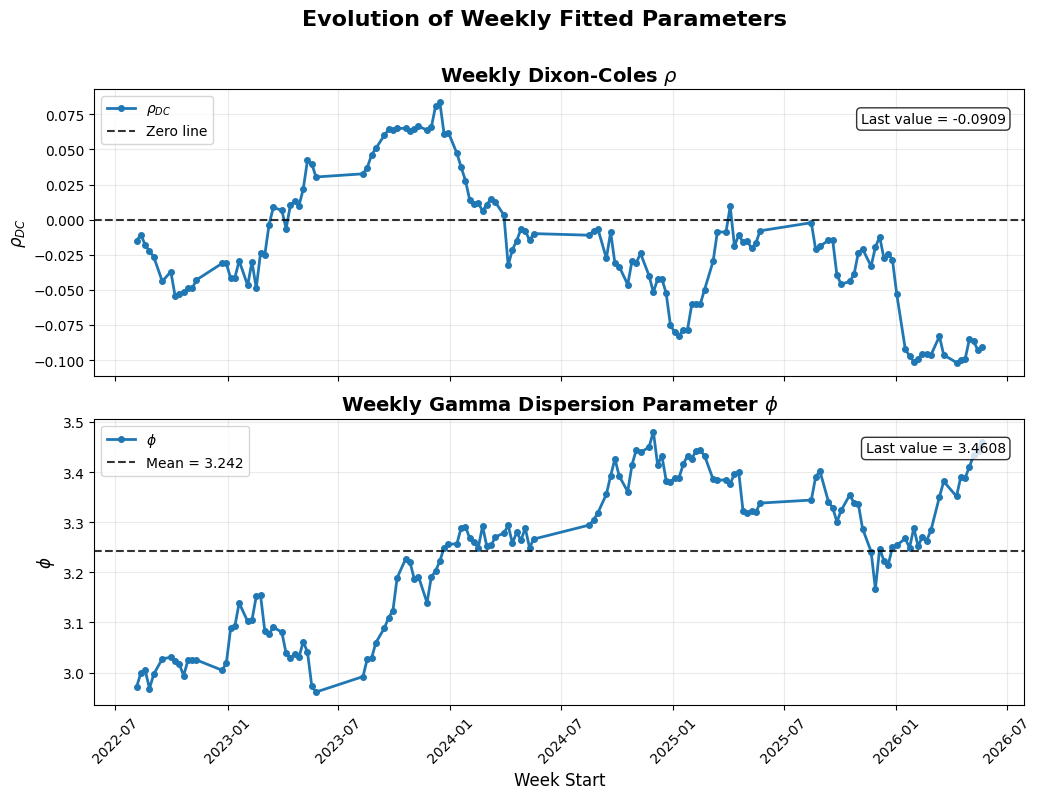

In [26]:
weekly_results_df["week_start"] = pd.to_datetime(weekly_results_df["week_start"])

fig, axes = plt.subplots(2, 1,figsize=(12, 8),sharex=True,gridspec_kw={"hspace": 0.15})

axes[0].plot(weekly_results_df["week_start"],weekly_results_df["rho_dc"],linewidth=2,marker="o",markersize=4,label=r"$\rho_{DC}$")
axes[0].axhline(0,linestyle="--",linewidth=1.5,color="black",alpha=0.8,label="Zero line")

axes[0].set_title("Weekly Dixon-Coles $\\rho$", fontsize=14, fontweight="bold")
axes[0].set_ylabel(r"$\rho_{DC}$", fontsize=12)
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[0].text(0.98, 0.92,f"Last value = {weekly_results_df['rho_dc'].iloc[-1]:.4f}",transform=axes[0].transAxes,
    ha="right",va="top",fontsize=10,bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

axes[1].plot(weekly_results_df["week_start"],weekly_results_df["phi"],linewidth=2,marker="o",markersize=4,label=r"$\phi$")
axes[1].axhline(weekly_results_df["phi"].mean(),linestyle="--",linewidth=1.5,color="black",alpha=0.8,
    label=f"Mean = {weekly_results_df['phi'].mean():.3f}")

axes[1].set_title("Weekly Gamma Dispersion Parameter $\\phi$", fontsize=14, fontweight="bold")
axes[1].set_ylabel(r"$\phi$", fontsize=12)
axes[1].set_xlabel("Week Start", fontsize=12)
axes[1].grid(True, alpha=0.25)
axes[1].legend()

axes[1].text(0.98, 0.92,f"Last value = {weekly_results_df['phi'].iloc[-1]:.4f}",transform=axes[1].transAxes,
    ha="right",va="top",fontsize=10,bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Evolution of Weekly Fitted Parameters",fontsize=16,fontweight="bold")
qq = plt.xticks(rotation=45)

In [27]:
print("\nObserved correct score matrix (%)")
display(observed_df.round(2))

print("\nDifference: Weekly Gamma-Poisson minus observed, percentage points")
display(diff_gamma_df.round(3))

print("\nDifference: Weekly Gamma-Poisson + Dixon-Coles minus observed, percentage points")
display(diff_gamma_dc_df.round(3))


Observed correct score matrix (%)


,Away 0,Away 1,Away 2,Away 3,Away 4,Away 5,Away 6,Away 7,Away 8,Away 9,Away 10+
Home 0,5.07,6.64,5.59,2.50,0.99,0.46,0.20,0.0,0.07,0.0,0.0
Home 1,7.83,11.05,6.64,2.96,1.45,0.46,0.07,0.0,0.00,0.0,0.0
Home 2,6.58,8.88,6.84,2.04,0.72,0.13,0.07,0.0,0.00,0.0,0.0
Home 3,4.67,5.26,2.70,0.86,0.33,0.00,0.07,0.0,0.00,0.0,0.0
Home 4,1.51,2.30,1.18,0.92,0.26,0.07,0.00,0.0,0.00,0.0,0.0
Home 5,0.86,0.59,0.33,0.13,0.00,0.00,0.00,0.0,0.00,0.0,0.0
Home 6,0.20,0.20,0.07,0.07,0.00,0.00,0.00,0.0,0.00,0.0,0.0
Home 7,0.13,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0
Home 8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0
Home 9,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0



Difference: Weekly Gamma-Poisson minus observed, percentage points


,Away 0,Away 1,Away 2,Away 3,Away 4,Away 5,Away 6,Away 7,Away 8,Away 9,Away 10+
Home 0,-0.036,0.068,-0.724,0.048,0.090,-0.070,-0.071,0.037,-0.056,0.003,0.001
Home 1,0.075,-1.050,0.236,0.457,-0.074,0.014,0.080,0.041,0.011,0.003,0.001
Home 2,0.204,-0.744,-1.529,0.467,0.234,0.183,0.027,0.025,0.006,0.001,0.000
Home 3,-0.458,-0.471,0.273,0.476,0.155,0.151,-0.023,0.011,0.003,0.001,0.000
Home 4,0.610,-0.014,0.163,-0.347,-0.065,-0.007,0.016,0.004,0.001,0.000,0.000
Home 5,0.069,0.350,0.198,0.082,0.070,0.020,0.005,0.001,0.000,0.000,0.000
Home 6,0.164,0.150,0.119,0.006,0.022,0.006,0.001,0.000,0.000,0.000,0.000
Home 7,-0.001,0.118,0.060,0.022,0.007,0.002,0.000,0.000,0.000,0.000,0.000
Home 8,0.045,0.038,0.018,0.006,0.002,0.000,0.000,0.000,0.000,0.000,0.000
Home 9,-0.051,0.011,0.005,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000



Difference: Weekly Gamma-Poisson + Dixon-Coles minus observed, percentage points


,Away 0,Away 1,Away 2,Away 3,Away 4,Away 5,Away 6,Away 7,Away 8,Away 9,Away 10+
Home 0,0.165,-0.133,-0.724,0.048,0.090,-0.070,-0.071,0.037,-0.056,0.003,0.001
Home 1,-0.125,-0.850,0.236,0.457,-0.074,0.014,0.080,0.041,0.011,0.003,0.001
Home 2,0.204,-0.744,-1.529,0.467,0.234,0.183,0.027,0.025,0.006,0.001,0.000
Home 3,-0.458,-0.471,0.273,0.476,0.155,0.151,-0.023,0.011,0.003,0.001,0.000
Home 4,0.610,-0.014,0.163,-0.347,-0.065,-0.007,0.016,0.004,0.001,0.000,0.000
Home 5,0.069,0.350,0.198,0.082,0.070,0.020,0.005,0.001,0.000,0.000,0.000
Home 6,0.164,0.150,0.119,0.006,0.022,0.006,0.001,0.000,0.000,0.000,0.000
Home 7,-0.001,0.118,0.060,0.022,0.007,0.002,0.000,0.000,0.000,0.000,0.000
Home 8,0.045,0.038,0.018,0.006,0.002,0.000,0.000,0.000,0.000,0.000,0.000
Home 9,-0.051,0.011,0.005,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## Football model with ExGs' dependancy:

The home and away ExG are correlated but the nature of this dependancy is more complex than just some linear correlation. As it can be shown below the different sides' ExGs are negatively correlated by -0.25. The approach tha will be explored here for including dependancy is by introducing a copula function to the gamma distribution model, which keeps the average estimated values unchanged but changes the marginal distribution of the home and away ExGs. The overall target of this section is to explore copulas applications in sports statistical models in general.

In [142]:
df[['home_xg', 'away_xg']].corr()

,home_xg,away_xg
home_xg,1.000000,-0.246991
away_xg,-0.246991,1.000000


### Bivariate Gaussian Copula Model for Match xG:

In the models applied so far the home and away teams' ExGs were assumed to be independent with each other. But there is no theoretical reason to assume that for a dynamic sport like football so it has to be tested with a copula model which captures statistical dependence in a more effective way than simple correlation coefficients. Although the copulas' process might seem 
mathematically complicated for the 2 variables case it is easy to compute. The main idea behind it is that the correlation of the order of data is constant across transformations and can capture the correlation in an not uniform way, something that simple correlation coefficients fail to do.

The same gamma distributions' model is used also here at first satge with its structure being:

$$Y_h \sim \text{Gamma}(\phi,\ \mu_h / \phi)$$
$$Y_a \sim \text{Gamma}(\phi,\ \mu_a / \phi)$$


$$\mu_h = \exp\!\left(\alpha + \delta + \lambda_{h} - \gamma_{a}\right)$$
$$\mu_a = \exp\!\left(\alpha + \lambda_{a} - \gamma_{h}\right) \\ $$



By Sklar's Theorem, any bivariate joint distribution $F(y_h, y_a)$ can be 
decomposed as:

$$F(y_h, y_a) = C\!\left(F_h(y_h),\ F_a(y_a)\right)$$

where $C:[0,1]^2 \to [0,1]$ is a copula and $F_h$, $F_a$ are the Gamma 
marginal CDFs.


The copulas are fitted to data which is an exception compared to the majority of fitting data to a model. Practically 
the area of interest of variables' values ranges are choosen before applying a copula depending on which area high
correlation is expected. A simple case that captures the correlation away from the ExGs' distribution tails is the Gaussin copula that will be used here with formula:

$$C_\rho(u, v) = \Phi_2\!\left(\Phi^{-1}(u),\ \Phi^{-1}(v);\ \rho\right)$$

where:
- $\Phi^{-1}(\cdot)$ is the standard normal quantile function (probit transform)
- $\Phi_2(\cdot,\cdot;\rho)$ is the bivariate standard normal CDF with 
  correlation $\rho \in (-1, 1)$
- $u = F_h(y_h)$, $v = F_a(y_a)$ are the **probability integral transforms**


The bivariate Gaussian copula density is:

$$c_\rho(u, v) = \frac{1}{\sqrt{1 - \rho^2}} \exp\!\left(
    -\frac{\rho^2(z_1^2 + z_2^2) - 2\rho z_1 z_2}{2(1-\rho^2)}
\right)$$

where $z_1 = \Phi^{-1}(u)$, $z_2 = \Phi^{-1}(v)$.


For $M$ matches, the full joint log-likelihood decomposes as:

$$\ell(\theta) = \underbrace{\sum_{m=1}^{M} \log f_h(y_{h,m})}_{\text{home marginal}}
              + \underbrace{\sum_{m=1}^{M} \log f_a(y_{a,m})}_{\text{away marginal}}
              + \underbrace{\sum_{m=1}^{M} \log c_\rho(u_m, v_m)}_{\text{copula correction}}$$

where the Gamma log-density and the log form of the copula are:

$$\log f(y;\mu,\phi) = (\phi-1)\log y - \frac{y\phi}{\mu} + \phi\log\frac{\phi}{\mu} - \log\Gamma(\phi)$$

$$\log c_\rho(u,v) = -\frac{1}{2}\log(1-\rho^2) - \frac{\rho^2(z_1^2 + z_2^2) - 2\rho z_1 z_2}{2(1-\rho^2)}$$


The joint dependence between home ExG and away ExG is modeled with a single correlation parameter ρ (rho):

- ρ > 0 → open games: both teams' ExG tend to rise together
- ρ < 0 → tactical trade-off: one team attacks, the other defends 
- ρ ≈ 0 → near-independent ExGs

In [184]:
df = df.reset_index(drop=True)
eps = 1e-10

dates = pd.to_datetime(df["date"])
ref_date = dates.max()
age_days = (ref_date - dates).dt.days.values.astype(float)

xi = 0.0030
best_weights = np.exp(-xi * age_days)

home_xg_col = "home_OpenPlay_xG" if "home_OpenPlay_xG" in df.columns else "home_xg"
away_xg_col = "away_OpenPlay_xG" if "away_OpenPlay_xG" in df.columns else "away_xg"
home_xg = np.clip(df[home_xg_col].to_numpy(dtype=float), eps, None)
away_xg = np.clip(df[away_xg_col].to_numpy(dtype=float), eps, None)

home_goal_col = "home_goals" if "home_goals" in df.columns else "HomeGoals"
away_goal_col = "away_goals" if "away_goals" in df.columns else "AwayGoals"
home_goals = df[home_goal_col].to_numpy(dtype=int)
away_goals = df[away_goal_col].to_numpy(dtype=int)

home_team_col = "home" if "home" in df.columns else "HomeTeam"
away_team_col = "away" if "away" in df.columns else "AwayTeam"
teams = sorted(set(df[home_team_col]) | set(df[away_team_col]))
team_idx = {t: i for i, t in enumerate(teams)}
n_teams = len(teams)
home_id = df[home_team_col].map(team_idx).to_numpy()
away_id = df[away_team_col].map(team_idx).to_numpy()

_lengths = {
    "best_weights": len(best_weights), "home_xg": len(home_xg), "away_xg": len(away_xg),
    "home_goals": len(home_goals), "away_goals": len(away_goals),
    "home_id": len(home_id), "away_id": len(away_id)}
assert len(set(_lengths.values())) == 1, f"Length mismatch: {_lengths}"

N_PARAMS = 2 + 2 * n_teams + 2
IDX_INTERCEPT = 0
IDX_HOME_ADV = 1
IDX_ATT = slice(2, 2 + n_teams)
IDX_DEF = slice(2 + n_teams, 2 + 2 * n_teams)
IDX_LOG_PHI = 2 + 2 * n_teams
IDX_RHO_RAW = 2 + 2 * n_teams + 1


def unpack(params):
    intercept = params[IDX_INTERCEPT]
    home_adv = params[IDX_HOME_ADV]
    attack = params[IDX_ATT]
    defense = params[IDX_DEF]
    phi = np.exp(params[IDX_LOG_PHI])
    rho = np.tanh(params[IDX_RHO_RAW])
    return intercept, home_adv, attack, defense, phi, rho


def compute_mu(params):
    intercept, home_adv, attack, defense, phi, rho = unpack(params)
    attack = attack - attack.mean()
    defense = defense - defense.mean()
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi, rho


def gamma_logpdf(y, mu, phi):
    return (phi - 1) * np.log(y) - y * (phi / mu) + phi * np.log(phi / mu) - gammaln(phi)


def neg_log_likelihood(params):
    mu_home, mu_away, phi, rho = compute_mu(params)
    mu_home = np.clip(mu_home, eps, None)
    mu_away = np.clip(mu_away, eps, None)

    ll_home = best_weights * gamma_logpdf(home_xg, mu_home, phi)
    ll_away = best_weights * gamma_logpdf(away_xg, mu_away, phi)

    u = gamma_dist.cdf(home_xg, a=phi, scale=mu_home / phi)
    v = gamma_dist.cdf(away_xg, a=phi, scale=mu_away / phi)
    u = np.clip(u, 1e-6, 1 - 1e-6)
    v = np.clip(v, 1e-6, 1 - 1e-6)

    z1 = norm.ppf(u)
    z2 = norm.ppf(v)

    rho2 = rho ** 2
    copula_ll = best_weights * (-0.5 * np.log(1 - rho2) - (rho2 * (z1 ** 2 + z2 ** 2) - 2 * rho * z1 * z2) / (2 * (1 - rho2)))

    ll = ll_home.sum() + ll_away.sum() + copula_ll.sum()

    if not np.isfinite(ll):
        return 1e12
    return -ll


init = np.zeros(N_PARAMS)
init[IDX_INTERCEPT] = np.log(np.mean(home_xg))
init[IDX_HOME_ADV] = 0.1
init[IDX_LOG_PHI] = np.log(5.0)
init[IDX_RHO_RAW] = 0.0

result = minimize(
    neg_log_likelihood,
    x0=init,
    method="L-BFGS-B",
    options={"maxiter": 100000, "ftol": 1e-12})

intercept, home_adv, attack, defense, phi, rho = unpack(result.x)
attack = attack - attack.mean()
defense = defense - defense.mean()

print("\n── Model Parameters ───────────────────────────────────")
print(f"  Intercept    : {intercept:.4f}")
print(f"  Home Adv     : {home_adv:.4f} ")
print(f"  Phi (shape)  : {phi:.4f}")
print(f"  Rho (copula) : {rho:.4f}  ({'positive' if rho > 0 else 'negative'} correlation)")


── Model Parameters ───────────────────────────────────
  Intercept    : 0.2501
  Home Adv     : 0.2045 
  Phi (shape)  : 3.4244
  Rho (copula) : -0.0542  (negative correlation)


The $\rho$ of the copula fitted is -0.054 which practically means that the correlation is negative but very weak so the effect should be very small. The value of $\rho$ is much smaller than the correlation value shown in the observatiuons before showing that the first metric is misleading due to high randomness in the ExGs. This vakue of $\rho$ is not accurate enough since the time decay effect wasn;t applied but it the next cells it is shown the actual value of $\rho$ is -0.0855 for the joint ExG distribution.

Although the mean values shouldn't be much different after including the Gaussian Copula extension the optimal half life value doesn't necessary stays the same, so the weekly walk fitting has to be done for the extended model. In general the difference should be very small so it will be skipped here and the same 230 days half life will be used for the copula extended model as well.

Now the indepedent and the copula included gamma models can be compared on their respected AIC and BIC metrics. The independent model seems better althought there is a very small improvement in terms of likelihood for the copula extended model here but this was expected since the metric used doesn't capture the joint distribution accuracy but the marginals, so a different test is needed.

In [192]:
def _fit_weights(half_life):
    ref_date = dates.max()
    age_days = (ref_date - dates).dt.days.to_numpy(dtype=float)
    return 0.5 ** (age_days / float(half_life))

best_h_copula = 230
best_h_ind = 230
fit_w_c = _fit_weights(best_h_copula)
fit_w_ind = _fit_weights(best_h_ind)
n_obs = len(df)


def gamma_logpdf(y, mu, phi):
    mu = np.clip(mu, eps, None)
    phi = np.maximum(phi, eps)
    return (phi - 1) * np.log(y) - y * (phi / mu) + phi * np.log(phi / mu) - gammaln(phi)

def nll_copula(params):
    mu_h, mu_a, phi, rho = compute_mu(params, home_id_all, away_id_all)
    ll = copula_joint_loglik(home_xg_all, away_xg_all, mu_h, mu_a, phi, rho, weights=fit_w_c).sum()
    return -ll if np.isfinite(ll) else 1e12


init_copula = np.zeros(N_PARAMS)
init_copula[IDX_INTERCEPT] = np.log(np.mean(home_xg_all))
init_copula[IDX_HOME_ADV] = 0.1
init_copula[IDX_LOG_PHI] = np.log(5.0)
init_copula[IDX_RHO_RAW] = 0.0

res_copula = minimize(nll_copula, x0=init_copula, method="L-BFGS-B",
                       options={"maxiter": 20000, "maxfun": 200000, "ftol": 1e-9})

k_copula = N_PARAMS
ll_copula = -res_copula.fun


N_PARAMS_INDEP = 2 + 2 * n_teams + 1  # one fewer param: no rho
IDX_INTERCEPT_I = 0
IDX_HOME_ADV_I = 1
IDX_ATT_I = slice(2, 2 + n_teams)
IDX_DEF_I = slice(2 + n_teams, 2 + 2 * n_teams)
IDX_LOG_PHI_I = 2 + 2 * n_teams


def compute_mu_indep(params, home_id, away_id):
    intercept = params[IDX_INTERCEPT_I]
    home_adv = params[IDX_HOME_ADV_I]
    attack = params[IDX_ATT_I] - params[IDX_ATT_I].mean()
    defense = params[IDX_DEF_I] - params[IDX_DEF_I].mean()
    phi = np.exp(params[IDX_LOG_PHI_I])
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi


def nll_indep(params):
    mu_h, mu_a, phi = compute_mu_indep(params, home_id_all, away_id_all)
    ll = (fit_w_ind * gamma_logpdf(home_xg_all, mu_h, phi)).sum() + (fit_w_ind * gamma_logpdf(away_xg_all, mu_a, phi)).sum()
    return -ll if np.isfinite(ll) else 1e12


init_indep = np.zeros(N_PARAMS_INDEP)
init_indep[IDX_INTERCEPT_I] = np.log(np.mean(home_xg_all))
init_indep[IDX_HOME_ADV_I] = 0.1
init_indep[IDX_LOG_PHI_I] = np.log(5.0)

res_indep = minimize(nll_indep, x0=init_indep, method="L-BFGS-B",options={"maxiter": 20000, "maxfun": 200000, "ftol": 1e-9})

k_indep = N_PARAMS_INDEP
ll_indep = -res_indep.fun

def aic_bic(log_lik, k, n):
    aic = 2 * k - 2 * log_lik
    bic = k * np.log(n) - 2 * log_lik
    return aic, bic


aic_copula, bic_copula = aic_bic(ll_copula, k_copula, n_obs)
aic_indep, bic_indep = aic_bic(ll_indep, k_indep, n_obs)

comparison = pd.DataFrame({
    "model": ["Copula (Gaussian)", "Independent (no rho)"],
    "n_params": [k_copula, k_indep],
    "log_lik": [ll_copula, ll_indep],
    "AIC": [aic_copula, aic_indep],
    "BIC": [bic_copula, bic_indep]})
comparison["delta_AIC"] = comparison["AIC"] - comparison["AIC"].min()
comparison["delta_BIC"] = comparison["BIC"] - comparison["BIC"].min()

print(comparison.round(2).to_string(index=False))

best_aic_model = comparison.loc[comparison["AIC"].idxmin(), "model"]
best_bic_model = comparison.loc[comparison["BIC"].idxmin(), "model"]
print(f"\nBest by AIC: {best_aic_model}")
print(f"Best by BIC: {best_bic_model}")

fitted_rho = np.tanh(res_copula.x[IDX_RHO_RAW])
print(f"\nFitted copula rho: {fitted_rho:.4f}")

               model  n_params  log_lik     AIC     BIC  delta_AIC  delta_BIC
   Copula (Gaussian)        74  -853.54 1855.08 2329.19       0.87       7.28
Independent (no rho)        73  -854.10 1854.20 2321.91       0.00       0.00

Best by AIC: Independent (no rho)
Best by BIC: Independent (no rho)

Fitted copula rho: -0.0541


For the proper comparison between the Gaussian Copula model and the independent one the likelihood of the joint distribution of home and away ExG rather than their marginals. The results below show that the copula improvement is extremely small and it would be reasonable to ignore it for now. But in general such statistical dependancy models can be usefull for capturing extra information between home and away teams' metrics but also between players as well in similar model approaches.

In [193]:
def compute_mu(params, home_id=None, away_id=None):
    intercept, home_adv, attack, defense, phi, rho = unpack(params)
    if home_id is None:
        home_id = home_id_all
    if away_id is None:
        away_id = away_id_all
    attack = attack - attack.mean()
    defense = defense - defense.mean()
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi, rho


def fit_copula_block(train_mask, half_life, warm_start=None):
    tr_home_xg = home_xg_all[train_mask]
    tr_away_xg = away_xg_all[train_mask]
    tr_home_id = home_id_all[train_mask]
    tr_away_id = away_id_all[train_mask]
    tr_dates = dates[train_mask]

    age_days = (tr_dates.max() - tr_dates).dt.days.to_numpy(dtype=float)
    w = 0.5 ** (age_days / float(half_life))

    def nll(params):
        mu_h, mu_a, phi, rho = compute_mu(params, tr_home_id, tr_away_id)
        ll = copula_joint_loglik(tr_home_xg, tr_away_xg, mu_h, mu_a, phi, rho, weights=w).sum()
        return -ll if np.isfinite(ll) else 1e12

    if warm_start is not None:
        init = warm_start.copy()
    else:
        init = np.zeros(N_PARAMS)
        init[IDX_INTERCEPT] = np.log(np.mean(tr_home_xg))
        init[IDX_HOME_ADV] = 0.1
        init[IDX_LOG_PHI] = np.log(5.0)
        init[IDX_RHO_RAW] = 0.0

    return minimize(nll, x0=init, method="L-BFGS-B",
                    options={"maxiter": 20000, "maxfun": 200000, "ftol": 1e-9})

N_PARAMS_INDEP = 2 + 2 * n_teams + 1
IDX_LOG_PHI_I = 2 + 2 * n_teams

def _compute_mu_indep(params, home_id, away_id):
    intercept = params[0]
    home_adv = params[1]
    attack = params[2:2 + n_teams]
    defense = params[2 + n_teams:2 + 2 * n_teams]
    attack = attack - attack.mean()
    defense = defense - defense.mean()
    phi = np.exp(params[IDX_LOG_PHI_I])
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi


def fit_indep_block(train_mask, half_life, warm_start=None):
    tr_home_xg = home_xg_all[train_mask]
    tr_away_xg = away_xg_all[train_mask]
    tr_home_id = home_id_all[train_mask]
    tr_away_id = away_id_all[train_mask]
    tr_dates = dates[train_mask]

    age_days = (tr_dates.max() - tr_dates).dt.days.to_numpy(dtype=float)
    w = 0.5 ** (age_days / float(half_life))

    def nll(params):
        mu_h, mu_a, phi = _compute_mu_indep(params, tr_home_id, tr_away_id)
        ll = (w * gamma_logpdf(tr_home_xg, mu_h, phi)).sum() + (w * gamma_logpdf(tr_away_xg, mu_a, phi)).sum()
        return -ll if np.isfinite(ll) else 1e12

    if warm_start is not None:
        init = warm_start.copy()
    else:
        init = np.zeros(N_PARAMS_INDEP)
        init[0] = np.log(np.mean(tr_home_xg))
        init[1] = 0.1
        init[IDX_LOG_PHI_I] = np.log(5.0)

    return minimize(nll, x0=init, method="L-BFGS-B",
                    options={"maxiter": 20000, "maxfun": 200000, "ftol": 1e-9})


def indep_joint_loglik(home_xg, away_xg, mu_home, mu_away, phi):
    return gamma_logpdf(home_xg, mu_home, phi) + gamma_logpdf(away_xg, mu_away, phi)

def walkforward_joint_accuracy(half_life, val_frac=0.20, retrain_every_days=7, min_train_rows=100, verbose=True):
    cutoff_idx = int(len(df) * (1 - val_frac))
    val_start_date = dates.iloc[cutoff_idx]
    val_dates = dates[dates >= val_start_date]
    val_indices = val_dates.index.to_numpy()
    week_offsets = ((val_dates - val_start_date).dt.days // retrain_every_days).astype(int).to_numpy()
    unique_weeks = np.unique(week_offsets)

    per_match_rows = []
    warm_cop = None
    warm_indep = None
    n_blocks = 0
    n_scored = 0

    for wk in unique_weeks:
        predict_idx = val_indices[week_offsets == wk]
        if len(predict_idx) == 0:
            continue

        earliest = dates.iloc[predict_idx].min()
        train_mask = (dates < earliest).to_numpy()
        if train_mask.sum() < min_train_rows:
            continue

        predict_mask = np.zeros(len(df), dtype=bool)
        predict_mask[predict_idx] = True
        pid_h = home_id_all[predict_mask]
        pid_a = away_id_all[predict_mask]
        act_h = home_xg_all[predict_mask]
        act_a = away_xg_all[predict_mask]

        try:
            res_cop = fit_copula_block(train_mask, 270, warm_start=warm_cop)
            warm_cop = res_cop.x
        except Exception as e:
            if verbose:
                print(f"[week {wk}] copula fit failed: {type(e).__name__}: {e}")
            continue
        try:
            res_ind = fit_indep_block(train_mask, 230, warm_start=warm_indep)
            warm_indep = res_ind.x
        except Exception as e:
            if verbose:
                print(f"[week {wk}] indep fit failed: {type(e).__name__}: {e}")
            continue

        mu_h_cop, mu_a_cop, phi_cop, rho_cop = compute_mu(res_cop.x, pid_h, pid_a)
        mu_h_ind, mu_a_ind, phi_ind = _compute_mu_indep(res_ind.x, pid_h, pid_a)

        ll_joint_cop = copula_joint_loglik(act_h, act_a, mu_h_cop, mu_a_cop, phi_cop, rho_cop, weights=None)
        ll_joint_ind = indep_joint_loglik(act_h, act_a, mu_h_ind, mu_a_ind, phi_ind)

        ll_marg_only_cop = indep_joint_loglik(act_h, act_a, mu_h_cop, mu_a_cop, phi_cop)
        copula_term = ll_joint_cop - ll_marg_only_cop

        per_match_rows.append(pd.DataFrame({
            "date": dates[predict_mask].values,
            "week": int(wk),
            "actual_home_xg": act_h,
            "actual_away_xg": act_a,
            "rho_copula": rho_cop,
            "ll_joint_copula": ll_joint_cop,
            "ll_joint_indep": ll_joint_ind,
            "copula_coupling_term": copula_term}))

        n_blocks += 1
        n_scored += int(predict_mask.sum())

    per_match = pd.concat(per_match_rows, ignore_index=True).sort_values("date").reset_index(drop=True)

    weekly = per_match.groupby("week").agg(
        n_matches=("actual_home_xg", "size"),
        ll_joint_copula=("ll_joint_copula", "sum"),
        ll_joint_indep=("ll_joint_indep", "sum"),
        copula_coupling_term=("copula_coupling_term", "sum")).reset_index()
    weekly["copula_minus_indep"] = weekly["ll_joint_copula"] - weekly["ll_joint_indep"]

    n_obs = len(per_match)
    total_cop = per_match["ll_joint_copula"].sum()
    total_ind = per_match["ll_joint_indep"].sum()

    summary = pd.DataFrame({
        "model": ["copula", "independent"],
        "joint_LL_total": [total_cop, total_ind],
        "mean_joint_LL_per_match": [total_cop / n_obs, total_ind / n_obs],
        "n_params": [N_PARAMS, N_PARAMS_INDEP]})
    summary["AIC"] = 2 * summary["n_params"] - 2 * summary["joint_LL_total"]
    summary["BIC"] = summary["n_params"] * np.log(n_obs) - 2 * summary["joint_LL_total"]

    diff = total_cop - total_ind
    wins = int((weekly["copula_minus_indep"] > 0).sum())
    mean_rho = per_match["rho_copula"].mean()

    print(f"Weekly blocks scored: {n_blocks} | Validation matches: {n_scored}")
    print(f"Mean fitted rho across weeks: {mean_rho:+.4f}\n")

    print(summary.round(4).to_string(index=False))
    print(f"\nCopula − Independent total joint LL: {diff:+.4f}")
    print(f"Weeks where copula scored higher on joint: {wins}/{len(weekly)}")
    print(f"Total copula coupling contribution: {per_match['copula_coupling_term'].sum():+.4f}")

    return {"per_match": per_match, "weekly": weekly, "summary": summary}


joint_results = walkforward_joint_accuracy(half_life=best_h_copula, val_frac=0.20, retrain_every_days=7)

joint_per_match = joint_results["per_match"]
joint_weekly = joint_results["weekly"]
joint_summary = joint_results["summary"]

Weekly blocks scored: 86 | Validation matches: 902
Mean fitted rho across weeks: -0.0855

      model  joint_LL_total  mean_joint_LL_per_match  n_params       AIC       BIC
     copula      -2088.7750                  -2.3157        74 4325.5500 4681.0915
independent      -2088.5514                  -2.3155        73 4323.1028 4673.8396

Copula − Independent total joint LL: -0.2236
Weeks where copula scored higher on joint: 36/86
Total copula coupling contribution: +0.9612


The mean values of the teams' ExGs after the fitting of the Gamma - Gaussian Copula model are the same as the non copula model but their marginals differ. The independent gamma distributions model can be simulated by two gamma distributions given the phi and mean ExG of the home and away side. For the Gaussian Copula model for a new match between teams $h$ and $a$ the mean values of ExGs $\mu_h,\mu_a$ can be calculated by the fitted parameters with the addistional $\rho$ fitted before. 

For the copula process the draws of correlated uniforms is done by  **Cholesky decomposition** of $\Sigma_\rho$:

$$\Sigma_\rho = \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix} = LL^\top$$

$$\mathbf{z} = L\boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, I)$$

$$u = \Phi(z_1), \quad v = \Phi(z_2)$$

Then the uniform draws can be mappped to Gamma marginals via **inverse CDF**:

$$\tilde{Y}_h = F_h^{-1}(u;\mu_h,\phi), \qquad \tilde{Y}_a = F_a^{-1}(v;\mu_a,\phi)$$

Below three cases of home-away ExG (2.5,0.5),(2,1) and (1.5,1.5) are beeing simulated by the Gamma independent distribution model and the Gaussian Copula extended one.

case              r_copula   r_indep   std(H+A)_cop   std(H+A)_ind
(2.5,0.5)           -0.084    -0.003          1.341          1.377
(2.0,1.0)           -0.084    -0.003          1.157          1.206
(1.5,1.5)           -0.084    -0.003          1.092          1.144


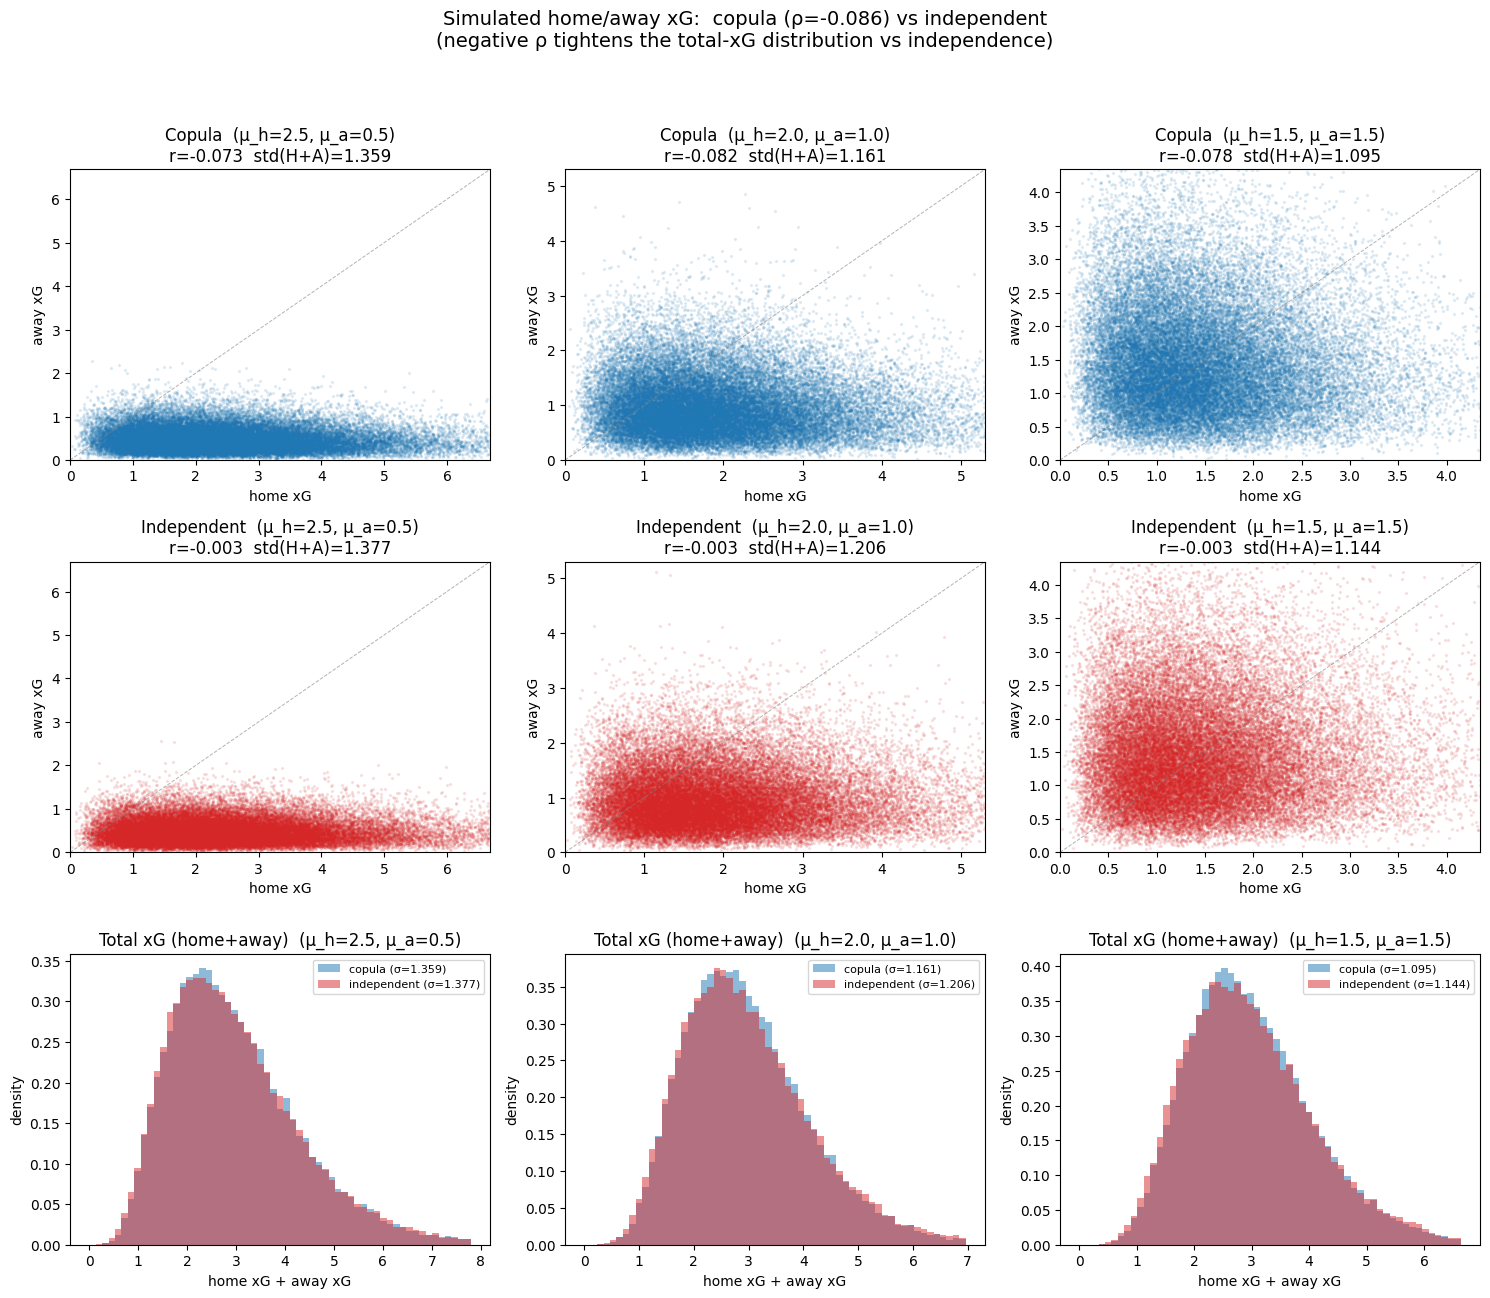

In [195]:
def simulate_case(mu_h, mu_a, phi, rho_cop, n_sim=40000, seed=0):
    rng = np.random.default_rng(seed)
    cov = np.array([[1.0, rho_cop], [rho_cop, 1.0]])
    L = np.linalg.cholesky(cov)
    z = (L @ rng.standard_normal((2, n_sim))).T
    u = norm.cdf(z[:, 0])
    v = norm.cdf(z[:, 1])
    xg_h_cop = gamma_dist.ppf(u, a=phi, scale=mu_h / phi)
    xg_a_cop = gamma_dist.ppf(v, a=phi, scale=mu_a / phi)
    xg_h_ind = gamma_dist.rvs(a=phi, scale=mu_h / phi, size=n_sim, random_state=1)
    xg_a_ind = gamma_dist.rvs(a=phi, scale=mu_a / phi, size=n_sim, random_state=2)

    return xg_h_cop, xg_a_cop, xg_h_ind, xg_a_ind


def run_and_plot(phi, rho_cop, cases, n_sim=40000):
    fig, axes = plt.subplots(3, 3, figsize=(15, 13))
    for col, (mu_h, mu_a) in enumerate(cases):
        xh_c, xa_c, xh_i, xa_i = simulate_case(mu_h, mu_a, phi, rho_cop, n_sim=n_sim, seed=col)

        r_c = np.corrcoef(xh_c, xa_c)[0, 1]
        r_i = np.corrcoef(xh_i, xa_i)[0, 1]
        tot_c = xh_c + xa_c
        tot_i = xh_i + xa_i
        lim = max(np.percentile(np.r_[xh_c, xa_c], 99.5), 0.1)

        ax = axes[0, col]
        ax.scatter(xh_c, xa_c, s=2, alpha=0.10, color="#1f77b4")
        ax.set_title(f"Copula  (μ_h={mu_h}, μ_a={mu_a})\nr={r_c:+.3f}  std(H+A)={tot_c.std():.3f}")
        ax.set_xlabel("home xG"); ax.set_ylabel("away xG")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.plot([0, lim], [0, lim], color="grey", lw=0.7, ls="--", alpha=0.6)
        ax = axes[1, col]
        ax.scatter(xh_i, xa_i, s=2, alpha=0.10, color="#d62728")
        ax.set_title(f"Independent  (μ_h={mu_h}, μ_a={mu_a})\nr={r_i:+.3f}  std(H+A)={tot_i.std():.3f}")
        ax.set_xlabel("home xG"); ax.set_ylabel("away xG")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.plot([0, lim], [0, lim], color="grey", lw=0.7, ls="--", alpha=0.6)
        ax = axes[2, col]
        bins = np.linspace(0, np.percentile(np.r_[tot_c, tot_i], 99.5), 60)
        ax.hist(tot_c, bins=bins, density=True, alpha=0.5, color="#1f77b4", label=f"copula (σ={tot_c.std():.3f})")
        ax.hist(tot_i, bins=bins, density=True, alpha=0.5, color="#d62728", label=f"independent (σ={tot_i.std():.3f})")
        ax.set_title(f"Total xG (home+away)  (μ_h={mu_h}, μ_a={mu_a})")
        ax.set_xlabel("home xG + away xG"); ax.set_ylabel("density")
        ax.legend(fontsize=8)

    fig.suptitle(
        f"Simulated home/away xG:  copula (ρ={rho_cop:+.3f}) vs independent\n"
        f"(negative ρ tightens the total-xG distribution vs independence)",
        fontsize=14, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    #fig.savefig("/home/claude/copula_cases.png", dpi=130, bbox_inches="tight")
    #plt.close(fig)

    print(f"{'case':<16}{'r_copula':>10}{'r_indep':>10}{'std(H+A)_cop':>15}{'std(H+A)_ind':>15}")
    for (mu_h, mu_a) in cases:
        xh_c, xa_c, xh_i, xa_i = simulate_case(mu_h, mu_a, phi, rho_cop, n_sim=n_sim, seed=99)
        r_c = np.corrcoef(xh_c, xa_c)[0, 1]
        r_i = np.corrcoef(xh_i, xa_i)[0, 1]
        s_c = (xh_c + xa_c).std()
        s_i = (xh_i + xa_i).std()
        print(f"({mu_h},{mu_a})".ljust(16) + f"{r_c:>10.3f}{r_i:>10.3f}{s_c:>15.3f}{s_i:>15.3f}")


phi_demo = 3.44
rho_demo = -0.0855
cases = [(2.5, 0.5), (2.0, 1.0), (1.5, 1.5)]
run_and_plot(phi=phi_demo, rho_cop=rho_demo, cases=cases, n_sim=40000)

Visually the difference is extremely small in the joint distributions but it can be seen that the copula model leads to more concentrated ExG values due to the negative correlation. In the total ExG plots it can be seen that the distributions are slightly more concetrated around the mean value with a small decrease in its standard deviations, meaning that the only meaningfull differences are observed in pricing extreme goals' values. For the next part of this project the copula extention will be ignored but in a final model that prices a wide renge of derivative markets it has to be included in cases of low margins.

## Approaching ExG by category:

Beside the match level data understats include all shots' taken data in all matches with additionally players' names, position, ExG value, 
situation, etc. The ExG values can already beeing used as valid while the situation of a shot is also crucial with the categories beeing Openplay,
Set Piece, Direct Free Kick and Penalty. This way of splitting the shots in situation is important since each category can be approached as a 
stand alone component with its own distribution. The approach that will be tried here is to fit a model for each shot categories' ExG and then sum up all the ExG contributions for estimating the total ExG of a game.

The final model beside estimating the ExG of teams' in a match will provide estimations for the number of corners for each team, probability of penanlty for each team and set piece goals. Having these values of ExG can further beeing used for players' metrics estimations in a game since its' situation hides much more information than the total ExG. For example the penalty taker gets the additional ExG of a pen but also a center back gets most of his ExG from corner situation ExG and so on.

### Exploring and cleaning the addition data:

Loading shots data:

In [28]:
df_shots = pd.read_csv("Understat_Data/EPL_all_shots.csv")
df_shots['date'] = pd.to_datetime(df_shots['date'], format="mixed", dayfirst=False)
df_shots.head()

,season,match_id,date,home,away,side,minute,player,player_id,x,y,xG,result,situation,shot_type,last_action
0,2014/2015,4749,2014-08-16,Manchester United,Swansea,away,11,Gylfi Sigurdsson,714,0.762,0.316,0.0206,SavedShot,OpenPlay,RightFoot,Pass
1,2014/2015,4749,2014-08-16,Manchester United,Swansea,home,12,Wayne Rooney,629,0.728,0.501,0.0187,SavedShot,OpenPlay,RightFoot,Pass
2,2014/2015,4749,2014-08-16,Manchester United,Swansea,home,16,Wayne Rooney,629,0.789,0.336,0.0156,BlockedShot,OpenPlay,RightFoot,TakeOn
3,2014/2015,4749,2014-08-16,Manchester United,Swansea,home,25,Juan Mata,554,0.914,0.188,0.0649,SavedShot,DirectFreekick,LeftFoot,Standard
4,2014/2015,4749,2014-08-16,Manchester United,Swansea,home,26,Wayne Rooney,629,0.920,0.482,0.0578,SavedShot,OpenPlay,Head,Aerial


Transforming the shots' data to total ExG for each situation for home and away in each given match:

In [29]:
df_shots_data = df_shots.copy()
df_shots_data["xG"] = pd.to_numeric(df_shots_data["xG"], errors="coerce")
df_shots_data["side"] = df_shots_data["side"].astype(str).str.strip().str.lower()
df_shots_data["situation"] = df_shots_data["situation"].astype(str).str.strip()
df_shots_data = df_shots_data.dropna(subset=["match_id", "date", "home", "away", "side", "situation", "xG"]).copy()


xg_by_situation_long = (df_shots_data.groupby(["match_id", "date", "home", "away", "side", "situation"],
        as_index=False)["xG"].sum().rename(columns={"xG": "xG_sum"}))

xg_by_situation_match = (xg_by_situation_long.pivot_table(
        index=["match_id", "date", "home", "away"],
        columns=["side", "situation"],
        values="xG_sum",fill_value=0).reset_index())

new_cols = []
for col in xg_by_situation_match.columns:

    if isinstance(col, tuple):
        col_clean = [str(c) for c in col if str(c) != ""]
        
        if len(col_clean) == 1:
            new_cols.append(col_clean[0])
        elif len(col_clean) == 2:
            side, situation = col_clean
            new_cols.append(f"{side}_{situation}_xG")
        else:
            new_cols.append("_".join(col_clean))
    
    else:
        new_cols.append(col)

xg_by_situation_match.columns = new_cols

home_xg_cols = [col for col in xg_by_situation_match.columns
    if col.startswith("home_") and col.endswith("_xG")]

away_xg_cols = [col for col in xg_by_situation_match.columns
    if col.startswith("away_") and col.endswith("_xG")]

xg_by_situation_match["home_total_xG"] = xg_by_situation_match[home_xg_cols].sum(axis=1)
xg_by_situation_match["away_total_xG"] = xg_by_situation_match[away_xg_cols].sum(axis=1)

print("Duplicate columns:", xg_by_situation_match.columns[xg_by_situation_match.columns.duplicated()].tolist())
xg_by_situation_match['date'] = pd.to_datetime(xg_by_situation_match['date'], format="mixed", dayfirst=False)
xg_by_situation_match.head()

Duplicate columns: []


,match_id,date,home,away,away_DirectFreekick_xG,away_FromCorner_xG,away_OpenPlay_xG,away_Penalty_xG,away_SetPiece_xG,home_DirectFreekick_xG,home_FromCorner_xG,home_OpenPlay_xG,home_Penalty_xG,home_SetPiece_xG,home_total_xG,away_total_xG
0,81,2015-08-08,Manchester United,Tottenham,0.0000,0.0744,0.4670,0.0,0.1344,0.1474,0.0000,0.4157,0.0000,0.0643,0.6274,0.6758
1,82,2015-08-08,Bournemouth,Aston Villa,0.0974,0.3741,0.3149,0.0,0.0000,0.0000,0.0000,0.7369,0.0000,0.1392,0.8761,0.7864
2,83,2015-08-08,Everton,Watford,0.0000,0.0000,0.5585,0.0,0.0000,0.0000,0.3107,0.2935,0.0000,0.0000,0.6042,0.5585
3,84,2015-08-08,Leicester,Sunderland,0.0000,0.1804,1.2805,0.0,0.0000,0.0000,0.0683,1.7053,0.7612,0.0333,2.5681,1.4609
4,85,2015-08-08,Norwich,Crystal Palace,0.0000,0.3215,1.7882,0.0,0.0000,0.0447,0.0469,0.9882,0.0000,0.0507,1.1305,2.1097


As it can be seen the Openplay ExG dominates by far the ExG creation with around 71% of the total ExG with corners' ExG following with 14.5%. The penalty, set piece and direct free kicks contributes a very small amount of ExG around 14.5%.

In [30]:
home_cols = [
    "home_DirectFreekick_xG",
    "home_FromCorner_xG",
    "home_OpenPlay_xG",
    "home_Penalty_xG",
    "home_SetPiece_xG"]

home_xg_summary = pd.DataFrame({"mean_xG": xg_by_situation_match[home_cols].mean(),
    "total_xG": xg_by_situation_match[home_cols].sum()})

home_xg_summary["percentage"] = (100 * home_xg_summary["total_xG"] / home_xg_summary["total_xG"].sum())
home_xg_summary = home_xg_summary.reset_index().rename(columns={"index": "category"})
home_xg_summary["category"] = (home_xg_summary["category"].str.replace("home_", "", regex=False).str.replace("_xG", "", regex=False))
home_xg_summary = home_xg_summary.sort_values("percentage",ascending=False)

home_xg_summary

,category,mean_xG,total_xG,percentage
2,OpenPlay,1.141708,5206.188512,71.128868
1,FromCorner,0.221679,1010.854383,13.810665
3,Penalty,0.111341,507.716886,6.936615
4,SetPiece,0.099336,452.973644,6.188693
0,DirectFreekick,0.031062,141.641501,1.935158


Before moving forward with the model reation the correlation between each ExG component has to be checked since if there is high correlation there is no point on categorizing the ExG. As it can be shown below the correlation is small for almost all components except the openplay and cornered ExG, which have to be considered when the corners' model will be fitted.

In [31]:
xg_by_situation_match[['home_DirectFreekick_xG', 'home_FromCorner_xG',
       'home_OpenPlay_xG', 'home_Penalty_xG', 'home_SetPiece_xG']].corr()

,home_DirectFreekick_xG,home_FromCorner_xG,home_OpenPlay_xG,home_Penalty_xG,home_SetPiece_xG
home_DirectFreekick_xG,1.000000,0.020968,0.012091,-0.002813,0.024578
home_FromCorner_xG,0.020968,1.000000,0.091997,0.010224,0.022949
home_OpenPlay_xG,0.012091,0.091997,1.000000,0.029212,-0.003632
home_Penalty_xG,-0.002813,0.010224,0.029212,1.000000,0.007563
home_SetPiece_xG,0.024578,0.022949,-0.003632,0.007563,1.000000


Unffortunatelly in the scraped data the number of corners and cards at match level are missing and the referees' names. For this reason the 
data of the same period are extracted from https://www.football-data.co.uk/ having the needed data:

In [32]:
df_UK = pd.DataFrame()
for i in range(0,12):
    url = "https://www.football-data.co.uk/mmz4281/" + str(2526-101*i)+"/E0.csv"    
    prem_slice = pd.read_csv((url),usecols = ['Date','HomeTeam','AwayTeam','FTHG','FTAG','HF','AF','HC','AC','HY','AY','HR','AR','Referee',
    'B365H','B365D','B365A'])
    df_UK = pd.concat([df_UK,prem_slice])

df_UK.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,Referee,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A
0,15/08/2025,Liverpool,Bournemouth,4.0,2.0,A Taylor,7.0,10.0,6.0,7.0,1.0,2.0,0.0,0.0,1.30,6.00,8.50
1,16/08/2025,Aston Villa,Newcastle,0.0,0.0,C Pawson,13.0,11.0,3.0,6.0,1.0,1.0,1.0,0.0,2.25,3.50,2.90
2,16/08/2025,Brighton,Fulham,1.0,1.0,S Barrott,16.0,15.0,4.0,3.0,3.0,3.0,0.0,0.0,1.91,3.60,4.00
3,16/08/2025,Sunderland,West Ham,3.0,0.0,R Jones,8.0,10.0,5.0,7.0,0.0,1.0,0.0,0.0,3.25,3.40,2.25
4,16/08/2025,Tottenham,Burnley,3.0,0.0,M Oliver,14.0,8.0,6.0,5.0,0.0,0.0,0.0,0.0,1.38,4.75,8.50


In [33]:
name_map = {
    "Man United": "Manchester United",
    "Man Utd": "Manchester United",
    "Nott'm Forest": "Nottingham Forest",
    "West Brom": "West Bromwich Albion",
    "Wolves": "Wolverhampton Wanderers",
    "Man City": "Manchester City",
    "Newcastle": "Newcastle United",
    "QPR": "Queens Park Rangers"
}

cols = ["HomeTeam", "AwayTeam"]

df_UK[cols] = df_UK[cols].replace(name_map)
df_UK.rename(columns={"HomeTeam":"home","AwayTeam":"away","Date":"date"},inplace=True)
df_UK.head()

,date,home,away,FTHG,FTAG,Referee,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A
0,15/08/2025,Liverpool,Bournemouth,4.0,2.0,A Taylor,7.0,10.0,6.0,7.0,1.0,2.0,0.0,0.0,1.30,6.00,8.50
1,16/08/2025,Aston Villa,Newcastle United,0.0,0.0,C Pawson,13.0,11.0,3.0,6.0,1.0,1.0,1.0,0.0,2.25,3.50,2.90
2,16/08/2025,Brighton,Fulham,1.0,1.0,S Barrott,16.0,15.0,4.0,3.0,3.0,3.0,0.0,0.0,1.91,3.60,4.00
3,16/08/2025,Sunderland,West Ham,3.0,0.0,R Jones,8.0,10.0,5.0,7.0,0.0,1.0,0.0,0.0,3.25,3.40,2.25
4,16/08/2025,Tottenham,Burnley,3.0,0.0,M Oliver,14.0,8.0,6.0,5.0,0.0,0.0,0.0,0.0,1.38,4.75,8.50


In [34]:
d1 = pd.to_datetime(df_UK["date"], format="%d/%m/%Y", errors="coerce")
d2 = pd.to_datetime(df_UK["date"], format="%d/%m/%y", errors="coerce")
df_UK["date"] = d1.fillna(d2)
df_UK = df_UK.dropna()

### Open play xG:

As it was shown in the total ExG model the Gamma distribution showed the best agreement with the data so the openplay ExG should 
also have great agreement with the Gamma distribution given that it's the dominant component by far in total ExG. An issue that arrises is 
that openplay ExG can be zero and thus the Gamma distributions model would fail since the probability at zero is imposible to be estimated 
leading to infinity of the likelihood. For this reason a very small amaount of ExG is added to all openplay data:

In [35]:
print("Home ExG openpley zeros:",sum(xg_by_situation_match["home_OpenPlay_xG"]==0))
print("Away ExG openpley zeros:",sum(xg_by_situation_match["away_OpenPlay_xG"]==0))

Home ExG openpley zeros: 7
Away ExG openpley zeros: 17


In [36]:
xg_by_situation_match["home_OpenPlay_xG"] += 0.01
xg_by_situation_match["away_OpenPlay_xG"] += 0.01

As it cen be seen the Gamma distributions' model works as expected with RMSE being very close for home and away teams with a 
small difference due to the home teams scoring slightly more:

In [37]:
teams    = sorted(set(xg_by_situation_match["home"]) | set(xg_by_situation_match["away"]))
team_idx = {t: i for i, t in enumerate(teams)}
n_teams  = len(teams)

home_id  = xg_by_situation_match["home"].map(team_idx).values
away_id  = xg_by_situation_match["away"].map(team_idx).values
home_xg  = xg_by_situation_match["home_OpenPlay_xG"].values.astype(float)
away_xg  = xg_by_situation_match["away_OpenPlay_xG"].values.astype(float)

print("Number of teams:",n_teams)
print("Number of matches:",len(df))


def unpack(params):
    intercept = params[0]
    home_adv  = params[1]
    attack    = params[2 : 2 + n_teams]
    defense   = params[2 + n_teams : 2 + 2 * n_teams]
    log_phi   = params[-1]
    phi       = np.exp(log_phi)  # ensure positive
    return intercept, home_adv, attack, defense, phi

def compute_mu(params):
    intercept, home_adv, attack, defense, phi = unpack(params)

    attack  = attack  - attack.mean()
    defense = defense - defense.mean()
    mu_home = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
    mu_away = np.exp(intercept + attack[away_id] - defense[home_id])
    return mu_home, mu_away, phi

def neg_log_likelihood(params):
    mu_home, mu_away, phi = compute_mu(params)

    def gamma_logpdf(y, mu, phi):
        return ((phi - 1) * np.log(y) - y * (phi / mu)+ phi * np.log(phi / mu) - gammaln(phi))

    ll = (gamma_logpdf(home_xg, mu_home, phi).sum() + gamma_logpdf(away_xg, mu_away, phi).sum())
    return -ll

n_params = 2 + 2 * n_teams + 1
init = np.zeros(n_params)
init[0]  = np.log(np.mean(home_xg))
init[1]  = 0.1                    
init[-1] = np.log(5.0) 

result = minimize(neg_log_likelihood, x0=init, method="L-BFGS-B",
                  options={"maxiter": 10000, "ftol": 1e-12})

intercept, home_adv, attack, defense, phi = unpack(result.x)
attack  = attack  - attack.mean()
defense = defense - defense.mean()
mu_home_fit, mu_away_fit, _ = compute_mu(result.x)

residuals_home = home_xg - mu_home_fit
residuals_away = away_xg - mu_away_fit

n_obs = 2 * len(df)
k = n_params

AIC_GM = 2*k - 2*(-result.fun)
BIC_GM = k*np.log(n_obs) - 2*(-result.fun)
RMSE_H_GM = np.sqrt((residuals_home**2).mean())
RMSE_A_GM = np.sqrt((residuals_away**2).mean())

print("── Model Parameters ──────────────────────────")
print("Intercept (Mean Log Exg):", round(home_adv,3))
print("Home Adv:", round(home_adv,3))
print("Phi (shape):", round(phi,3))
print("RMSE Home:", round(RMSE_H_GM,3))
print("RMSE Away:", round(RMSE_A_GM,3))

Number of teams: 35
Number of matches: 4478
── Model Parameters ──────────────────────────
Intercept (Mean Log Exg): 0.208
Home Adv: 0.208
Phi (shape): 2.166
RMSE Home: 0.7
RMSE Away: 0.643


An important extension to all the ExG components is the time decay effects in form of weights for estimating the importance 
of the information added based on how far in the past they are:

In [38]:
xg_by_situation_match.head()

,match_id,date,home,away,away_DirectFreekick_xG,away_FromCorner_xG,away_OpenPlay_xG,away_Penalty_xG,away_SetPiece_xG,home_DirectFreekick_xG,home_FromCorner_xG,home_OpenPlay_xG,home_Penalty_xG,home_SetPiece_xG,home_total_xG,away_total_xG
0,81,2015-08-08,Manchester United,Tottenham,0.0000,0.0744,0.4770,0.0,0.1344,0.1474,0.0000,0.4257,0.0000,0.0643,0.6274,0.6758
1,82,2015-08-08,Bournemouth,Aston Villa,0.0974,0.3741,0.3249,0.0,0.0000,0.0000,0.0000,0.7469,0.0000,0.1392,0.8761,0.7864
2,83,2015-08-08,Everton,Watford,0.0000,0.0000,0.5685,0.0,0.0000,0.0000,0.3107,0.3035,0.0000,0.0000,0.6042,0.5585
3,84,2015-08-08,Leicester,Sunderland,0.0000,0.1804,1.2905,0.0,0.0000,0.0000,0.0683,1.7153,0.7612,0.0333,2.5681,1.4609
4,85,2015-08-08,Norwich,Crystal Palace,0.0000,0.3215,1.7982,0.0,0.0000,0.0447,0.0469,0.9982,0.0000,0.0507,1.1305,2.1097


In [39]:
def evaluate_half_life_walkforward(df_matches,
    grid=np.array([60, 120, 180, 270, 365, 540, 730, 1095, 1460]),
    val_frac=0.20,retrain_every_days=7,
    home_col="home", away_col="away",
    home_xg_col="home_OpenPlay_xG", away_xg_col="away_OpenPlay_xG",
    date_col="date"):

    d = df_matches.copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.dropna(subset=[home_xg_col, away_xg_col])
    d = d[(d[home_xg_col] >= 0) & (d[away_xg_col] >= 0)]
    d = d.sort_values(date_col).reset_index(drop=True)

    teams    = sorted(set(d[home_col]) | set(d[away_col]))
    team_idx = {t: i for i, t in enumerate(teams)}
    n_teams  = len(teams)
    home_id  = d[home_col].map(team_idx).values
    away_id  = d[away_col].map(team_idx).values
    home_xg  = d[home_xg_col].values.astype(float) + 0.01     # avoid log(0)
    away_xg  = d[away_xg_col].values.astype(float) + 0.01
    dates    = d[date_col]

    def compute_mu(params):
        intercept = params[0]
        home_adv  = params[1]
        attack    = params[2 : 2 + n_teams]
        defense   = params[2 + n_teams : 2 + 2 * n_teams]
        phi       = np.exp(params[-1])
        attack  = attack  - attack.mean()
        defense = defense - defense.mean()
        mu_h = np.exp(intercept + home_adv + attack[home_id] - defense[away_id])
        mu_a = np.exp(intercept +            attack[away_id] - defense[home_id])
        return mu_h, mu_a, phi

    def gamma_logpdf(y, mu, phi):
        return ((phi - 1) * np.log(y) - y * (phi / mu)
                + phi * np.log(phi / mu) - gammaln(phi))

    def make_nll(weights):
        def nll(params):
            mu_h, mu_a, phi = compute_mu(params)
            ll = ((weights * gamma_logpdf(home_xg, mu_h, phi)).sum()
                + (weights * gamma_logpdf(away_xg, mu_a, phi)).sum())
            return -ll
        return nll

    n_params = 2 + 2 * n_teams + 1
    init = np.zeros(n_params)
    init[0]  = np.log(np.mean(home_xg))
    init[1]  = 0.1
    init[-1] = np.log(5.0)

    cutoff_idx     = int(len(d) * (1 - val_frac))
    val_start_date = dates.iloc[cutoff_idx]
    val_dates      = dates[dates >= val_start_date]
    val_indices    = val_dates.index.values
    week_offsets   = ((val_dates - val_start_date).dt.days // retrain_every_days).astype(int).values
    unique_weeks   = np.unique(week_offsets)

    week_ages          = {}
    week_train_masks   = {}
    week_predict_masks = {}

    for wk in unique_weeks:
        wk_predict_mask = np.zeros(len(d), bool)
        wk_predict_mask[val_indices[week_offsets == wk]] = True
        week_predict_masks[wk] = wk_predict_mask
        earliest = dates[wk_predict_mask].min()
        week_train_masks[wk] = (dates < earliest).values
        week_ages[wk]        = (earliest - dates).dt.days.values.astype(float)

    scores        = {int(h): 0.0 for h in grid}
    prev_x        = {int(h): init.copy() for h in grid}    # warm start per candidate
    n_blocks_used = 0
    n_scored      = 0

    for wk in unique_weeks:
        train_mask = week_train_masks[wk]
        age        = week_ages[wk]
        predict_mask = week_predict_masks[wk]

        if train_mask.sum() < 30:                       
            continue

        for h in grid:
            h_int = int(h)
            xi = np.log(2) / h                           
            w  = train_mask * (0.5 ** (age / h))

            try:
                res = minimize(
                    make_nll(w),
                    x0=prev_x[h_int],                 
                    method="L-BFGS-B",
                    options={"maxiter": 2000, "ftol": 1e-8},
                )
                prev_x[h_int] = res.x
            except Exception:
                continue

            mu_h, mu_a, phi = compute_mu(res.x)
            ll_block = (gamma_logpdf(home_xg[predict_mask], mu_h[predict_mask], phi).sum()
              + gamma_logpdf(away_xg[predict_mask], mu_a[predict_mask], phi).sum())
            if np.isfinite(ll_block):
                scores[h_int] += float(ll_block)

        n_blocks_used += 1
        n_scored += int(predict_mask.sum())

    print(f"\nBlocks used: {n_blocks_used}, Matches scored: {n_scored}\n")
    for h in grid:
        print(f"Half life: {int(h):>5d}  Likelihood: {scores[int(h)]:>10.2f}")

    best_h  = max(scores, key=scores.get)
    best_ll = scores[best_h]
    print("-" * 50)
    print(f"Optimal half life days' parameter: {best_h}")
    print(f"Best walk-forward LL:              {best_ll:.2f}")

    return best_h, scores

best_h_open_play, all_scores = evaluate_half_life_walkforward(xg_by_situation_match,
    grid=np.array([10,30,60, 120, 180, 270, 365, 540, 730, 1095, 1460]),
    val_frac=0.20,retrain_every_days=7)


Blocks used: 87, Matches scored: 912

Half life:    10  Likelihood:  -34526.35
Half life:    30  Likelihood:   -2191.24
Half life:    60  Likelihood:   -1904.14
Half life:   120  Likelihood:   -1794.06
Half life:   180  Likelihood:   -1776.76
Half life:   270  Likelihood:   -1776.17
Half life:   365  Likelihood:   -1782.38
Half life:   540  Likelihood:   -1796.87
Half life:   730  Likelihood:   -1811.62
Half life:  1095  Likelihood:   -1832.84
Half life:  1460  Likelihood:   -1846.69
--------------------------------------------------
Optimal half life days' parameter: 270
Best walk-forward LL:              -1776.17


The optimal value of half-life for time decay effect for open play ExG is 270 or 0.0026:

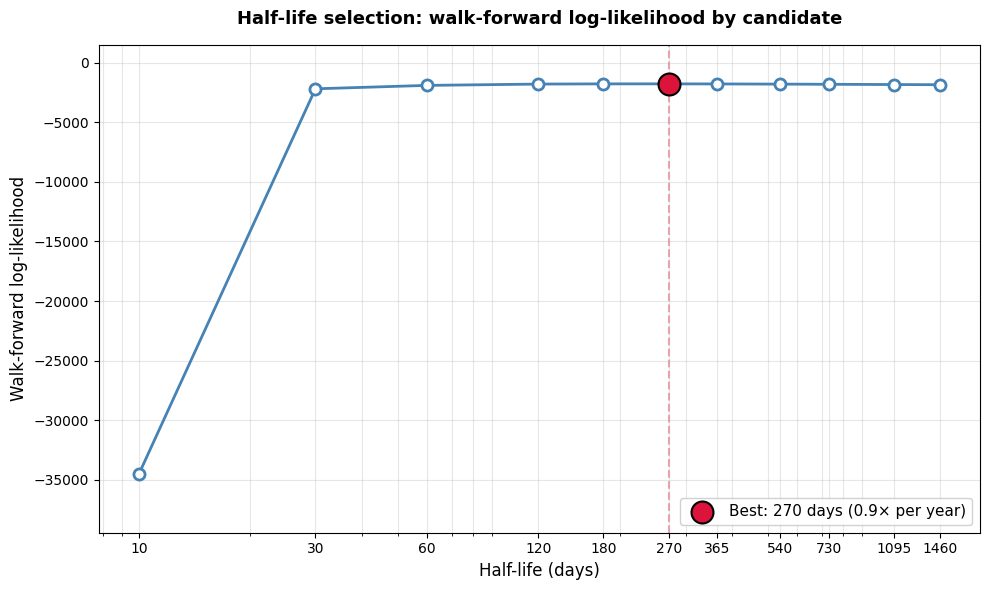

In [40]:
half_lives = list(all_scores.keys())
log_liks   = list(all_scores.values())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(half_lives, log_liks, 'o-', color="steelblue", linewidth=2,markersize=8, markerfacecolor="white", markeredgewidth=2, zorder=3)
best_ll = all_scores[best_h_open_play]
ax.scatter([best_h_open_play], [best_ll], s=250, color="crimson",zorder=5, edgecolor="black", linewidth=1.5,
           label=f"Best: {best_h_open_play} days ({np.log(2)/best_h_open_play*365:.1f}× per year)")

ax.axvline(best_h_open_play, color="crimson", linestyle="--", alpha=0.4, zorder=1)

ax.set_xscale("log")
ax.set_xlabel("Half-life (days)", fontsize=12)
ax.set_ylabel("Walk-forward log-likelihood", fontsize=12)
ax.set_title("Half-life selection: walk-forward log-likelihood by candidate",
             fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, which="both")
ax.set_xticks(half_lives)
ax.set_xticklabels([str(h) for h in half_lives], rotation=0)
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)

y_range = max(log_liks) - min(log_liks)
ax.set_ylim(min(log_liks) - 0.15 * y_range, max(log_liks) + 0.1 * y_range)

plt.tight_layout()

### Penalties' Probability Model:

The most important part of the ExG that can be misleading is the ExG coming from penalties due to their occurrence rate and the 
extremely high ExG that create. A team might had a terrible game with low ExG created but had a lucky penalty due to handball and added 0.76 ExG in their offensive performance. It is crucial to have penalty probability for each game while we handle all penalties as same with constant ExG value of 0.7612 since at top level the skill difference is negligible.

Preparing the penalties data:

In [41]:
PEN_XG = 0.7612

df_pens = df_shots[df_shots["situation"] == "Penalty"]
pen_counts = (df_pens.groupby(["match_id", "side"]).size().reset_index(name="pens"))
pen_wide = (pen_counts.pivot(index="match_id", columns="side", values="pens")
            .reset_index().rename(columns={"home": "home_pens", "away": "away_pens"}))
for c in ["home_pens", "away_pens"]:
    if c not in pen_wide.columns:
        pen_wide[c] = 0
pen_wide[["home_pens", "away_pens"]] = pen_wide[["home_pens", "away_pens"]].fillna(0)

m = xg_by_situation_match[['match_id', 'date', 'home', 'away', 'away_OpenPlay_xG','home_OpenPlay_xG']].copy()
m["date"] = pd.to_datetime(m["date"])
m = m.dropna(subset=["match_id", "date", "home", "away"]).reset_index(drop=True)

m = m.merge(pen_wide,on="match_id", how="left")
m[["home_pens", "away_pens"]] = m[["home_pens", "away_pens"]].fillna(0)

m["home_xg"] = m["home_OpenPlay_xG"] - m["away_OpenPlay_xG"]
m["away_xg"] = m["away_OpenPlay_xG"] - m["home_OpenPlay_xG"]
m["home_xg_tot"] = m["home_OpenPlay_xG"] + m["away_OpenPlay_xG"]
m["away_xg_tot"] = m["away_OpenPlay_xG"] + m["home_OpenPlay_xG"]

home_view = m.rename(columns={"home":"team", "away":"opponent","home_OpenPlay_xG":"DxG","home_pens":"penalties","home_xg_tot":"tot_xg"})[[
    "match_id","date","team","opponent","DxG","penalties","tot_xg"]].copy()
home_view["IsHome"] = True

away_view = m.rename(columns={"away":"team", "home":"opponent","away_OpenPlay_xG":"DxG","away_pens":"penalties","away_xg_tot":"tot_xg"})[[
    "match_id","date","team","opponent","DxG","penalties","tot_xg"]].copy()
away_view["IsHome"] = False

df_penalty_data = pd.concat([home_view, away_view], ignore_index=True)
df_penalty_data = df_penalty_data.dropna(subset=["match_id", "date", "team", "opponent", "DxG"]).reset_index(drop=True)
df_penalty_data = df_penalty_data.sort_values("date").reset_index(drop=True)
df_penalty_data.head()

,match_id,date,team,opponent,DxG,penalties,tot_xg,IsHome
0,4749,2014-08-16,Manchester United,Swansea,0.3875,0.0,0.6755,True
1,4749,2014-08-16,Swansea,Manchester United,0.2880,0.0,0.6755,False
2,4750,2014-08-16,Everton,Leicester,0.5292,0.0,1.2937,False
3,4751,2014-08-16,Hull,Queens Park Rangers,0.8447,0.0,1.6048,False
4,4752,2014-08-16,Aston Villa,Stoke,0.7050,0.0,0.9919,False


The mean probability of a penalty and its variance are equal so choosing the poisson independent distributions for 
modeling the penalties probability seems reasonable. The parameters of the model are a paramater for attack and one for defence for all teams
and a home advantage just like the simple poisson model based only on match results plus a parameter for each referee. It is reasonable to assume that different referees might judge differently a few penalty cases althought this effect is expected to get smaller and smaller with the intoduction of VAR.

In [42]:
df_model = df_penalty_data.copy()
target_col = "penalties" if "penalties" in df_model.columns else "count_value"

df_model[target_col] = pd.to_numeric(df_model[target_col], errors="coerce")
df_model["IsHome"] = (df_model["IsHome"].astype(str).str.strip().str.lower().map({"true": 1, "false": 0, "1": 1, "0": 0}))
df_model = df_model[[target_col, "match_id", "team", "opponent","IsHome", "date","DxG","tot_xg"]].dropna().copy()
df_model[target_col] = df_model[target_col].astype(int)
df_model["IsHome"] = df_model["IsHome"].astype(int)
df_model["DxG"] = df_model["DxG"].astype(float)
df_model["tot_xg"] = df_model["tot_xg"].astype(float)
df_model["team"] = df_model["team"].astype("category")
df_model["opponent"] = df_model["opponent"].astype("category")

print(f"Observations: {len(df_model)}")
print(f"Teams: {df_model['team'].nunique()}")
print(f"Mean {target_col}: {df_model[target_col].mean():.4f}")
print(f"Variance {target_col}: {df_model[target_col].var():.4f}")
print(f"IsHome distribution:")
print(df_model["IsHome"].value_counts())

Observations: 9120
Teams: 35
Mean penalties: 0.1276
Variance penalties: 0.1274
IsHome distribution:
IsHome
1    4560
0    4560
Name: count, dtype: int64


After applying and comparing all the combinations of models with features of home advantage, team coefficient features, the openplay ExG difference and the total openplay ExG the optimal poisson model was found as:

$$ \mu_i = exp(\beta_0 + \beta_1 \cdot \operatorname{IsHome}_i + \beta_2 \cdot \Delta xG_i + \beta_3 \cdot \operatorname{xG_{total,i}}) $$

The explanatory variables are:

* $\operatorname{IsHome_i}$: indicator equal to (1) when the team is playing at home and (0) when playing away.
* $\Delta xG_i$: difference of expected goals between home and away team.
* $\operatorname{xG_{total,i}}$: total expected goals in the match.

The only free parameter is the home advantage since the open-play ExG difference and total are predicted already by the gamma distributions' model of open play ExG. So there is not a large surpice that the optimal half life of this poisson model is infinite and thus it has not any time effects, meaning that the home advantage and average of penalties have not been changed through the years in Premier League.

In [43]:
formula = f"{target_col} ~ IsHome + DxG + tot_xg"
poisson_model = smf.glm(formula=formula,data=df_model,family=sm.families.Poisson()).fit()

log_lik  = poisson_model.llf
n_params = int(poisson_model.df_model) + 1
n_obs    = int(poisson_model.nobs)
aic      = 2 * n_params - 2 * log_lik
bic      = n_params * np.log(n_obs) - 2 * log_lik

print("\n── Model Fit ─────────────────────────────")
print(f"Observations:  {n_obs}")
print(f"Parameters:    {n_params}")
print(f"LogLik:        {log_lik:.2f}")
print(f"AIC:           {aic:.2f}")
print(f"BIC:           {bic:.2f}")


── Model Fit ─────────────────────────────
Observations:  9120
Parameters:    4
LogLik:        -3575.17
AIC:           7158.34
BIC:           7186.81


In [44]:
conf_int = poisson_model.conf_int()

coef_summary = pd.DataFrame({
    "feature": poisson_model.params.index,
    "coefficient": poisson_model.params.values,
    "std_error": poisson_model.bse.values,
    "p_value": poisson_model.pvalues.values,
    "ci_low": conf_int[0].values,
    "ci_high": conf_int[1].values})

coef_summary["IRR"] = np.exp(coef_summary["coefficient"])
coef_summary["IRR_ci_low"] = np.exp(coef_summary["ci_low"])
coef_summary["IRR_ci_high"] = np.exp(coef_summary["ci_high"])
coef_summary["percentage_change"] = (100 * (coef_summary["IRR"] - 1))

print("\n── Poisson coefficient summary ─────────────────────")
display(coef_summary[["feature","coefficient","std_error","p_value","IRR","IRR_ci_low","IRR_ci_high","percentage_change"]].round(4))


── Poisson coefficient summary ─────────────────────


,feature,coefficient,std_error,p_value,IRR,IRR_ci_low,IRR_ci_high,percentage_change
0,Intercept,-1.9816,0.0794,0.0000,0.1379,0.1180,0.1611,-86.2148
1,IsHome,0.2300,0.0602,0.0001,1.2585,1.1185,1.4161,25.8543
2,DxG,0.3221,0.0533,0.0000,1.3800,1.2432,1.5319,38.0017
3,tot_xg,-0.2679,0.0458,0.0000,0.7649,0.6993,0.8368,-23.5051


The results of the maximum likelihood estimation causes some distrust to the model since it isn't logical for information from 4 seasons in the past to have weight of 0,5 with the likelihood to be potentially at its maximum even further in the past. A potential reason for this result is due to the large amount of parameters and the little number of penalties observed making the eefective size amount rather large moving the half life parameter too much to the past. 

### Corners' Model:

The target here is to create a similar model to penalties for estimating the ExG created by corner situations. The difference 
between corners and penalties is that they occure much more often while they have much lower ExG values per corner. The approach followed here
 is to model the number of corner for home and away teams in a much and then consider the same ExG in all corner since the differences are extremely small.

Merging the corner data with the understat dataset:

In [45]:
df_UK2 = df_UK.copy()
df2 = df.copy()

df_UK2["date"] = pd.to_datetime(df_UK2["date"], dayfirst=True, errors="coerce")
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")

name_map = {"Man United": "Manchester United",
    "Man Utd": "Manchester United",
    "Nott'm Forest": "Nottingham Forest",
    "West Brom": "West Bromwich Albion",
    "Wolves": "Wolverhampton Wanderers",
    "Man City": "Manchester City",
    "Newcastle": "Newcastle United"}

df_UK2[["home", "away"]] = df_UK2[["home", "away"]].replace(name_map)
df2[["home", "away"]] = df2[["home", "away"]].replace(name_map)

df_corners = pd.merge(df2,df_UK2,on=["home", "away", "date"],how="left",suffixes=("", "_corners"))
df_corners.head()

,season,match_id,date,home,away,home_goals,away_goals,home_xg,away_xg,FTHG,...,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A
0,2014/2015,4749,2014-08-16,Manchester United,Swansea,1,2,1.168,0.280,1.0,...,20.0,4.0,0.0,2.0,4.0,0.0,0.0,1.36,5.0,11.0
1,2014/2015,4750,2014-08-16,Leicester,Everton,2,2,1.280,0.615,2.0,...,10.0,3.0,6.0,1.0,1.0,0.0,0.0,3.20,3.4,2.4
2,2014/2015,4751,2014-08-16,Queens Park Rangers,Hull,0,1,1.903,1.120,0.0,...,10.0,8.0,9.0,1.0,2.0,0.0,0.0,2.50,3.3,3.1
3,2014/2015,4752,2014-08-16,Stoke,Aston Villa,0,1,0.425,0.912,0.0,...,9.0,2.0,8.0,0.0,3.0,0.0,0.0,1.95,3.5,4.5
4,2014/2015,4753,2014-08-16,West Bromwich Albion,Sunderland,2,2,1.685,0.994,2.0,...,9.0,6.0,3.0,3.0,1.0,0.0,0.0,2.25,3.4,3.5


The corners' distribution seems close to a poisson distribution while the average xG for away and home per corner is extremely close so it 'll be asummed to be the same for both teams and as a constant with value around 0.04 xG per corner. Obviously some teams can be better than other in 
corner situations but the difference is small and it will be ignored in this project.

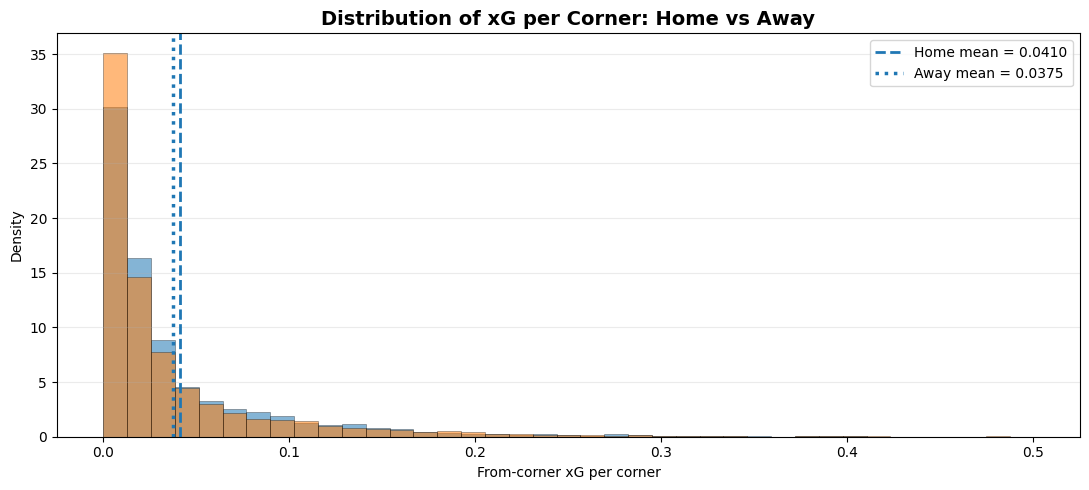

In [46]:
corner_ratio_data = xg_by_situation_match[["match_id","home_FromCorner_xG","away_FromCorner_xG"]].copy()
corner_counts = df_corners[["match_id","HC","AC"]].drop_duplicates("match_id").copy()

corner_ratio_data = corner_ratio_data.merge(corner_counts,on="match_id",how="left")
corner_ratio_data["home_xG_per_corner"] = np.where(corner_ratio_data["HC"] > 0,
                                                   corner_ratio_data["home_FromCorner_xG"] / corner_ratio_data["HC"],np.nan)
corner_ratio_data["away_xG_per_corner"] = np.where(corner_ratio_data["AC"] > 0,
    corner_ratio_data["away_FromCorner_xG"] / corner_ratio_data["AC"],np.nan)

home_ratio = corner_ratio_data["home_xG_per_corner"].replace([np.inf, -np.inf], np.nan).dropna()
away_ratio = corner_ratio_data["away_xG_per_corner"].replace([np.inf, -np.inf], np.nan).dropna()

home_ratio_plot = home_ratio[(home_ratio >= 0) & (home_ratio <= 1)]
away_ratio_plot = away_ratio[(away_ratio >= 0) & (away_ratio <= 1)]

home_mean = home_ratio.mean()
away_mean = away_ratio.mean()
mean_corner_xG = (home_mean + away_mean)/2

bins = np.linspace(0, 0.5, 40)

plt.figure(figsize=(11, 5))

plt.hist(home_ratio_plot,bins=bins,alpha=0.55,density=True,edgecolor="black",linewidth=0.4)
plt.hist(away_ratio_plot,bins=bins,alpha=0.55,density=True,edgecolor="black",linewidth=0.4)

plt.axvline(home_mean,linestyle="--",linewidth=2,label=f"Home mean = {home_mean:.4f}")
plt.axvline(away_mean,linestyle=":",linewidth=2.5,label=f"Away mean = {away_mean:.4f}")

plt.xlabel("From-corner xG per corner")
plt.ylabel("Density")
plt.title("Distribution of xG per Corner: Home vs Away", fontsize=14, fontweight="bold")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

Here the corners dataframe needs an additional preperation step. The mean corner per team is around $5 \pm 3$ which shows already that 
corners are noisy data.

In [47]:
idf_match = df_corners.copy()
cols_needed = ["match_id", "date", "home", "away", "HC", "AC"]
df_match = idf_match[cols_needed].copy()
df_match = df_match.dropna().copy()
df_match["home_xg"] = xg_by_situation_match['home_OpenPlay_xG']
df_match["away_xg"] = xg_by_situation_match['away_OpenPlay_xG']

home_rows = pd.DataFrame({
    "match_id": df_match["match_id"],
    "date": df_match["date"],
    "team": df_match["home"],
    "opponent": df_match["away"],
    "IsHome": 1,
    "xG": df_match["home_xg"],
    "corners": df_match["HC"]})

away_rows = pd.DataFrame({
    "match_id": df_match["match_id"],
    "date": df_match["date"],
    "team": df_match["away"],
    "opponent": df_match["home"],
    "IsHome": 0,
    "xG": df_match["away_xg"],
    "corners": df_match["AC"]})

corners_long = pd.concat([home_rows, away_rows], ignore_index=True)
corners_long["corners"] = corners_long["corners"].astype(int)
corners_long["IsHome"] = corners_long["IsHome"].astype(int)
corners_long = corners_long.dropna().copy()

all_teams = sorted(set(corners_long["team"]) | set(corners_long["opponent"]))

corners_long["team"] = pd.Categorical(corners_long["team"],categories=all_teams)
corners_long["opponent"] = pd.Categorical(corners_long["opponent"],categories=all_teams)

print("Data summary")
print("-" * 50)
print(f"Rows:          {len(corners_long)}")
print(f"Teams:         {len(all_teams)}")
print(f"Mean corners:  {corners_long['corners'].mean():.4f}")
print(f"Std corners:   {corners_long['corners'].std():.4f}")

Data summary
--------------------------------------------------
Rows:          8904
Teams:         35
Mean corners:  5.2091
Std corners:   2.9712


In [48]:
idf_match = df_corners.copy()
cols_needed = ["match_id", "date", "home", "away", "HC", "AC"]
df_match = idf_match[cols_needed].copy()

df_match = df_match.dropna().copy()
df_match["home_Dxg"] = xg_by_situation_match['home_OpenPlay_xG'] - xg_by_situation_match['away_OpenPlay_xG']
df_match["away_Dxg"] = xg_by_situation_match['away_OpenPlay_xG'] - xg_by_situation_match['home_OpenPlay_xG']

df_match["home_tot_xg"] = xg_by_situation_match['home_OpenPlay_xG'] + xg_by_situation_match['away_OpenPlay_xG']
df_match["away_tot_xg"] = xg_by_situation_match['away_OpenPlay_xG'] + xg_by_situation_match['home_OpenPlay_xG']

home_rows = pd.DataFrame({
    "match_id": df_match["match_id"],
    "date": df_match["date"],
    "team": df_match["home"],
    "opponent": df_match["away"],
    "IsHome": 1,
    "DxG": df_match["home_Dxg"],
    "totxG": df_match["home_tot_xg"],
    "corners": df_match["HC"]})

away_rows = pd.DataFrame({
    "match_id": df_match["match_id"],
    "date": df_match["date"],
    "team": df_match["away"],
    "opponent": df_match["home"],
    "IsHome": 0,
    "DxG": df_match["away_Dxg"],
    "totxG": df_match["away_tot_xg"],
    "corners": df_match["AC"]})

corners_long = pd.concat([home_rows, away_rows], ignore_index=True)
corners_long["corners"] = corners_long["corners"].astype(int)
corners_long["IsHome"] = corners_long["IsHome"].astype(int)
corners_long = corners_long.dropna().copy()

all_teams = sorted(set(corners_long["team"]) | set(corners_long["opponent"]))

corners_long["team"] = pd.Categorical(corners_long["team"],categories=all_teams)
corners_long["opponent"] = pd.Categorical(corners_long["opponent"],categories=all_teams)

print("Data summary")
print("-" * 50)
print(f"Rows: {len(corners_long)}")
print(f"Teams: {len(all_teams)}")
print(f"Mean corners: {corners_long['corners'].mean():.4f}")
print(f"Std corners: {corners_long['corners'].std():.4f}")

corners_long.head()

Data summary
--------------------------------------------------
Rows: 8904
Teams: 35
Mean corners: 5.2091
Std corners: 2.9712


,match_id,date,team,opponent,IsHome,DxG,totxG,corners
0,4749,2014-08-16,Manchester United,Swansea,1,-0.0513,0.9027,4
1,4750,2014-08-16,Leicester,Everton,1,0.4220,1.0718,3
2,4751,2014-08-16,Queens Park Rangers,Hull,1,-0.2650,0.8720,8
3,4752,2014-08-16,Stoke,Aston Villa,1,0.4248,3.0058,2
4,4753,2014-08-16,West Bromwich Albion,Sunderland,1,-0.8000,2.7964,6


The models used for corners are the Bivariate Poisson independent, the Negative Binomial independent and the Negative Binomial independent with open play xG as feature, with the known attack and defence parameters for each team and a home advantage. As it was shown the main variable that is highly correlated with corners is the open play ExG of a team while including the ExG we limit the model to fit to ExG information as well. The models are compared in the end while the main comparison metric is the likelihood due to the similarity of the underline distributions.The model that fits the best is the Negative Binomial distribution without including open play xG:

In [49]:
train_df, test_df = train_test_split(corners_long, test_size=0.25, random_state=42)
y_test = test_df["corners"].values

formula_with_xg = "corners ~ IsHome + DxG + C(team) + C(opponent) + totxG"
formula_no_xg = "corners ~ IsHome + C(team) + C(opponent)"

def nb_test_loglik(y_true, mu, alpha):
    mu = np.clip(mu, 1e-12, None)
    if alpha <= 0 or not np.isfinite(alpha):
        return np.nan
    n_param = 1 / alpha
    p_param = n_param / (n_param + mu)
    return np.sum(nbinom.logpmf(y_true, n=n_param, p=p_param))


def get_aic_bic(model):
    aic = getattr(model, "aic", np.nan)
    bic = getattr(model, "bic_llf", None)
    if bic is None:
        bic = getattr(model, "bic", np.nan)

    n_params = len(model.params)
    n_obs = int(model.nobs)

    if not np.isfinite(aic):
        aic = -2.0 * model.llf + 2.0 * n_params

    if not np.isfinite(bic):
        bic = -2.0 * model.llf + n_params * np.log(n_obs)

    return float(aic), float(bic)


def evaluate_model(model_name, y_true, y_pred, test_ll, n_params, alpha, aic, bic):
    return {"model": model_name, "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),"R2": r2_score(y_true, y_pred),
        "test_loglik": test_ll,"n_params": n_params,"alpha": alpha,"AIC": aic,"BIC": bic}


poisson_xg_model = smf.glm(formula=formula_with_xg, data=train_df, family=sm.families.Poisson()).fit()
pred_poisson_xg = poisson_xg_model.predict(test_df)
pred_poisson_xg = np.clip(pred_poisson_xg, 1e-12, None)
ll_poisson_xg = np.sum(poisson.logpmf(y_test, pred_poisson_xg))
aic_poisson_xg, bic_poisson_xg = get_aic_bic(poisson_xg_model)

nb_xg_model = smf.negativebinomial(formula=formula_with_xg, data=train_df).fit(maxiter=5000, disp=False)
pred_nb_xg = nb_xg_model.predict(test_df)
pred_nb_xg = np.clip(pred_nb_xg, 1e-12, None)
alpha_nb_xg = nb_xg_model.params.get("alpha", np.nan)
ll_nb_xg = nb_test_loglik(y_true=y_test, mu=pred_nb_xg, alpha=alpha_nb_xg)
aic_nb_xg, bic_nb_xg = get_aic_bic(nb_xg_model)

nb_no_xg_model = smf.negativebinomial(formula=formula_no_xg, data=train_df).fit(maxiter=5000, disp=False)
pred_nb_no_xg = nb_no_xg_model.predict(test_df)
pred_nb_no_xg = np.clip(pred_nb_no_xg, 1e-12, None)
alpha_nb_no_xg = nb_no_xg_model.params.get("alpha", np.nan)
ll_nb_no_xg = nb_test_loglik(y_true=y_test, mu=pred_nb_no_xg, alpha=alpha_nb_no_xg)
aic_nb_no_xg, bic_nb_no_xg = get_aic_bic(nb_no_xg_model)

comparison_df = pd.DataFrame([
    evaluate_model(model_name="Poisson + xG", y_true=y_test,
        y_pred=pred_poisson_xg, test_ll=ll_poisson_xg,
        n_params=len(poisson_xg_model.params), alpha=0.0,
        aic=aic_poisson_xg, bic=bic_poisson_xg),
    evaluate_model(model_name="Negative Binomial + xG", y_true=y_test,
        y_pred=pred_nb_xg, test_ll=ll_nb_xg,
        n_params=len(nb_xg_model.params), alpha=alpha_nb_xg,
        aic=aic_nb_xg, bic=bic_nb_xg),
    evaluate_model(model_name="Negative Binomial no xG", y_true=y_test,
        y_pred=pred_nb_no_xg, test_ll=ll_nb_no_xg,
        n_params=len(nb_no_xg_model.params), alpha=alpha_nb_no_xg,
        aic=aic_nb_no_xg, bic=bic_nb_no_xg)])

comparison_df["rank_MAE"] = comparison_df["MAE"].rank(method="min")
comparison_df["rank_RMSE"] = comparison_df["RMSE"].rank(method="min")
comparison_df["rank_loglik"] = comparison_df["test_loglik"].rank(method="min", ascending=False)
comparison_df["rank_AIC"] = comparison_df["AIC"].rank(method="min")
comparison_df["rank_BIC"] = comparison_df["BIC"].rank(method="min")

comparison_df = (comparison_df.sort_values(["test_loglik", "MAE"], ascending=[False, True]).reset_index(drop=True))

print("-" * 50)
print("Optimal alpha parameter:", np.round(alpha_nb_xg, 4))
print("-" * 50)
print("\nModel comparison")
print("-" * 50)
display(comparison_df.round(5))

--------------------------------------------------
Optimal alpha parameter: 0.0806
--------------------------------------------------

Model comparison
--------------------------------------------------


,model,MAE,RMSE,R2,test_loglik,n_params,alpha,AIC,BIC,rank_MAE,rank_RMSE,rank_loglik,rank_AIC,rank_BIC
0,Negative Binomial + xG,2.20529,2.76623,0.15340,-5305.21719,73,0.08063,31716.22883,32213.10872,2.0,2.0,1.0,2.0,2.0
1,Negative Binomial no xG,2.20644,2.76657,0.15319,-5305.62197,71,0.08079,31715.99806,32199.26480,3.0,3.0,2.0,1.0,1.0
2,Poisson + xG,2.20454,2.76536,0.15393,-5390.11827,72,0.00000,32158.33317,32648.40649,1.0,1.0,3.0,3.0,3.0


Before moving forward the optimal time decay factor have to be calculated based on the predictive abillity of the model:

In [50]:
def evaluate_half_life_walkforward_corners(train_df,alpha,
    grid=np.array([30, 60, 90, 120, 180, 270, 365, 600, 800]),
    val_frac=0.20,retrain_every_days=7,date_col="date"):

    d = train_df.copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.dropna(subset=["corners", "team", "opponent", "IsHome", date_col])
    d = d.sort_values(date_col).reset_index(drop=True)
    dates = d[date_col]
    
    cutoff_idx     = int(len(d) * (1 - val_frac))
    val_start_date = dates.iloc[cutoff_idx]
    val_dates      = dates[dates >= val_start_date]
    val_indices    = val_dates.index.values
    week_offsets   = ((val_dates - val_start_date).dt.days // retrain_every_days).astype(int).values
    unique_weeks   = np.unique(week_offsets)

    week_train_masks   = {}
    week_predict_masks = {}
    week_ages          = {}
    for wk in unique_weeks:
        wk_predict_mask = np.zeros(len(d), bool)
        wk_predict_mask[val_indices[week_offsets == wk]] = True
        week_predict_masks[wk] = wk_predict_mask
        earliest = dates[wk_predict_mask].min()
        week_train_masks[wk] = (dates < earliest).values
        week_ages[wk]        = (earliest - dates).dt.days.values.astype(float)

    scores        = {int(h): 0.0 for h in grid}
    n_blocks_used = 0
    n_scored      = 0
    n_skipped     = 0

    formula = "corners ~ IsHome + C(team) + C(opponent)"

    for wk in unique_weeks:
        train_mask   = week_train_masks[wk]
        predict_mask = week_predict_masks[wk]
        age          = week_ages[wk]

        if train_mask.sum() < 100:
            continue

        train_slice   = d[train_mask].copy()
        predict_slice = d[predict_mask].copy()

        train_teams = set(train_slice["team"].unique()) & set(train_slice["opponent"].unique())
        before_filter = len(predict_slice)
        predict_slice = predict_slice[
            predict_slice["team"].isin(train_teams)
            & predict_slice["opponent"].isin(train_teams)]
        n_skipped += before_filter - len(predict_slice)

        if len(predict_slice) == 0:
            continue

        for h in grid:
            h_int = int(h)
            weights = (0.5 ** (age[train_mask] / h)).astype(float)

            try:
                model = smf.glm(formula=formula,data=train_slice,
                    family=sm.families.NegativeBinomial(alpha=alpha),
                    freq_weights=weights).fit(maxiter=200, disp=False)
            except Exception as e:
                continue

            try:
                mu = np.clip(model.predict(predict_slice), 1e-8, None).values
                n_nb = 1.0 / alpha
                p_nb = n_nb / (n_nb + mu)
                y = predict_slice["corners"].values.astype(int)
                ll_block = float(np.sum(nbinom.logpmf(y, n=n_nb, p=p_nb)))
            except Exception as e:
                continue

            if np.isfinite(ll_block):
                scores[h_int] += ll_block

        n_blocks_used += 1
        n_scored      += len(predict_slice)

    best_h  = max(scores, key=scores.get)
    best_ll = scores[best_h]
    print("-" * 50)
    print(f"Optimal half-life days' parameter: {best_h}")
    print(f"Best walk-forward LL: {best_ll:.2f}")

    return best_h, scores

In [51]:
best_h_corners, all_scores_corners = evaluate_half_life_walkforward_corners(train_df,alpha=alpha_nb_no_xg,
    grid=np.array([30, 60, 90, 120, 180, 270, 365, 600, 800]),val_frac=0.20,retrain_every_days=7)

--------------------------------------------------
Optimal half-life days' parameter: 365
Best walk-forward LL: -3190.26


### Free kicks model:

The only category of ExG left to be fitted is the ExG coming from free kicks, either as shoots or crosses. They are going to be accounted as the same so the goal here is to predict the total ExG from free kicks without specifically splitting for set pieces and free kick shots.

In [52]:
cols = ["match_id", "date", "home", "away",
    "away_DirectFreekick_xG", "away_OpenPlay_xG", "away_SetPiece_xG",
    "home_DirectFreekick_xG", "home_OpenPlay_xG", "home_SetPiece_xG"]

free_kicks = xg_by_situation_match[cols].copy()
free_kicks["frk_xG_home"] = (free_kicks["home_SetPiece_xG"] +free_kicks["home_DirectFreekick_xG"])
free_kicks["frk_xG_away"] = (free_kicks["away_SetPiece_xG"] +free_kicks["away_DirectFreekick_xG"])
free_kicks = free_kicks.drop(columns=["away_DirectFreekick_xG",
        "away_SetPiece_xG","home_DirectFreekick_xG","home_SetPiece_xG"])

free_kicks.head()

,match_id,date,home,away,away_OpenPlay_xG,home_OpenPlay_xG,frk_xG_home,frk_xG_away
0,81,2015-08-08,Manchester United,Tottenham,0.4770,0.4257,0.2117,0.1344
1,82,2015-08-08,Bournemouth,Aston Villa,0.3249,0.7469,0.1392,0.0974
2,83,2015-08-08,Everton,Watford,0.5685,0.3035,0.0000,0.0000
3,84,2015-08-08,Leicester,Sunderland,1.2905,1.7153,0.0333,0.0000
4,85,2015-08-08,Norwich,Crystal Palace,1.7982,0.9982,0.0954,0.0000


The most relevant feature from the given data for modeling the free kicks' ExG are the fouls committed by a teams' opponents, this can be seen also by the correlation matrix bellow.

In [53]:
foul_data = free_kicks.merge(df_corners[['match_id','HF', 'AF', 'HY', 'AY']],on = 'match_id',how = 'left')
foul_data[['away_OpenPlay_xG','home_OpenPlay_xG', 'frk_xG_home', 'frk_xG_away', 'HF', 'AF', 'HY','AY']].corr()

,away_OpenPlay_xG,home_OpenPlay_xG,frk_xG_home,frk_xG_away,HF,AF,HY,AY
away_OpenPlay_xG,1.000000,-0.216307,-0.028915,0.013174,-0.039862,-0.066358,0.060092,-0.055236
home_OpenPlay_xG,-0.216307,1.000000,-0.000658,-0.047103,-0.069116,-0.070155,-0.095408,0.026733
frk_xG_home,-0.028915,-0.000658,1.000000,0.010830,-0.006103,0.185387,-0.019466,0.086371
frk_xG_away,0.013174,-0.047103,0.010830,1.000000,0.150900,0.012965,0.109348,-0.004275
HF,-0.039862,-0.069116,-0.006103,0.150900,1.000000,0.099002,0.359831,0.090510
AF,-0.066358,-0.070155,0.185387,0.012965,0.099002,1.000000,0.078039,0.373090
HY,0.060092,-0.095408,-0.019466,0.109348,0.359831,0.078039,1.000000,0.181979
AY,-0.055236,0.026733,0.086371,-0.004275,0.090510,0.373090,0.181979,1.000000


After many trials and features combinations the optimal model for fouls is a poisson distribution with features a home advantage, teams and opponents coefficients:
$$ F_i \sim \operatorname{Poisson}(\lambda_i) $$

with

$$ \log(\lambda_i) = \alpha_0 + \alpha_H H_i + \alpha_{\text{team}(i)} + \delta_{\text{opponent}(i)}, $$

where:

- $F_i$ is the number of fouls committed by the team;
- $H_i=1$ for a home team and \(H_i=0\) for an away team;
- $\alpha_{\text{team}(i)}$ represents the team's tendency to commit fouls;
- $\delta_{\text{opponent}(i)}$ represents the effect of the opposing team on the number of fouls committed against it.

The fitted Poisson expectation is:

$$
\widehat{\lambda}_i =
\exp\left(
\widehat{\alpha}_0
+
\widehat{\alpha}_H H_i
+
\widehat{\alpha}_{\text{team}(i)}
+
\widehat{\delta}_{\text{opponent}(i)}
\right) $$

In [54]:
def fit_foul_poisson_half_life(data,
    grid=np.array([60, 90, 120, 180, 270, 365,
        500, 540, 730, 1095, 1460, 2190]),
    val_frac=0.20,retrain_every_days=7,min_train_rows=100):

    d = data.copy()
    d["date"] = pd.to_datetime(d["date"],errors="coerce",dayfirst=True)

    for col in ["HF", "AF"]:
        d[col] = pd.to_numeric(d[col],errors="coerce")

    d = d.dropna(subset=["date","home","away","HF","AF"]).copy()
    d = d[(d["HF"] >= 0) & (d["AF"] >= 0)].copy()

    home_rows = pd.DataFrame({
        "date": d["date"],
        "team": d["home"].astype(str).str.strip(),
        "opponent": d["away"].astype(str).str.strip(),
        "IsHome": 1,
        "fouls": d["HF"].round().astype(int)})

    away_rows = pd.DataFrame({
        "date": d["date"],
        "team": d["away"].astype(str).str.strip(),
        "opponent": d["home"].astype(str).str.strip(),
        "IsHome": 0,
        "fouls": d["AF"].round().astype(int)})

    foul_long = (pd.concat([home_rows, away_rows],ignore_index=True).sort_values("date").reset_index(drop=True))

    formula = ("fouls ~ IsHome + C(team) + C(opponent)")

    unique_dates = np.sort(foul_long["date"].dt.normalize().unique())
    cutoff_idx = int(len(unique_dates) * (1.0 - val_frac))

    cutoff_idx = min(max(cutoff_idx, 1),len(unique_dates) - 1)
    validation_start = pd.Timestamp(unique_dates[cutoff_idx])
    validation = foul_long[foul_long["date"] >= validation_start].copy()
    validation["week"] = ((validation["date"] - validation_start).dt.days // retrain_every_days).astype(int)

    scores = {int(h): 0.0 for h in grid}
    rows_scored = {int(h): 0 for h in grid}
    folds_scored = {int(h): 0 for h in grid}


    for week in np.sort(validation["week"].unique()):
        test = validation[validation["week"] == week].copy()

        if test.empty:
            continue

        test_start = test["date"].min()
        train = foul_long[foul_long["date"] < test_start].copy()

        if len(train) < min_train_rows:
            continue

        known_team_levels = set(train["team"].unique())
        known_opponent_levels = set(train["opponent"].unique())
        test = test[test["team"].isin(known_team_levels) & test["opponent"].isin(known_opponent_levels)].copy()

        if test.empty:
            continue

        age_days = (test_start - train["date"]).dt.days.to_numpy(dtype=float)
        y_test = test["fouls"].to_numpy(dtype=int)

        for half_life in grid:
            half_life = int(half_life)
            weights = (0.5 ** (age_days / half_life))

            try:
                model = smf.glm(formula=formula,data=train,family=sm.families.Poisson(),freq_weights=weights).fit(maxiter=200,disp=False)
                mu = np.clip(np.asarray(model.predict(test),dtype=float),1e-12,None)

                ll = np.sum(y_test * np.log(mu) - mu - gammaln(y_test + 1))

                if np.isfinite(ll):
                    scores[half_life] += float(ll)
                    rows_scored[half_life] += len(test)
                    folds_scored[half_life] += 1

            except Exception:
                continue

    results = pd.DataFrame({
        "half_life_days": list(scores.keys()),
        "OOS_LogLik": list(scores.values()),
        "n_rows": [rows_scored[h] for h in scores],
        "n_folds": [folds_scored[h] for h in scores]})

    max_folds = results["n_folds"].max()
    max_rows = results.loc[results["n_folds"] == max_folds,"n_rows"].max()

    best_half_life = int(results.loc[results["OOS_LogLik"].idxmax(),"half_life_days"])
    results["OOS_avg_LL_per_row"] = (results["OOS_LogLik"] / results["n_rows"].replace(0, np.nan))
    results = results.sort_values("OOS_LogLik",ascending=False).reset_index(drop=True)


    final_reference_date = foul_long["date"].max()
    final_age_days = (final_reference_date - foul_long["date"]).dt.days.to_numpy(dtype=float)
    final_weights = (0.5 ** (final_age_days / best_half_life))

    final_model = smf.glm(formula=formula,data=foul_long,family=sm.families.Poisson(),freq_weights=final_weights).fit(maxiter=1000,disp=False)

    return {"best_half_life": best_half_life,
        "half_life_results": results,
        "final_model": final_model,
        "long_data": foul_long,
        "final_weights": final_weights}

In [55]:
foul_poisson_results = fit_foul_poisson_half_life(foul_data)

best_foul_half_life = foul_poisson_results["best_half_life"]
foul_half_life_results = foul_poisson_results["half_life_results"]
final_foul_model = foul_poisson_results["final_model"]
foul_long = foul_poisson_results["long_data"]
print("Optimal Poisson fouls' model half-life:",best_foul_half_life)

Optimal Poisson fouls' model half-life: 270


The free kicks ExG distribution is not as clear as the rest of ExG components. It can be seen that the zeros have extremely high probability 
compared to the known simple distributions. The zeros of free kick ExG are around 33% for the home team and 37% for the away team with the medin overall to be arounf 0.05 ExG. The mean values excluding zeros are 0.19 and 0.17 for home and away respectively, which shows that the overall contribution is very small. For such small values it might not be posible to extract additional usefull information from teams' data.

,side,mean,median,std,zero_%,positive_mean
0,Home,0.1304,0.0578,0.2102,29.7368,0.1856
1,Away,0.1051,0.0462,0.1801,36.0965,0.1645


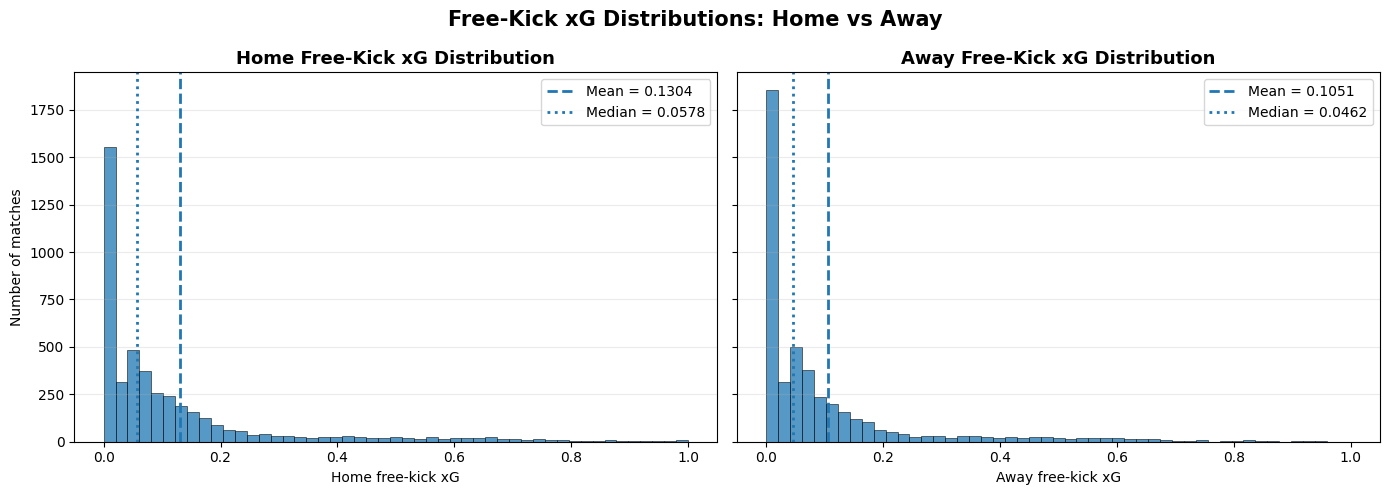

In [56]:
plot_data = free_kicks[["frk_xG_home", "frk_xG_away"]].copy()

plot_data["frk_xG_home"] = pd.to_numeric(plot_data["frk_xG_home"], errors="coerce")
plot_data["frk_xG_away"] = pd.to_numeric(plot_data["frk_xG_away"], errors="coerce")
plot_data = plot_data.replace([np.inf, -np.inf], np.nan).dropna()
home_xg = plot_data["frk_xG_home"]
away_xg = plot_data["frk_xG_away"]

summary = pd.DataFrame({
    "side": ["Home", "Away"],
    "mean": [home_xg.mean(), away_xg.mean()],
    "median": [home_xg.median(), away_xg.median()],
    "std": [home_xg.std(), away_xg.std()],
    "zero_%": [100 * (home_xg == 0).mean(),100 * (away_xg == 0).mean()],
    "positive_mean": [home_xg[home_xg > 0].mean(),away_xg[away_xg > 0].mean()]})

display(summary.round(4))

bins = np.linspace(0, 1, 50)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(home_xg,bins=bins,alpha=0.75,edgecolor="black",linewidth=0.5)
axes[0].axvline(home_xg.mean(),linestyle="--",linewidth=2,label=f"Mean = {home_xg.mean():.4f}")
axes[0].axvline(home_xg.median(),linestyle=":",linewidth=2,label=f"Median = {home_xg.median():.4f}")

axes[0].set_title("Home Free-Kick xG Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Home free-kick xG")
axes[0].set_ylabel("Number of matches")
axes[0].grid(True, axis="y", alpha=0.25)
axes[0].legend()

axes[1].hist(away_xg,bins=bins,alpha=0.75,edgecolor="black",linewidth=0.5)
axes[1].axvline(away_xg.mean(),linestyle="--",linewidth=2,label=f"Mean = {away_xg.mean():.4f}")
axes[1].axvline(away_xg.median(),linestyle=":",linewidth=2,label=f"Median = {away_xg.median():.4f}")

axes[1].set_title("Away Free-Kick xG Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Away free-kick xG")
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend()

plt.suptitle("Free-Kick xG Distributions: Home vs Away", fontsize=15, fontweight="bold")
plt.tight_layout()

Knowing that a standard Gamma model cannot represent exact zeros while the free kicks' ExG has many zero values, a hurdle–Gamma model is used consisting of:

1. A binary model for whether free-kick xG is positive.
2. A Gamma model for the amount of free-kick ExG, conditional on it being positive.

Let $ Y_i \geq 0 $ and denote the free-kick ExG generated by the team in team-match observation i. For both components of the free-kick ExG model, the relevant feature is the predicted number of fouls committed by the opposing team after being standardized. The second component (the continuous one) has an additional parameter for the home advantage. Also, time weights are applied to both components in the same way with weekly updattes adn predictions as before.


For modeling the large number of zeros observed a hurdle component is used by the following binary indictor and logistic regression being applied:

$$ Z_i = \mathbb{1}(Y_i>0) $$
$$ Z_i \sim \operatorname{Bernoulli}(p_i) $$
$$ \operatorname{logit}(p_i) = \beta_0 + \beta_H H_i + \beta_F X_i $$

Equivalently,

$$ p_i = P(Y_i>0\mid H_i,X_i) = \frac{ \exp(\beta_0+\beta_H H_i+\beta_F X_i) }{ 1+\exp(\beta_0+\beta_H H_i+\beta_F X_i)} $$

The non zero observations are following a gamma distribution:

$$ Y_i\mid Y_i>0 \sim \operatorname{Gamma}(\mu_i,\phi) $$

where $\mu_i$ is the conditional mean and $\phi$ is the Gamma dispersion parameter.

Therefore,
$$ \mu_i=E(Y_i\mid Y_i>0,H_i,X_i)=\exp(\gamma_0+\gamma_H H_i+\gamma_F X_i)$$

Thus, the observation-level likelihood contribution is:

$$ L_i = \begin{cases} 1-p_i, & y_i=0,\\[6pt] p_i  f_{\Gamma}(y_i\mid\mu_i,\phi), & y_i>0. \end{cases} $$

The corresponding log-likelihood contribution is

$$ \ell_i = \begin{cases}
\log(1-p_i), & y_i=0,\\[6pt]
\log(p_i) + \log f_{\Gamma}(y_i\mid\mu_i,\phi),
& y_i>0.
\end{cases} $$

The final prediction combines the hurdle probability and the positive Gamma expectation:

$$ E(Y_i\mid H_i,X_i) = P(Y_i>0\mid H_i,X_i) \cdot E(Y_i\mid Y_i>0,H_i,X_i) $$

Therefore,

$$ \widehat{E}(Y_i) = \widehat{p}_i \widehat{\mu}_i $$

or, explicitly,

$$ \widehat{E}(Y_i) =
\frac{ \exp( \widehat{\beta}_0 + \widehat{\beta}_H H_i + \widehat{\beta}_F X_i)}{ψ1+ψ\exp(\widehat{\beta}_0 +
\widehat{\beta}_H H_i + \widehat{\beta}_F X_i) } \,
\exp( \widehat{\gamma}_0 + \widehat{\gamma}_H H_i + \widehat{\gamma}_F X_i) $$

This is the model's predicted total free-kick xG for a team in a match.

In [57]:
def fit_fk_hurdle_gamma(kk,poisson_half_life,
    gamma_grid=np.array([30, 60, 90, 120, 180, 270,365, 500, 730, 1095, 1460, 2190]),
    val_frac=0.20,retrain_every_days=7,min_train_rows=100,min_positive_rows=30,zero_tol=0.0):

    m = kk.copy()
    m.columns = m.columns.astype(str).str.strip()

    required = ["date", "home", "away", "HF", "AF","frk_xG_home", "frk_xG_away"]

    m["date"] = pd.to_datetime(m["date"],errors="coerce",dayfirst=True)

    for c in ["HF", "AF", "frk_xG_home", "frk_xG_away"]:
        m[c] = pd.to_numeric(m[c], errors="coerce")

    m = (m.dropna(subset=required).loc[lambda x:
                (x["HF"] >= 0)
                & (x["AF"] >= 0)
                & (x["frk_xG_home"] >= 0)
                & (x["frk_xG_away"] >= 0)]
        .sort_values("date").reset_index(drop=True))

    m["_match_key"] = np.arange(len(m))

    home = pd.DataFrame({
        "_match_key": m["_match_key"],
        "date": m["date"],
        "team": m["home"].astype(str).str.strip(),
        "opponent": m["away"].astype(str).str.strip(),
        "IsHome": 1,
        "fouls": m["HF"].round().astype(int),
        "fk_xg": m["frk_xG_home"]})

    away = pd.DataFrame({
        "_match_key": m["_match_key"],
        "date": m["date"],
        "team": m["away"].astype(str).str.strip(),
        "opponent": m["home"].astype(str).str.strip(),
        "IsHome": 0,
        "fouls": m["AF"].round().astype(int),
        "fk_xg": m["frk_xG_away"]})

    foul_data = (
        pd.concat([home, away], ignore_index=True)
        .sort_values(["date", "_match_key", "IsHome"])
        .reset_index(drop=True)
    )

    foul_data["has_fk_xg"] = (foul_data["fk_xg"] > zero_tol).astype(int)

    def fit_glm(formula, data, family, weights):
        model = smf.glm(formula=formula,data=data,
            family=family,freq_weights=weights)

        start = np.zeros(model.exog.shape[1])
        y = np.asarray(model.endog, dtype=float)

        if isinstance(family, sm.families.Binomial):
            p = np.clip(np.average(y, weights=weights),1e-5,1 - 1e-5)
            start[0] = np.log(p / (1 - p))
        else:
            start[0] = np.log(max(np.average(y, weights=weights), 1e-10))

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = model.fit(start_params=start,maxiter=1000,disp=False)

            if not np.all(np.isfinite(result.params)):
                raise RuntimeError

        except Exception:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                result = model.fit_regularized(alpha=1e-6,L1_wt=0.0,maxiter=5000)

        return result

    foul_data["predicted_own_fouls"] = np.nan
    first_date = foul_data["date"].min()
    foul_data["_poisson_week"] = ((foul_data["date"] - first_date).dt.days // retrain_every_days).astype(int)

    for week in np.sort(foul_data["_poisson_week"].unique()):
        test = foul_data[foul_data["_poisson_week"] == week].copy()

        if test.empty:
            continue

        test_start = test["date"].min()
        train = foul_data[foul_data["date"] < test_start].copy()

        if len(train) < min_train_rows:
            continue

        levels = sorted(set(train["team"]) | set(train["opponent"]))
        known = set(levels)

        test = test[test["team"].isin(known) & test["opponent"].isin(known)].copy()

        if test.empty:
            continue

        for frame in [train, test]:
            frame["team"] = pd.Categorical(frame["team"],categories=levels)

            frame["opponent"] = pd.Categorical(frame["opponent"],categories=levels)

        ages = (test_start - train["date"]).dt.days.to_numpy(dtype=float)

        weights = 0.5 ** (ages / float(poisson_half_life))
        weights /= weights.mean()

        poisson_model = fit_glm(
            formula=("fouls ~ IsHome + C(team) + C(opponent)"),
            data=train,family=sm.families.Poisson(),weights=weights)

        foul_data.loc[test.index,"predicted_own_fouls"] = np.clip(np.asarray(
                poisson_model.predict(test),
                dtype=float),1e-8,None)


    prediction_lookup = pd.Series(
        foul_data["predicted_own_fouls"].to_numpy(),
        index=pd.MultiIndex.from_arrays([
            foul_data["_match_key"],
            foul_data["IsHome"]]))

    opposite_index = pd.MultiIndex.from_arrays([foul_data["_match_key"],1 - foul_data["IsHome"]])
    foul_data["predicted_opponent_fouls"] = (prediction_lookup.reindex(opposite_index).to_numpy())
    stacked_data = (foul_data.dropna(subset=["predicted_opponent_fouls"]).sort_values("date").reset_index(drop=True))

    if stacked_data["has_fk_xg"].nunique() < 2:
        raise ValueError(
            "FK xG must contain both zero and positive values.")

    unique_dates = np.sort(stacked_data["date"].dt.normalize().unique())

    cutoff = int(len(unique_dates) * (1 - val_frac))
    cutoff = min(max(cutoff, 1), len(unique_dates) - 1)

    validation_start = pd.Timestamp(unique_dates[cutoff])
    validation = stacked_data[stacked_data["date"] >= validation_start].copy()
    validation["_gamma_week"] = ((validation["date"] - validation_start).dt.days // retrain_every_days).astype(int)

    fold_rows = []

    hurdle_formula = ("has_fk_xg ~ IsHome + predicted_opponent_fouls_z")
    gamma_formula = ("fk_xg ~ IsHome + predicted_opponent_fouls_z")

    for week in np.sort(validation["_gamma_week"].unique()):
        test = validation[validation["_gamma_week"] == week].copy()

        if test.empty:
            continue

        test_start = test["date"].min()
        train = stacked_data[stacked_data["date"] < test_start].copy()

        if len(train) < min_train_rows:
            continue

        if train["has_fk_xg"].nunique() < 2:
            continue

        positive_train = train[train["has_fk_xg"] == 1].copy()

        if len(positive_train) < min_positive_rows:
            continue

        feature_mean = train["predicted_opponent_fouls"].mean()
        feature_std = train["predicted_opponent_fouls"].std(ddof=0)

        if not np.isfinite(feature_std) or feature_std < 1e-8:
            feature_std = 1.0

        for frame in [train, test]:
            frame["predicted_opponent_fouls_z"] = (frame["predicted_opponent_fouls"] - feature_mean) / feature_std

        y_test = test["fk_xg"].to_numpy(dtype=float)
        positive_test = y_test > zero_tol
        ages = (test_start - train["date"]).dt.days.to_numpy(dtype=float)

        for half_life in gamma_grid:
            half_life = int(half_life)

            weights = 0.5 ** (ages / float(half_life))
            weights /= weights.mean()
            train["_weight"] = weights
            positive_train = train[train["has_fk_xg"] == 1].copy()
            positive_weights = positive_train["_weight"].to_numpy(dtype=float)

            try:
                hurdle_model = fit_glm(formula=hurdle_formula,data=train,
                    family=sm.families.Binomial(),weights=weights)

                gamma_model = fit_glm(formula=gamma_formula,data=positive_train,
                    family=sm.families.Gamma(link=sm.families.links.Log()),
                    weights=positive_weights)

                p_positive = np.clip(np.asarray(hurdle_model.predict(test),dtype=float),1e-10,1 - 1e-10)
                conditional_mu = np.clip(np.asarray(gamma_model.predict(test),dtype=float),1e-12,1e6)

                positive_train_mu = np.clip(np.asarray(gamma_model.predict(positive_train),dtype=float),1e-12,1e6)
                y_positive = positive_train["fk_xg"].to_numpy(dtype=float)
                n_parameters = len(gamma_model.params)

                phi = np.sum(positive_weights * ((y_positive - positive_train_mu) / positive_train_mu) ** 2
                    ) / max(positive_weights.sum() - n_parameters,1.0)

                phi = float(np.clip(phi, 1e-8, 1e4))
                row_ll = np.empty(len(test))
                row_ll[~positive_test] = np.log(1 - p_positive[~positive_test])

                row_ll[positive_test] = (np.log(p_positive[positive_test]) + gamma_dist.logpdf(np.clip(y_test[positive_test],
                    np.finfo(float).tiny,None),
                    a=1 / phi,scale=conditional_mu[positive_test] * phi))

                expected_xg = p_positive * conditional_mu
                residuals = y_test - expected_xg

                if np.all(np.isfinite(row_ll)):
                    fold_rows.append({"week": int(week),
                        "half_life_days": half_life,
                        "joint_OOS_LogLik": float(row_ll.sum()),
                        "n_test": len(test),
                        "n_positive_test": int(positive_test.sum()),
                        "absolute_error_sum": float(np.abs(residuals).sum()),
                        "squared_error_sum": float(np.square(residuals).sum()),
                        "brier_sum": float(np.square(positive_test.astype(float) - p_positive).sum())})

            except Exception:
                continue

    fold_results = pd.DataFrame(fold_rows)
    if fold_results.empty:
        raise RuntimeError("No hurdle-Gamma model was fitted successfully.")

    results = (fold_results.groupby("half_life_days", as_index=False).agg(
            joint_OOS_LogLik=("joint_OOS_LogLik", "sum"),
            n_rows=("n_test", "sum"),
            n_positive_rows=("n_positive_test", "sum"),
            n_folds=("week", "nunique"),
            absolute_error_sum=("absolute_error_sum", "sum"),
            squared_error_sum=("squared_error_sum", "sum"),
            brier_sum=("brier_sum", "sum")))

    results["joint_avg_LL_per_row"] = (results["joint_OOS_LogLik"] / results["n_rows"])
    results["MAE"] = (results["absolute_error_sum"] / results["n_rows"])
    results["RMSE"] = np.sqrt(results["squared_error_sum"] / results["n_rows"])
    results["Brier"] = (results["brier_sum"] / results["n_rows"])

    max_folds = results["n_folds"].max()
    max_rows = results.loc[results["n_folds"] == max_folds,"n_rows"].max()

    eligible = results[(results["n_folds"] == max_folds) & (results["n_rows"] == max_rows)]

    best_half_life = int(eligible.sort_values("joint_OOS_LogLik",ascending=False).iloc[0]["half_life_days"])
    results = results.sort_values("joint_OOS_LogLik",ascending=False).reset_index(drop=True)

    final_poisson_data = foul_data.copy()
    team_levels = sorted(set(final_poisson_data["team"]) | set(final_poisson_data["opponent"]))

    final_poisson_data["team"] = pd.Categorical(final_poisson_data["team"],categories=team_levels)
    final_poisson_data["opponent"] = pd.Categorical(final_poisson_data["opponent"],categories=team_levels)

    poisson_ages = (final_poisson_data["date"].max() - final_poisson_data["date"]).dt.days.to_numpy(dtype=float)
    poisson_weights = 0.5 ** (poisson_ages / float(poisson_half_life))
    poisson_weights /= poisson_weights.mean()

    final_poisson_model = fit_glm(formula=("fouls ~ IsHome + C(team) + C(opponent)"),
        data=final_poisson_data,family=sm.families.Poisson(),weights=poisson_weights)

    final_data = stacked_data.copy()
    feature_mean = final_data["predicted_opponent_fouls"].mean()
    feature_std = final_data["predicted_opponent_fouls"].std(ddof=0)

    if not np.isfinite(feature_std) or feature_std < 1e-8:
        feature_std = 1.0

    final_data["predicted_opponent_fouls_z"] = (final_data["predicted_opponent_fouls"] - feature_mean) / feature_std
    gamma_ages = (final_data["date"].max() - final_data["date"]).dt.days.to_numpy(dtype=float)

    final_weights = 0.5 ** (gamma_ages / float(best_half_life))
    final_weights /= final_weights.mean()
    final_data["_weight"] = final_weights

    final_hurdle_model = fit_glm(formula=hurdle_formula,data=final_data,
        family=sm.families.Binomial(),weights=final_weights)

    final_positive = final_data[final_data["has_fk_xg"] == 1].copy()
    final_gamma_model = fit_glm(formula=gamma_formula,data=final_positive,
                        family=sm.families.Gamma(link=sm.families.links.Log()),weights=final_positive["_weight"].to_numpy())

    return {"best_gamma_half_life": best_half_life,
        "half_life_results": results,
        "fold_results": fold_results,
        "final_poisson_model": final_poisson_model,
        "final_hurdle_model": final_hurdle_model,
        "final_gamma_model": final_gamma_model,
        "feature_mean": feature_mean,
        "feature_std": feature_std,
        "team_levels": team_levels,
        "training_data": final_data}

In [58]:
fk_hurdle_results = fit_fk_hurdle_gamma(kk=foul_data,poisson_half_life=best_foul_half_life)

best_fk_gamma_half_life = (fk_hurdle_results["best_gamma_half_life"])
fk_gamma_half_life_results = (fk_hurdle_results["half_life_results"])
final_fk_poisson_model = (fk_hurdle_results["final_poisson_model"])
final_fk_hurdle_model = (fk_hurdle_results["final_hurdle_model"])
final_fk_gamma_model = (fk_hurdle_results["final_gamma_model"])

print("Optimal hurdle-Gamma half-life:",best_fk_gamma_half_life)

fk_gamma_half_life_results

Optimal hurdle-Gamma half-life: 120


,half_life_days,joint_OOS_LogLik,n_rows,n_positive_rows,n_folds,absolute_error_sum,squared_error_sum,brier_sum,joint_avg_LL_per_row,MAE,RMSE,Brier
0,120,-413.272153,1748,1075,94,211.373308,60.772572,409.270293,-0.236426,0.120923,0.186459,0.234136
1,90,-413.961078,1748,1075,94,210.570501,60.880952,409.823582,-0.236820,0.120464,0.186625,0.234453
2,180,-413.975824,1748,1075,94,212.813473,60.670884,408.754427,-0.236828,0.121747,0.186303,0.233841
3,270,-416.434421,1748,1075,94,214.308644,60.612406,408.583127,-0.238235,0.122602,0.186213,0.233743
4,60,-417.006929,1748,1075,94,209.929459,61.106978,410.871677,-0.238562,0.120097,0.186971,0.235052
5,365,-419.042143,1748,1075,94,215.262728,60.589530,408.721690,-0.239727,0.123148,0.186178,0.233822
6,500,-421.912211,1748,1075,94,216.031877,60.579303,409.133888,-0.241369,0.123588,0.186162,0.234058
7,730,-424.874166,1748,1075,94,216.651651,60.579336,409.937766,-0.243063,0.123943,0.186162,0.234518
8,1095,-427.101460,1748,1075,94,217.050798,60.587279,410.967117,-0.244337,0.124171,0.186174,0.235107
9,1460,-428.159712,1748,1075,94,217.232911,60.594675,411.666688,-0.244943,0.124275,0.186186,0.235507


## All ExG components to one model:

All it's left now is the final model estimating each ExG component and then adding them up for estimating a future match ExG for the home and away sides. The ExGs are considered independent at least for this part.

The code below creates a dataframe with all the necessary data for the final model based on the data from the UK data site, the shots and matches from the Understats site:

In [117]:
TEAM_NAME_MAP = {
    "Man United": "Manchester United",
    "Man Utd": "Manchester United",
    "Nott'm Forest": "Nottingham Forest",
    "West Brom": "West Bromwich Albion",
    "Wolves": "Wolverhampton Wanderers",
    "Man City": "Manchester City",
    "Newcastle": "Newcastle United",
    "QPR": "Queens Park Rangers"}

PEN_XG = 0.7612

def build_all_data(df_shots, df_UK, df):
    df_UK = df_UK.copy()

    rename_map = {"HomeTeam": "home", "AwayTeam": "away", "Date": "date"}
    rename_map = {k: v for k, v in rename_map.items() if k in df_UK.columns}
    df_UK.rename(columns=rename_map, inplace=True)

    required = {"home", "away", "date"}
    missing = required - set(df_UK.columns)
    if missing:
        raise KeyError(f"df_UK is missing expected columns {missing}. Found columns: {list(df_UK.columns)}")

    df_UK[["home", "away"]] = df_UK[["home", "away"]].replace(TEAM_NAME_MAP)

    d1 = pd.to_datetime(df_UK["date"], format="%d/%m/%Y", errors="coerce")
    d2 = pd.to_datetime(df_UK["date"], format="%d/%m/%y", errors="coerce")
    df_UK["date"] = d1.fillna(d2)
    df_UK = df_UK.dropna(subset=["home", "away", "date"])
    df_UK2 = df_UK.copy()
    df2 = df.copy()
    df_UK2["date"] = pd.to_datetime(df_UK2["date"], dayfirst=True, errors="coerce")
    df2["date"] = pd.to_datetime(df2["date"], dayfirst=True, errors="coerce")
    df_UK2[["home", "away"]] = df_UK2[["home", "away"]].replace(TEAM_NAME_MAP)
    df2[["home", "away"]] = df2[["home", "away"]].replace(TEAM_NAME_MAP)

    df_corners = pd.merge(df2, df_UK2, on=["home", "away", "date"], how="left", suffixes=("", "_corners"))
    if "home_goals" not in df_corners.columns and "FTHG" in df_corners.columns:
        df_corners["home_goals"] = df_corners["FTHG"]
    if "away_goals" not in df_corners.columns and "FTAG" in df_corners.columns:
        df_corners["away_goals"] = df_corners["FTAG"]

    df_shots_data = df_shots.copy()
    df_shots_data["xG"] = pd.to_numeric(df_shots_data["xG"], errors="coerce")
    df_shots_data["side"] = df_shots_data["side"].astype(str).str.strip().str.lower()
    df_shots_data["situation"] = df_shots_data["situation"].astype(str).str.strip()
    df_shots_data = df_shots_data.dropna(
        subset=["match_id", "date", "home", "away", "side", "situation", "xG"]).copy()

    xg_by_situation_long = (df_shots_data.groupby(["match_id", "date", "home", "away", "side", "situation"], as_index=False)["xG"]
        .sum().rename(columns={"xG": "xG_sum"}))

    xg_by_situation_match = xg_by_situation_long.pivot_table(index=["match_id", "date", "home", "away"],
        columns=["side", "situation"],values="xG_sum",fill_value=0).reset_index()

    new_cols = []
    for col in xg_by_situation_match.columns:
        if isinstance(col, tuple):
            col_clean = [str(c) for c in col if str(c) != ""]
            if len(col_clean) == 1:
                new_cols.append(col_clean[0])
            elif len(col_clean) == 2:
                side, situation = col_clean
                new_cols.append(f"{side}_{situation}_xG")
            else:
                new_cols.append("_".join(col_clean))
        else:
            new_cols.append(col)
    xg_by_situation_match.columns = new_cols

    home_xg_cols = [c for c in xg_by_situation_match.columns if c.startswith("home_") and c.endswith("_xG")]
    away_xg_cols = [c for c in xg_by_situation_match.columns if c.startswith("away_") and c.endswith("_xG")]
    xg_by_situation_match["home_total_xG"] = xg_by_situation_match[home_xg_cols].sum(axis=1)
    xg_by_situation_match["away_total_xG"] = xg_by_situation_match[away_xg_cols].sum(axis=1)

    dup_cols = xg_by_situation_match.columns[xg_by_situation_match.columns.duplicated()].tolist()
    if dup_cols:
        print("Duplicate columns:", dup_cols)

    xg_by_situation_match["date"] = pd.to_datetime(xg_by_situation_match["date"], format="mixed", dayfirst=False)
    df_pens = df_shots[df_shots["situation"] == "Penalty"]
    pen_counts = df_pens.groupby(["match_id", "side"]).size().reset_index(name="pens")
    pen_wide = (pen_counts.pivot(index="match_id", columns="side", values="pens")
        .reset_index().rename(columns={"home": "home_pens", "away": "away_pens"}))
    for c in ["home_pens", "away_pens"]:
        if c not in pen_wide.columns:
            pen_wide[c] = 0
    pen_wide[["home_pens", "away_pens"]] = pen_wide[["home_pens", "away_pens"]].fillna(0)

    m = xg_by_situation_match[["match_id", "date", "home", "away", "away_OpenPlay_xG", "home_OpenPlay_xG"]].copy()
    m["date"] = pd.to_datetime(m["date"])
    m = m.dropna(subset=["match_id", "date", "home", "away"]).reset_index(drop=True)
    m = m.merge(pen_wide, on="match_id", how="left")
    m[["home_pens", "away_pens"]] = m[["home_pens", "away_pens"]].fillna(0)

    m["home_xg"] = m["home_OpenPlay_xG"] - m["away_OpenPlay_xG"]
    m["away_xg"] = m["away_OpenPlay_xG"] - m["home_OpenPlay_xG"]
    m["home_xg_tot"] = m["home_OpenPlay_xG"] + m["away_OpenPlay_xG"]
    m["away_xg_tot"] = m["away_OpenPlay_xG"] + m["home_OpenPlay_xG"]

    home_view = m.rename(columns={"home": "team", "away": "opponent", "home_OpenPlay_xG": "DxG",
        "home_pens": "penalties", "home_xg_tot": "tot_xg",
    })[["match_id", "date", "team", "opponent", "DxG", "penalties", "tot_xg"]].copy()
    home_view["IsHome"] = True

    away_view = m.rename(columns={"away": "team", "home": "opponent", "away_OpenPlay_xG": "DxG",
        "away_pens": "penalties", "away_xg_tot": "tot_xg",
    })[["match_id", "date", "team", "opponent", "DxG", "penalties", "tot_xg"]].copy()
    away_view["IsHome"] = False

    corners_cols = ["match_id", "HC", "AC", "HF", "AF", "B365H", "B365D", "B365A", "home_goals", "away_goals"]
    missing_corners_cols = [c for c in corners_cols if c not in df_corners.columns]
    if missing_corners_cols:
        raise KeyError(f"df_corners is missing expected columns {missing_corners_cols}. Found columns: {list(df_corners.columns)}")

    all_data = xg_by_situation_match.merge(df_corners[corners_cols], on="match_id", how="left")
    all_data["frk_xG_home"] = all_data["home_SetPiece_xG"] + all_data["home_DirectFreekick_xG"]
    all_data["frk_xG_away"] = all_data["away_SetPiece_xG"] + all_data["away_DirectFreekick_xG"]

    print("df_corners duplicated match_id count:", sum(df_corners["match_id"].duplicated()))

    all_data = all_data.drop(columns=["away_DirectFreekick_xG", "away_SetPiece_xG", "home_DirectFreekick_xG", "home_SetPiece_xG",
        "away_FromCorner_xG", "away_Penalty_xG", "home_FromCorner_xG", "home_Penalty_xG"])

    print("all_data duplicated match_id count:", sum(all_data["match_id"].duplicated()))
    all_data = all_data.merge(m[["match_id", "home_pens", "away_pens"]], on="match_id", how="left")
    print("m duplicated match_id count:", sum(m["match_id"].duplicated()))

    return all_data

In [118]:
all_data = build_all_data(df_shots, df_UK, df)

df_corners duplicated match_id count: 0
all_data duplicated match_id count: 0
m duplicated match_id count: 0


Below is the final model which estimates all the components of ExG given the data in the form described above and selecting the training percentage. Firstly the open play ExgG is estimated with its values being used for the penalties' probability model and teams' fouls estimation, with the fouls' values being used in the hurdle gamma model of free kicks' ExG. The corners' ExG is estimated by a model based only on teams' coefficients for calculating the number of corners of each team and then being multiplied by the ExG per corner. Similarly the penalties ExG contribution is just the prnalty probability multiplied by the ExG per penalty. The values of ExG per penalty and ExG per corner are considered constant and same for all teams.

In [119]:
def _weights(ages, half_life):
    ages = np.asarray(ages, dtype=float)
    w = 0.5 ** (ages / float(half_life))
    m = w.mean()
    return w / m if m > 0 else w


def _fit_glm_safe(formula, data, family, weights, fallback_formula=None):
    try:
        model = smf.glm(formula=formula, data=data, family=family, freq_weights=weights)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = model.fit(maxiter=1000, disp=False)
        if not np.all(np.isfinite(result.params)):
            raise RuntimeError("Non-finite parameters")
        return result
    except Exception:
        try:
            use_formula = fallback_formula if fallback_formula is not None else formula
            model = smf.glm(formula=use_formula, data=data, family=family, freq_weights=weights)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = model.fit_regularized(alpha=1e-6, L1_wt=0.0, maxiter=5000)
            return result
        except Exception:
            return None


def _safe_predict(model, train, test, target_col, weights, transform=None):
    base = float(np.average(train[target_col].to_numpy(dtype=float), weights=weights))

    if model is None:
        preds = np.full(len(test), base)
    else:
        try:
            preds = np.asarray(model.predict(test), dtype=float)
        except Exception:
            preds = np.full(len(test), base)
        if np.any(~np.isfinite(preds)):
            preds = np.where(np.isfinite(preds), preds, base)

    if transform is not None:
        preds = transform(preds)
    return preds


def _prep_categoricals(train, test, team_levels):
    for frame in (train, test):
        frame["team"] = pd.Categorical(frame["team"], categories=team_levels)
        frame["opponent"] = pd.Categorical(frame["opponent"], categories=team_levels)


def _predict_freekick(train, test, half_life, min_positive_rows, eps=0.0):
    tr = train.dropna(subset=["frk_xg"]).copy()
    te = test.copy()
    tr["has_frk"] = (tr["frk_xg"] > eps).astype(int)

    w = _weights(tr["_age"].to_numpy(dtype=float), half_life)

    if tr["has_frk"].nunique() < 2 or int(tr["has_frk"].sum()) < min_positive_rows:
        base = float(np.average(tr["frk_xg"], weights=w))
        return np.full(len(te), base), np.full(len(tr), base), None

    hurdle_model = _fit_glm_safe("has_frk ~ IsHome + C(team) + C(opponent)", tr,
        sm.families.Binomial(), w, fallback_formula="has_frk ~ IsHome")

    positive = tr.loc[tr["has_frk"] == 1].copy()
    positive_w = w[tr["has_frk"].to_numpy() == 1]

    gamma_model = _fit_glm_safe("frk_xg ~ IsHome + C(team) + C(opponent)", positive,
        sm.families.Gamma(link=sm.families.links.Log()), positive_w,fallback_formula="frk_xg ~ IsHome")

    clip01 = lambda x: np.clip(x, 0.0, 1.0)
    clip_pos = lambda x: np.clip(x, 0.0, None)

    p_test = _safe_predict(hurdle_model, tr, te, "has_frk", w, transform=clip01)
    mu_test = _safe_predict(gamma_model, positive, te, "frk_xg", positive_w, transform=clip_pos)
    exg_test = p_test * mu_test

    p_train = _safe_predict(hurdle_model, tr, tr, "has_frk", w, transform=clip01)
    mu_train = _safe_predict(gamma_model, positive, tr, "frk_xg", positive_w, transform=clip_pos)
    exg_train = p_train * mu_train

    return exg_test, exg_train, (hurdle_model, gamma_model)


def _predict_corners(train, test, half_life, alpha):
    tr = train.dropna(subset=["corners"]).copy()
    te = test.copy()
    w = _weights(tr["_age"].to_numpy(dtype=float), half_life)

    model = _fit_glm_safe("corners ~ IsHome + C(team) + C(opponent)", tr,
        sm.families.NegativeBinomial(alpha=alpha), w, fallback_formula="corners ~ IsHome")

    mu_test = _safe_predict(model, tr, te, "corners", w, transform=lambda x: np.clip(x, 1e-8, None))
    return mu_test, model


def _predict_openplay(train, test, half_life, eps=0.01):
    tr = train.dropna(subset=["openplay_xg"]).copy()
    te = test.copy()
    tr["openplay_pos"] = tr["openplay_xg"].astype(float) + eps
    w = _weights(tr["_age"].to_numpy(dtype=float), half_life)

    model = _fit_glm_safe("openplay_pos ~ IsHome + C(team) + C(opponent)", tr,
        sm.families.Gamma(link=sm.families.links.Log()), w, fallback_formula="openplay_pos ~ IsHome")

    transform = lambda x: np.clip(np.clip(x, 1e-8, None) - eps, 0.0, None)
    mu_test = _safe_predict(model, tr, te, "openplay_pos", w, transform=transform)
    mu_train_valid = _safe_predict(model, tr, tr, "openplay_pos", w, transform=transform)
    mu_train = pd.Series(np.nan, index=train.index, dtype=float)
    mu_train.loc[tr.index] = mu_train_valid
    return mu_test, mu_train, model


def _add_openplay_match_features(data, predicted_openplay):
    out = data.copy()

    if isinstance(predicted_openplay, pd.Series):
        out["_pred_openplay"] = predicted_openplay.reindex(out.index).to_numpy(dtype=float)
    else:
        out["_pred_openplay"] = np.asarray(predicted_openplay, dtype=float)

    match_predictions = (out.pivot_table(index="match_id", columns="IsHome", values="_pred_openplay", aggfunc="first")
        .rename(columns={1: "predicted_home_openplay_xg", 0: "predicted_away_openplay_xg"}))

    for col in ["predicted_home_openplay_xg", "predicted_away_openplay_xg"]:
        if col not in match_predictions.columns:
            match_predictions[col] = np.nan

    out = out.join(match_predictions[["predicted_home_openplay_xg", "predicted_away_openplay_xg"]], on="match_id")

    home_xg = out["predicted_home_openplay_xg"]
    away_xg = out["predicted_away_openplay_xg"]
    out["tot_xg"] = home_xg + away_xg
    out["DxG"] = np.where(out["IsHome"].eq(1), home_xg - away_xg, away_xg - home_xg)

    return out


def _predict_penalties(train, test, half_life):
    required = ["pens", "IsHome", "DxG", "tot_xg"]
    tr = train.dropna(subset=required).copy()
    te = test.copy()

    if tr.empty:
        return np.full(len(te), np.nan), np.full(len(te), np.nan), None

    w = _weights(tr["_age"].to_numpy(dtype=float), half_life)
    model = _fit_glm_safe(
        "pens ~ IsHome + DxG + tot_xg", tr, sm.families.Poisson(), w, fallback_formula="pens ~ IsHome")

    valid_test = te[["IsHome", "DxG", "tot_xg"]].notna().all(axis=1).to_numpy()
    mu = np.full(len(te), np.nan, dtype=float)

    if model is not None and valid_test.any():
        mu[valid_test] = np.asarray(model.predict(te.loc[valid_test]), dtype=float)

    if (~valid_test).any() or model is None:
        base_mu = float(np.average(tr["pens"].to_numpy(dtype=float), weights=w))
        mu[np.isnan(mu)] = base_mu

    mu = np.clip(mu, 1e-10, None)
    pen_prob = 1.0 - np.exp(-mu)

    return mu, pen_prob, model

def build_long_from_wide(all_data, date_col="date"):
    df = all_data.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    def _side(team_col, opp_col, is_home, xg_col, frk_col, corner_col, pens_col):
        return pd.DataFrame({
            "match_id": df["match_id"],
            date_col: df[date_col],
            "team": df[team_col],
            "opponent": df[opp_col],
            "IsHome": is_home,
            "openplay_xg": df[xg_col],
            "frk_xg": df[frk_col],
            "corners": df[corner_col],
            "pens": df[pens_col]})

    home = _side("home", "away", 1, "home_OpenPlay_xG", "frk_xG_home", "HC", "home_pens")
    away = _side("away", "home", 0, "away_OpenPlay_xG", "frk_xG_away", "AC", "away_pens")

    return (pd.concat([home, away], ignore_index=True).sort_values(date_col).reset_index(drop=True))


def predict_exg_components_walkforward(
    all_data, val_frac=0.20, retrain_every_days=7, min_train_rows=100, min_positive_rows=30,
    openplay_half_life=270, frk_half_life=365, corners_half_life=365, penalty_half_life=10000,
    xg_per_corner=0.04, xg_per_penalty=0.77, corners_alpha=0.08, date_col="date", verbose=True):
    long_df = build_long_from_wide(all_data, date_col=date_col)
    dates = long_df[date_col]

    cutoff_idx = min(max(int(len(long_df) * (1 - val_frac)), 1), len(long_df) - 1)
    val_start_date = dates.iloc[cutoff_idx]
    val_mask = dates >= val_start_date
    val_indices = long_df.index[val_mask].to_numpy()
    val_dates = dates[val_mask]
    week_offsets = ((val_dates - val_start_date).dt.days // retrain_every_days).astype(int).to_numpy()

    if verbose:
        print("=" * 80)
        print("ExG-COMPONENT WALK-FORWARD PREDICTION")
        print("=" * 80)
        print(f"Rows: {len(long_df)}")
        print(f"Validation start: {val_start_date.date()}")

    prediction_rows = []
    n_blocks = 0
    n_skipped = 0

    for wk in np.unique(week_offsets):
        test_idx = val_indices[week_offsets == wk]
        if len(test_idx) == 0:
            continue

        test = long_df.loc[test_idx].copy()
        test_start = test[date_col].min()
        train = long_df.loc[long_df[date_col] < test_start].copy()

        if len(train) < min_train_rows:
            continue

        team_levels = sorted(set(train["team"]) | set(train["opponent"]))
        known = set(team_levels)
        before = len(test)
        test = test.loc[test["team"].isin(known) & test["opponent"].isin(known)].copy()
        n_skipped += before - len(test)
        if test.empty:
            continue

        _prep_categoricals(train, test, team_levels)
        train["_age"] = (test_start - train[date_col]).dt.days.to_numpy(dtype=float)
        n_blocks += 1

        try:
            exg_op, train_exg_op, _ = _predict_openplay(train, test, openplay_half_life)
            train_penalty = _add_openplay_match_features(train, train_exg_op)
            test_penalty = _add_openplay_match_features(test, exg_op)
        except Exception:
            exg_op = np.full(len(test), np.nan)
            train_penalty, test_penalty = train.copy(), test.copy()
            for frame in [train_penalty, test_penalty]:
                frame["DxG"] = np.nan
                frame["tot_xg"] = np.nan
                frame["predicted_home_openplay_xg"] = np.nan
                frame["predicted_away_openplay_xg"] = np.nan

        try:
            exg_frk, _, _ = _predict_freekick(train, test, frk_half_life, min_positive_rows)
        except Exception:
            exg_frk = np.full(len(test), np.nan)

        try:
            pred_corn, _ = _predict_corners(train, test, corners_half_life, corners_alpha)
        except Exception:
            pred_corn = np.full(len(test), np.nan)

        try:
            mu_pen, pen_prob, _ = _predict_penalties(train_penalty, test_penalty, penalty_half_life)
        except Exception:
            mu_pen = np.full(len(test), np.nan)
            pen_prob = np.full(len(test), np.nan)

        exg_corner = pred_corn * xg_per_corner
        exg_penalty = pen_prob * xg_per_penalty

        block = pd.DataFrame({
            "date": test[date_col].values,
            "match_id": test["match_id"].values,
            "team": test["team"].astype(str).values,
            "opponent": test["opponent"].astype(str).values,
            "IsHome": test["IsHome"].values,
            "week": int(wk),
            "exg_openplay": exg_op,
            "predicted_home_openplay_xg": test_penalty["predicted_home_openplay_xg"].values,
            "predicted_away_openplay_xg": test_penalty["predicted_away_openplay_xg"].values,
            "DxG": test_penalty["DxG"].values,
            "tot_xg": test_penalty["tot_xg"].values,
            "exg_freekick": exg_frk,
            "pred_corners": pred_corn,
            "exg_corner": exg_corner,
            "pen_prob": pen_prob,
            "pen_rate_mu": mu_pen,
            "exg_penalty": exg_penalty,
            "exg_total": exg_op + exg_frk + exg_corner + exg_penalty,
            "actual_openplay_xg": test["openplay_xg"].values,
            "actual_frk_xg": test["frk_xg"].values,
            "actual_corners": test["corners"].values,
            "actual_pens": test["pens"].values})
        prediction_rows.append(block)

        if verbose and n_blocks % 10 == 0:
            print(f"Processed {n_blocks} weekly blocks...")

    predictions = (pd.concat(prediction_rows, ignore_index=True)
        .sort_values(["date", "match_id", "IsHome"], ascending=[True, True, False]).reset_index(drop=True))

    full = long_df.copy()
    team_levels_full = sorted(set(full["team"]) | set(full["opponent"]))
    full["team"] = pd.Categorical(full["team"], categories=team_levels_full)
    full["opponent"] = pd.Categorical(full["opponent"], categories=team_levels_full)
    ref_date = full[date_col].max()
    final_models = {}

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        def _fit_final(target_col, formula, family, fallback, half_life, positive_only=None, required_cols=None):
            required_cols = required_cols or []
            sub = full.dropna(subset=[target_col, *required_cols]).copy()
            if positive_only is not None:
                sub = sub.loc[positive_only(sub)].copy()
            if sub.empty:
                return None
            ages_sub = (ref_date - sub[date_col]).dt.days.to_numpy(dtype=float)
            w_sub = _weights(ages_sub, half_life)
            return _fit_glm_safe(formula, sub, family, w_sub, fallback_formula=fallback)

        full["openplay_pos"] = full["openplay_xg"].astype(float) + 0.01
        final_models["openplay_gamma"] = _fit_final("openplay_pos", "openplay_pos ~ IsHome + C(team) + C(opponent)",
            sm.families.Gamma(link=sm.families.links.Log()), "openplay_pos ~ IsHome", openplay_half_life)

        if final_models["openplay_gamma"] is not None:
            mu = np.clip(np.asarray(final_models["openplay_gamma"].predict(full), dtype=float) - 0.01, 0.0, None)
            full = _add_openplay_match_features(full, mu)
        else:
            full["DxG"] = np.nan
            full["tot_xg"] = np.nan

        full["has_frk"] = (full["frk_xg"] > 0).astype(int)
        if full.dropna(subset=["frk_xg"])["has_frk"].nunique() == 2:
            final_models["frk_hurdle"] = _fit_final("has_frk", "has_frk ~ IsHome + C(team) + C(opponent)",
                sm.families.Binomial(), "has_frk ~ IsHome", frk_half_life)
            final_models["frk_gamma"] = _fit_final("frk_xg", "frk_xg ~ IsHome + C(team) + C(opponent)",
                sm.families.Gamma(link=sm.families.links.Log()), "frk_xg ~ IsHome", frk_half_life,
                positive_only=lambda s: s["has_frk"].eq(1))

        final_models["corners_nb"] = _fit_final("corners", "corners ~ IsHome + C(team) + C(opponent)",
            sm.families.NegativeBinomial(alpha=corners_alpha), "corners ~ IsHome", corners_half_life)

        penalty_formula = "pens ~ IsHome + DxG + tot_xg"
        final_models["penalty_poisson"] = _fit_final("pens", penalty_formula, sm.families.Poisson(), "pens ~ IsHome", penalty_half_life,
            required_cols=["IsHome", "DxG", "tot_xg"])

    parameters = {
        "val_frac": val_frac,
        "retrain_every_days": retrain_every_days,
        "openplay_half_life": openplay_half_life,
        "frk_half_life": frk_half_life,
        "corners_half_life": corners_half_life,
        "penalty_half_life": penalty_half_life,
        "xg_per_corner": xg_per_corner,
        "xg_per_penalty": xg_per_penalty,
        "corners_alpha": corners_alpha,
        "team_levels": team_levels_full,
        "validation_start": val_start_date,
        "reference_date": ref_date,
        "penalty_formula": "pens ~ IsHome + DxG + tot_xg",
        "DxG_definition": "team predicted open-play xG minus opponent predicted open-play xG"}

    if verbose:
        print(f"\nWeekly blocks scored: {n_blocks}")
        print(f"Rows skipped: {n_skipped}")
        print(f"Prediction rows: {len(predictions)}")

    return {
        "predictions": predictions,
        "parameters": parameters,
        "final_models": final_models,
        "long_data": long_df,
        "full_model_data": full}

In [120]:
exg_results = predict_exg_components_walkforward(all_data=all_data,val_frac=0.30,retrain_every_days=7,min_train_rows=100,
        openplay_half_life=270,frk_half_life=120,corners_half_life=365,penalty_half_life=1000,
        xg_per_corner=0.04,xg_per_penalty=0.76,corners_alpha=0.078,date_col="date",verbose=True)

exg_predictions = exg_results["predictions"]
exg_parameters = exg_results["parameters"]
exg_models = exg_results["final_models"]

ExG-COMPONENT WALK-FORWARD PREDICTION
Rows: 9120
Validation start: 2022-12-26
Processed 10 weekly blocks...
Processed 20 weekly blocks...
Processed 30 weekly blocks...
Processed 40 weekly blocks...
Processed 50 weekly blocks...
Processed 60 weekly blocks...
Processed 70 weekly blocks...
Processed 80 weekly blocks...
Processed 90 weekly blocks...
Processed 100 weekly blocks...
Processed 110 weekly blocks...
Processed 120 weekly blocks...
Processed 130 weekly blocks...

Weekly blocks scored: 130
Rows skipped: 4
Prediction rows: 2744


The predicted ExG components, corner number and penalty probabillity don't show any important bias:

In [121]:
def evaluate_rmse_exg_predictions(exg_predictions,corner_xg_per=0.04,penalty_xg_per=0.77):

    d = exg_predictions.copy()
    d.columns = d.columns.astype(str).str.strip()

    required_columns = [
        "date",
        "match_id",
        "IsHome",
        "exg_openplay",
        "exg_freekick",
        "pred_corners",
        "exg_corner",
        "pen_rate_mu",
        "exg_penalty",
        "exg_total",
        "actual_openplay_xg",
        "actual_frk_xg",
        "actual_corners",
        "actual_pens"
    ]

    missing_columns = [
        col for col in required_columns
        if col not in d.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    d["date"] = pd.to_datetime(d["date"],errors="coerce")

    numeric_columns = [
        "match_id",
        "IsHome",
        "exg_openplay",
        "exg_freekick",
        "pred_corners",
        "exg_corner",
        "pen_prob",
        "pen_rate_mu",
        "exg_penalty",
        "exg_total",
        "actual_openplay_xg",
        "actual_frk_xg",
        "actual_corners",
        "actual_pens"]

    for col in numeric_columns:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col],errors="coerce")

    d = (d.sort_values(["date", "match_id", "IsHome"],ascending=[True, True, False]).reset_index(drop=True))

    d["actual_corner_xg"] = (d["actual_corners"] * corner_xg_per)
    d["actual_penalty_xg"] = (d["actual_pens"] * penalty_xg_per)

    d["actual_total_xg"] = (
        d["actual_openplay_xg"]
        + d["actual_frk_xg"]
        + d["actual_corner_xg"]
        + d["actual_penalty_xg"])

    def metrics(predicted, observed):

        predicted = pd.to_numeric(predicted,errors="coerce")
        observed = pd.to_numeric(observed,errors="coerce")
        valid = (predicted.notna()
            & observed.notna()
            & np.isfinite(predicted)
            & np.isfinite(observed))

        p = predicted.loc[valid].to_numpy(dtype=float)
        o = observed.loc[valid].to_numpy(dtype=float)

        if len(p) == 0:
            return {"n": 0,"RMSE": np.nan,"MAE": np.nan, "Bias": np.nan}

        error = p - o

        return {
            "n": len(p),
            "RMSE": float(np.sqrt(np.mean(error ** 2))),
            "MAE": float(np.mean(np.abs(error))),
            "Bias": float(np.mean(error))}

    component_pairs = [
        ("OpenPlay","exg_openplay","actual_openplay_xg"),
        ("freekick","exg_freekick","actual_frk_xg"),
        ("corner","exg_corner","actual_corner_xg"),
        ("penalty","exg_penalty","actual_penalty_xg"),
        ("TOTAL","exg_total","actual_total_xg"),
        ("corners_count","pred_corners","actual_corners"),
        ("penalties_count","pen_rate_mu","actual_pens")]

    rows = []
    side_definitions = [("home", 1),("away", 0)]

    for side_name, side_value in side_definitions:
        side_data = d.loc[d["IsHome"].eq(side_value)]

        for component, pred_col, obs_col in component_pairs:

            result = metrics(
                side_data[pred_col],
                side_data[obs_col])

            rows.append({
                "Component": f"{side_name}_{component}",
                "Side": side_name,
                "Prediction": pred_col,
                "Observed": obs_col,
                **result})

    rmse_summary = (pd.DataFrame(rows).round(4).reset_index(drop=True))

    return d, rmse_summary

In [122]:
evaluated_predictions, rmse_summary = (
    evaluate_rmse_exg_predictions(exg_predictions=exg_predictions,corner_xg_per=0.04,penalty_xg_per=0.77))

display(rmse_summary)

,Component,Side,Prediction,Observed,n,RMSE,MAE,Bias
0,home_OpenPlay,home,exg_openplay,actual_openplay_xg,1372,0.7713,0.5842,-0.0342
1,home_freekick,home,exg_freekick,actual_frk_xg,1372,0.2259,0.1423,-0.0036
2,home_corner,home,exg_corner,actual_corner_xg,1372,0.1140,0.0916,0.0018
3,home_penalty,home,exg_penalty,actual_penalty_xg,1372,0.2893,0.1881,-0.0071
4,home_TOTAL,home,exg_total,actual_total_xg,1372,0.8592,0.6595,-0.0431
5,home_corners_count,home,pred_corners,actual_corners,1372,2.8502,2.2891,0.0447
6,home_penalties_count,home,pen_rate_mu,actual_pens,1372,0.3753,0.2533,0.0043
7,away_OpenPlay,away,exg_openplay,actual_openplay_xg,1372,0.7064,0.5356,-0.0332
8,away_freekick,away,exg_freekick,actual_frk_xg,1372,0.1835,0.1181,0.0023
9,away_corner,away,exg_corner,actual_corner_xg,1372,0.1080,0.0843,-0.0006


The ExG components were assumed to be independent so far meaning that the total ExG of a team is just the sum of all of its ExG components. The simplest way for identifying any interaction term of ExG is by trying all the ExG interaction terms in a linear regression model and keeping the one with the lowest BIC and the less complexity. 

The difference between the simple independent components' model and the higher order one is very small but it seems that a correction is needed with the penalty ExG estimation due to being a product of the openplay ExG estimation. For now this type of correction will be ignored.

In [123]:
def best_subset_exg_residuals(exg_predictions,all_data,criterion="bic",top=5):
    e = exg_predictions.copy()
    a = all_data.copy()

    e.columns = e.columns.astype(str).str.strip()
    a.columns = a.columns.astype(str).str.strip()

    e["match_id"] = pd.to_numeric(e["match_id"], errors="coerce")
    a["match_id"] = pd.to_numeric(a["match_id"], errors="coerce")

    actual = (a[["match_id", "home_total_xG", "away_total_xG"]].drop_duplicates("match_id"))

    e = e.merge(actual, on="match_id", how="left")
    components = ["exg_openplay","exg_freekick","exg_corner","exg_penalty"]

    for col in ["IsHome", "home_total_xG", "away_total_xG", *components]:
        e[col] = pd.to_numeric(e[col], errors="coerce")

    e["actual_total_xg"] = np.where(e["IsHome"].eq(1),e["home_total_xG"],e["away_total_xG"])
    df = (e.dropna(subset=["match_id","IsHome","actual_total_xg",*components]).copy())

    if df.empty:
        raise ValueError("No valid observations available.")

    df["base_prediction"] = df[components].sum(axis=1)
    df["residual"] = (df["actual_total_xg"] - df["base_prediction"])

    interactions = []

    for x1, x2 in itertools.combinations(components, 2):
        name = f"{x1}_X_{x2}"
        df[name] = df[x1] * df[x2]
        interactions.append(name)

    criterion = criterion.upper()

    criterion_map = {
        "AIC": "AIC",
        "BIC": "BIC",
        "R2": "R2",
        "ADJR2": "adjR2"}

    if criterion not in criterion_map:
        raise ValueError("criterion must be 'aic', 'bic', 'r2', or 'adjr2'.")

    rows = []
    models = {}

    y_residual = df["residual"]
    y_actual = df["actual_total_xg"]
    base = df["base_prediction"]

    n = len(df)
    ss_total = ((y_actual - y_actual.mean()) ** 2).sum()

    for k in range(len(interactions) + 1):

        for combo in itertools.combinations(interactions, k):
            label = " + ".join(combo) if combo else "(none)"
            if combo:
                X = df[list(combo)].astype(float)

                model = sm.OLS(y_residual,X,hasconst=False).fit()
                correction = model.predict(X)
                parameters = model.params

            else:
                model = None
                correction = np.zeros(n)
                parameters = pd.Series(dtype=float)

            final_prediction = base + correction

            rss = ((y_actual - final_prediction) ** 2).sum()
            final_r2 = (
                1 - rss / ss_total
                if ss_total > 0
                else np.nan)

            p = len(combo)

            final_adj_r2 = (
                1 - (1 - final_r2) * (n - 1) / (n - p)
                if n > p
                else np.nan)

            safe_rss = max(float(rss), np.finfo(float).tiny)

            log_likelihood = -0.5 * n * (np.log(2 * np.pi) + 1 + np.log(safe_rss / n))
            aic = -2 * log_likelihood + 2 * p
            bic = -2 * log_likelihood + np.log(n) * p

            rows.append({
                "interactions": label,
                "n_interactions": p,
                "R2": final_r2,
                "adjR2": final_adj_r2,
                "AIC": aic,
                "BIC": bic})

            models[label] = {
                "model": model,
                "terms": list(combo),
                "parameters": parameters}

    ranking = pd.DataFrame(rows)

    sort_col = criterion_map[criterion]
    ascending = criterion in {"AIC", "BIC"}

    ranking = (ranking.sort_values(sort_col, ascending=ascending).reset_index(drop=True))
    best_row = ranking.iloc[0]
    best_label = best_row["interactions"]
    best_terms = models[best_label]["terms"]
    best_model = models[best_label]["model"]

    if best_terms:
        X_best = df[best_terms].astype(float)

        df["residual_correction"] = (best_model.predict(X_best))
    else:
        df["residual_correction"] = 0.0

    df["best_prediction"] = (df["base_prediction"] + df["residual_correction"])
    base_r2 = 1 - ((df["actual_total_xg"] - df["base_prediction"]) ** 2).sum() / ss_total
    final_r2 = 1 - ((df["actual_total_xg"] - df["best_prediction"]) ** 2).sum() / ss_total

    if best_model is not None:

        confidence_interval = best_model.conf_int()

        estimated_parameters = pd.DataFrame({
            "coefficient": best_model.params,
            "std_error": best_model.bse,
            "t_value": best_model.tvalues,
            "p_value": best_model.pvalues,
            "ci_lower": confidence_interval[0],
            "ci_upper": confidence_interval[1]})

    else:
        estimated_parameters = pd.DataFrame(
            columns=[
                "coefficient",
                "std_error",
                "t_value",
                "p_value",
                "ci_lower",
                "ci_upper"])

    fixed_parameters = pd.DataFrame(
        {"coefficient": 1.0,
            "std_error": np.nan,
            "t_value": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan},index=components)

    all_parameters = pd.concat([fixed_parameters, estimated_parameters])

    print("=" * 90)
    print("POOLED HOME AND AWAY MODEL — NO INTERCEPT")
    print("=" * 90)
    print(f"Observations: {len(df)}")
    print(f"Unique matches: {df['match_id'].nunique()}")
    print(f"Models tested: {len(ranking)}")
    print(f"Base component-sum R2: {base_r2:.6f}")
    print(f"Optimal corrected R2: {final_r2:.6f}")

    print("\nFixed base prediction:\n"
        "exg_openplay + exg_freekick + "
        "exg_corner + exg_penalty")

    print("\nResidual model:\n"
        "residual = selected interactions only"
        "\nNo intercept is estimated.")

    print(f"\nTop {top} models by {sort_col}:")
    print(ranking.head(top).round(6).to_string(index=False))

    print("\nOptimal residual model")
    print("-" * 90)
    print(f"Selected interactions: {best_label}")
    print(f"AIC: {best_row['AIC']:.6f}")
    print(f"BIC: {best_row['BIC']:.6f}")
    print(f"R2: {best_row['R2']:.6f}")
    print(f"Adjusted R2: {best_row['adjR2']:.6f}")

    print("\nModel parameters")
    print(
        "The four component coefficients are fixed at 1. "
        "There is no intercept.")
    print("-" * 90)
    print(all_parameters.round(6).to_string())

    return {
        "data": df,
        "ranking": ranking,
        "best_model": best_model,
        "best_interactions": best_terms,
        "estimated_parameters": estimated_parameters,
        "all_parameters": all_parameters,
        "base_r2": base_r2,
        "final_r2": final_r2}

results = best_subset_exg_residuals(exg_predictions=exg_predictions,all_data=all_data,criterion="bic",top=5)

POOLED HOME AND AWAY MODEL — NO INTERCEPT
Observations: 2744
Unique matches: 1372
Models tested: 64
Base component-sum R2: 0.191870
Optimal corrected R2: 0.209198

Fixed base prediction:
exg_openplay + exg_freekick + exg_corner + exg_penalty

Residual model:
residual = selected interactions only
No intercept is estimated.

Top 5 models by BIC:
                                                                                                   interactions  n_interactions       R2    adjR2         AIC         BIC
                              exg_openplay_X_exg_corner + exg_openplay_X_exg_penalty + exg_corner_X_exg_penalty               3 0.209198 0.208621 6965.372568 6983.124084
                                                          exg_openplay_X_exg_penalty + exg_corner_X_exg_penalty               2 0.206498 0.206209 6972.724979 6984.559323
 exg_openplay_X_exg_penalty + exg_freekick_X_exg_corner + exg_freekick_X_exg_penalty + exg_corner_X_exg_penalty               4 0.210099 0.20923

Given the ExGs the match result probabillities can be estimated by the simple poisson distribution for each team with independence:

In [124]:
def build_match_predictions(exg_predictions, max_goals=10, exg_col="exg_total"):
    e = exg_predictions.copy()

    home = e[e["IsHome"] == 1][["match_id", "date", "team", "opponent", exg_col]]
    home = home.rename(columns={"team": "home", "opponent": "away", exg_col: "lambda_home"})
    away = e[e["IsHome"] == 0][["match_id", exg_col]].rename(columns={exg_col: "lambda_away"})

    m = home.merge(away, on="match_id").dropna(subset=["lambda_home", "lambda_away"])
    g = np.arange(max_goals + 1)
    rows = []

    for _, x in m.iterrows():
        lam_h = max(float(x["lambda_home"]), 1e-6)
        lam_a = max(float(x["lambda_away"]), 1e-6)
        M = np.outer(poisson.pmf(g, lam_h), poisson.pmf(g, lam_a))
        M /= M.sum()
        i, j = np.unravel_index(M.argmax(), M.shape)

        rows.append({
            "date": x["date"], "home": x["home"], "away": x["away"],
            "pred_home_goals": lam_h, "pred_away_goals": lam_a,
            "ml_home_goals": int(i), "ml_away_goals": int(j),
            "P_home": np.tril(M, -1).sum(),
            "P_draw": np.trace(M),
            "P_away": np.triu(M, 1).sum()})

    return pd.DataFrame(rows)


score_results = {"match_predictions": build_match_predictions(exg_predictions, max_goals=10)}
score_results["match_predictions"].head()

,date,home,away,pred_home_goals,pred_away_goals,ml_home_goals,ml_away_goals,P_home,P_draw,P_away
0,2022-12-26,Arsenal,West Ham,1.820715,0.954501,1,0,0.577327,0.227884,0.194789
1,2022-12-26,Aston Villa,Liverpool,1.191472,1.996347,1,1,0.224019,0.215721,0.560260
2,2022-12-26,Brentford,Tottenham,1.476183,1.562892,1,1,0.360560,0.240974,0.398465
3,2022-12-26,Crystal Palace,Fulham,1.637476,1.006953,1,1,0.521049,0.246302,0.232650
4,2022-12-26,Everton,Wolverhampton Wanderers,1.309085,1.214026,1,1,0.388444,0.268223,0.343334


Below the difference between the predicted and observed match scores matrix is shown in which there is no visible bias so no further actions for calibration to the correct score matrix is needed.

In [125]:
def predict_scores_from_exg(exg_predictions, results_df, max_goals=10):
    e = exg_predictions.copy()
    e["match_id"] = pd.to_numeric(e["match_id"], errors="coerce")

    home = e[e["IsHome"] == 1][["match_id", "date", "team", "opponent", "exg_total"]]
    home = home.rename(columns={"team": "home", "opponent": "away", "exg_total": "lam_h"})
    away = e[e["IsHome"] == 0][["match_id", "exg_total"]].rename(columns={"exg_total": "lam_a"})
    m = home.merge(away, on="match_id").dropna(subset=["lam_h", "lam_a"])

    r = results_df.copy()
    r["match_id"] = pd.to_numeric(r["match_id"], errors="coerce")
    m = m.merge(r[["match_id", "home_goals", "away_goals"]], on="match_id", how="left")

    g = np.arange(max_goals + 1)
    pred_mat = np.zeros((max_goals + 1, max_goals + 1))
    obs_mat = np.zeros((max_goals + 1, max_goals + 1))
    rows = []

    for _, x in m.iterrows():
        lam_h = max(x["lam_h"], 1e-6)
        lam_a = max(x["lam_a"], 1e-6)
        M = np.outer(poisson.pmf(g, lam_h), poisson.pmf(g, lam_a))
        M /= M.sum()
        pred_mat += M

        i, j = np.unravel_index(M.argmax(), M.shape)
        rec = {"date": x["date"], "home": x["home"], "away": x["away"],
               "pred_home": lam_h, "pred_away": lam_a,
               "ml_home": int(i), "ml_away": int(j),
               "P_home": np.tril(M, -1).sum(), "P_draw": np.trace(M), "P_away": np.triu(M, 1).sum()}

        if pd.notna(x["home_goals"]):
            ah, aa = int(x["home_goals"]), int(x["away_goals"])
            rec["act_home"], rec["act_away"] = ah, aa
            if ah <= max_goals and aa <= max_goals:
                obs_mat[ah, aa] += 1
        rows.append(rec)

    pred_mat /= max(pred_mat.sum(), 1)
    obs_mat /= max(obs_mat.sum(), 1)

    idx = pd.Index(g, name="home"); col = pd.Index(g, name="away")
    predicted = pd.DataFrame(pred_mat, idx, col)
    observed = pd.DataFrame(obs_mat, idx, col)
    difference = predicted - observed

    return {
        "predictions": pd.DataFrame(rows),
        "predicted_matrix": predicted,
        "observed_matrix": observed,
        "difference_matrix": difference}

out = predict_scores_from_exg(exg_results["predictions"], df, max_goals=10)

print("Difference matrix (predicted - observed, %):")
display((out["difference_matrix"].iloc[:6, :6] * 100).round(2))
score_predictions = out["predictions"]

Difference matrix (predicted - observed, %):


away,0,1,2,3,4,5
home,,,,,,
0,0.09,-0.18,-0.78,-0.06,0.03,-0.13
1,0.17,-1.25,0.44,0.17,-0.07,-0.03
2,0.01,-0.52,-1.70,0.69,0.19,0.18
3,-0.63,-0.45,0.23,0.59,0.14,0.16
4,0.86,-0.01,0.23,-0.27,-0.08,-0.01
5,0.03,0.37,0.33,0.08,0.07,0.02


## Backtesting:

The match result odds given are sportsbooks' odds which are marginated by arounf 2.5% across all events. For a proper comparison between the model of this project and the market the prices has to be transformed to the fair prices. For prices of the range [1.40,3.00] the margin usually applied is uniform in the of form:

$$Price_{marginated} = \frac{(1+ margin)}{Proballity}$$

For prices outside the mentioned range above, being too short or too large practically in [1.00,1.4] and [3.00,$\inf$], a power law margin is applied in the form:

$$Price_{marginated} = \frac{1}{Proballity^{k}}$$

where the factor k is calculated by solving the equation:

$$ \sum_i Proballity_{i}^{k} = margin $$

In [126]:
def remove_margin(df_odds, home_col="B365H", draw_col="B365D", away_col="B365A",low=1.40, high=3.00):
    d = df_odds.copy()
    o = d[[home_col, draw_col, away_col]].to_numpy(dtype=float)

    fair = np.full_like(o, np.nan)
    method = np.array(["none"] * len(d), dtype=object)
    x_used = np.full(len(d), np.nan)

    for i in range(len(d)):
        oi = o[i]
        if not np.all(np.isfinite(oi)) or np.any(oi <= 1):
            continue

        imp = 1.0 / oi
        oh, oa = oi[0], oi[2]

        if (low < oh < high) or (low < oa < high):
            margin = imp.sum() - 1.0
            f = imp - margin / 3.0
            method[i] = "uniform"
        else:
            g = lambda k: np.sum(imp ** k) - 1.0
            try:
                k = brentq(g, 1.0, 50.0)
            except Exception:
                k = 1.0
            f = imp ** k
            f = f / f.sum()
            method[i] = "power"
            x_used[i] = 1.0 / k

        fair[i] = f / f.sum()

    d["fair_home"] = 1/fair[:, 0]
    d["fair_draw"] = 1/fair[:, 1]
    d["fair_away"] = 1/fair[:, 2]
    d["devig_method"] = method
    d["devig_x"] = x_used
    return d

In [127]:
devig = remove_margin(all_data, home_col="B365H", draw_col="B365D", away_col="B365A",low=1.40, high=3.00)
print(devig[["B365H", "B365D", "B365A", "fair_home", "fair_draw", "fair_away",
             "devig_method", "devig_x"]].head(10).round(4).to_string(index=False))
print("\nmethod counts:")
print(devig["devig_method"].value_counts())

 B365H  B365D  B365A  fair_home  fair_draw  fair_away devig_method  devig_x
  1.65    4.0   6.00     1.6709     4.1250     6.2857      uniform      NaN
  2.00    3.6   4.00     2.0377     3.7241     4.1538      uniform      NaN
  1.70    3.9   5.50     1.7259     4.0390     5.7804      uniform      NaN
  1.95    3.5   4.33     1.9881     3.6247     4.5224      uniform      NaN
  2.55    3.3   3.00     2.6134     3.4069     3.0881      uniform      NaN
  1.36    5.0  11.00     1.3747     5.2904    11.9654        power   0.9661
  2.88    3.3   2.70     2.9382     3.3766     2.7511      uniform      NaN
  1.29    6.0  12.00     1.3022     6.4098    13.1513        power   0.9644
  3.40    3.4   2.30     3.4911     3.4911     2.3413      uniform      NaN
  5.75    4.0   1.67     6.0117     4.1249     1.6914      uniform      NaN

method counts:
devig_method
uniform    3595
power       857
none        108
Name: count, dtype: int64


In [128]:
all_data.loc[:,'B365H'] = devig["fair_home"].round(2)
all_data.loc[:,'B365D'] = devig["fair_draw"].round(2)
all_data.loc[:,'B365A'] = devig["fair_away"].round(2)

all_data[['B365H','B365D','B365A']]

,B365H,B365D,B365A
0,1.67,4.12,6.29
1,2.04,3.72,4.15
2,1.73,4.04,5.78
3,1.99,3.62,4.52
4,2.61,3.41,3.09
...,...,...,...
4555,1.32,6.87,10.63
4556,3.52,4.04,2.13
4557,3.86,3.86,2.08
4558,1.98,4.02,4.08


Surprisingly enough the model is very close to the fair market probabillities in all metrics (RPS, Logloss and Brier) even with a lot of information still missing from the model but obviously is still not winning against such a highly liquid market such as Premier league:

In [129]:
def compare_predictions_vs_market(predictions, df_odds):
    p = predictions.copy()
    p["date"] = pd.to_datetime(p["date"])
    o = df_odds.copy()
    o["date"] = pd.to_datetime(o["date"])
    cols = ["date", "home", "away", "home_goals", "away_goals", "B365H", "B365D", "B365A"]
    m = p.merge(o[cols], on=["date", "home", "away"], how="inner").dropna(
        subset=["B365H", "B365D", "B365A", "home_goals", "away_goals"])

    res = np.where(m.home_goals > m.away_goals, 0, np.where(m.home_goals == m.away_goals, 1, 2))
    obs = np.eye(3)[res]

    model_p = m[["P_home", "P_draw", "P_away"]].to_numpy()
    model_p = model_p / model_p.sum(axis=1, keepdims=True)

    imp = 1.0 / m[["B365H", "B365D", "B365A"]].to_numpy()
    market_p = imp / imp.sum(axis=1, keepdims=True)

    def rps(pred, obs):
        cp = np.cumsum(pred, axis=1)[:, :-1]
        co = np.cumsum(obs, axis=1)[:, :-1]
        return ((cp - co) ** 2).sum(axis=1) / (pred.shape[1] - 1)

    def logloss(pred, obs):
        return -np.log(np.clip((pred * obs).sum(axis=1), 1e-15, None))

    def brier(pred, obs):
        return ((pred - obs) ** 2).sum(axis=1)

    out = pd.DataFrame({
        "metric": ["RPS", "LogLoss", "Brier"],
        "model":  [rps(model_p, obs).mean(), logloss(model_p, obs).mean(), brier(model_p, obs).mean()],
        "market": [rps(market_p, obs).mean(), logloss(market_p, obs).mean(), brier(market_p, obs).mean()]})
    out["edge"] = out["market"] - out["model"]

    print(f"Matches compared: {len(m)}")
    print(out.round(5).to_string(index=False))

    return {"metrics": out, "n": len(m),
            "model_probs": model_p, "market_probs": market_p, "outcomes": res}

compare_results = compare_predictions_vs_market(predictions=score_results["match_predictions"],df_odds=all_data)

Matches compared: 1372
 metric   model  market     edge
    RPS 0.20045 0.19619 -0.00427
LogLoss 0.98038 0.96593 -0.01445
  Brier 0.58340 0.57454 -0.00885


Now the accuracy of the model for different predicted probabillity values can be checked in case calibration is needed due to bias. The model's predictions are compared with the market probabillity values in all probabillity ranges for having a clear picture of the model's performance. For this test the expected calibration error (ECE) is calculated following the formula:

$$ ECE = \sum_{bin} \frac{n_{bin}}{N} \cdot |gap_{bin}|$$

where $n_{bin}$ is the number of observations in a proballity range bin, $gap_{bin}$ is the total gap of probabillity between observations and model's predictions in the same bin and N is the number of all observations.

Model  ECE: 0.0113 
Market ECE: 0.0164

--- Model calibration ---
    bin    n  mean_pred  obs_freq     gap
0.0-0.1   38     0.0478    0.0263  0.0214
0.1-0.1  177     0.1079    0.1130 -0.0051
0.1-0.2  523     0.1733    0.1797 -0.0064
0.2-0.3 1319     0.2329    0.2350 -0.0021
0.3-0.3  435     0.2950    0.3034 -0.0085
0.3-0.4  389     0.3664    0.3470  0.0194
0.4-0.5  322     0.4332    0.4130  0.0201
0.5-0.5  317     0.4989    0.4984  0.0004
0.5-0.6  210     0.5637    0.5857 -0.0220
0.6-0.7  190     0.6315    0.6474 -0.0159
0.7-0.7  101     0.6982    0.6436  0.0546
0.7-0.8   59     0.7653    0.8475 -0.0822
0.8-0.9   25     0.8321    0.7200  0.1121
0.9-0.9   10     0.8940    0.9000 -0.0060
0.9-1.0    1     0.9916    1.0000 -0.0084


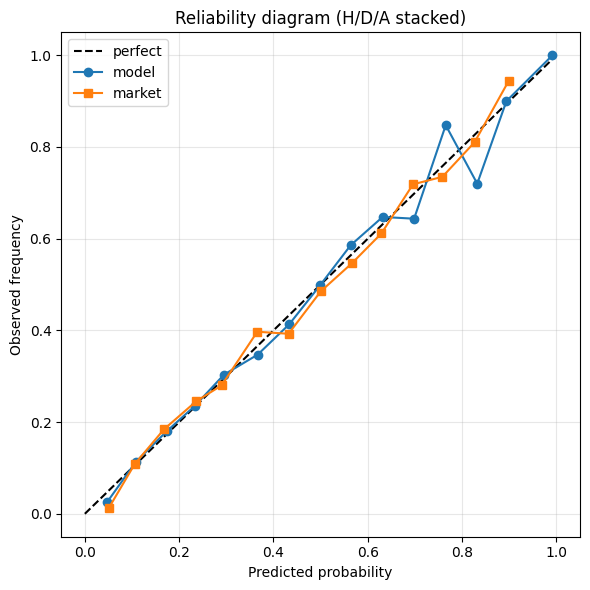

In [130]:
def check_calibration(compare_results, n_bins=20):
    model_p = compare_results["model_probs"] if "model_probs" in compare_results else None
    if model_p is None:
        m = compare_results["merged"]
        model_p = m[["P_home", "P_draw", "P_away"]].to_numpy()
        model_p = model_p / model_p.sum(1, keepdims=True)
        odds = m[["B365H", "B365D", "B365A"]].to_numpy()
        market_p = (1 / odds) / (1 / odds).sum(1, keepdims=True)
        res = np.where(m.home_goals > m.away_goals, 0,
                       np.where(m.home_goals == m.away_goals, 1, 2))
    else:
        market_p = compare_results["market_probs"]
        res = compare_results["outcomes"]

    obs = np.eye(3)[res]
    p_model = model_p.ravel()
    p_market = market_p.ravel()
    y = obs.ravel()

    bins = np.linspace(0, 1, n_bins + 1)

    def table(p):
        idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
        rows = []
        for b in range(n_bins):
            mask = idx == b
            if mask.sum() == 0:
                continue
            rows.append({"bin": f"{bins[b]:.1f}-{bins[b+1]:.1f}",
                         "n": int(mask.sum()),
                         "mean_pred": p[mask].mean(),
                         "obs_freq": y[mask].mean()})
        t = pd.DataFrame(rows)
        t["gap"] = t["mean_pred"] - t["obs_freq"]      # + => overconfident
        return t

    model_tbl = table(p_model)
    market_tbl = table(p_market)

    ece = lambda t: np.average(np.abs(t["gap"]), weights=t["n"])
    print(f"Model  ECE: {ece(model_tbl):.4f} ")
    print(f"Market ECE: {ece(market_tbl):.4f}\n")
    print("--- Model calibration ---")
    print(model_tbl.round(4).to_string(index=False))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--", label="perfect")
    plt.plot(model_tbl["mean_pred"], model_tbl["obs_freq"], "o-", label="model")
    plt.plot(market_tbl["mean_pred"], market_tbl["obs_freq"], "s-", label="market")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
    plt.title("Reliability diagram (H/D/A stacked)")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    return {"model_table": model_tbl, "market_table": market_tbl,
            "model_ece": ece(model_tbl), "market_ece": ece(market_tbl)}

calib = check_calibration(compare_results, n_bins=15)

The model's predictions are close to the market probabillity values with variation existing mainly in the higher range of values. An additional noise beside different information in the plot below is the exact margins used by B365 on higher and lower probabillity values since there are different approaches across different bookies.

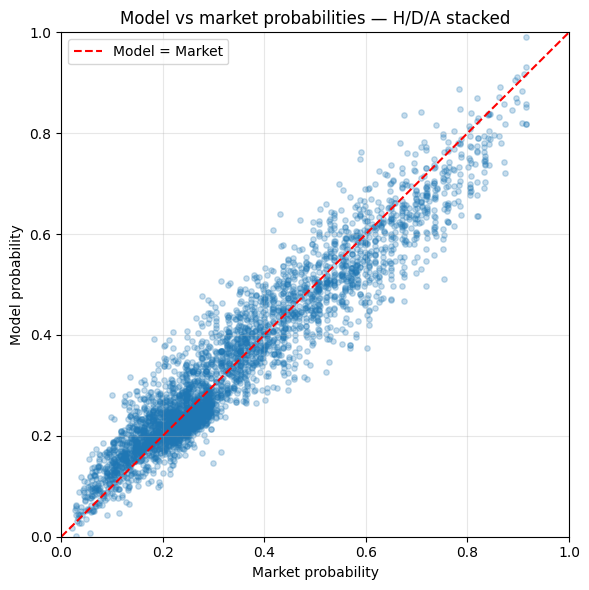

In [131]:
valid = np.isfinite(compare_results['model_probs']) & np.isfinite(compare_results['market_probs'])

x = compare_results['market_probs'][valid]
y_model = compare_results['model_probs'][valid]

plt.figure(figsize=(6, 6))
plt.scatter(x,y_model,alpha=0.25,s=15)
plt.plot([0, 1],[0, 1],linestyle="--",label="Model = Market",c = 'red')

plt.xlabel("Market probability")
plt.ylabel("Model probability")
plt.title("Model vs market probabilities — H/D/A stacked")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

Obviously there is stil a gap against the market that is the result of information missing form the model. This information has to do mainly with players' information but there is also the information regarding red cards at different time ranges, yellow cards, weather, motivation, etc. But this type of statistical approach offers a base for building a more accurate model with additional effects and offsets while the ExG components can provide exotic match markets as well.